# Import Packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive') #mounting to personal google drive to retrieve datasets

Mounted at /content/drive


In [ ]:
!pip install pmdarima

!pip install sktime

!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import datetime as dt
import matplotlib.dates as mdates

import gc

from statsmodels.tsa.seasonal import STL

from scipy.stats import boxcox
from scipy.special import inv_boxcox

from statsmodels.tsa.stattools import adfuller

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from pmdarima.arima import auto_arima


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


###XGBOOST

from xgboost import XGBRegressor

from sktime.forecasting.compose import TransformedTargetForecaster, make_reduction
from sktime.forecasting.model_selection import ExpandingWindowSplitter, ForecastingGridSearchCV
from sktime.forecasting.conformal import ConformalIntervals

from sktime.transformations.series.boxcox import BoxCoxTransformer, LogTransformer
from sktime.transformations.series.detrend import Deseasonalizer, Detrender

from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError



from sktime.forecasting.trend import PolynomialTrendForecaster




from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error



from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner.tuners import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters

# Read Data

In [ ]:
isbn_file = '/content/drive/MyDrive/TimeSeriesProject/ISBN List.xlsx' #define location of isbn file
timeseries_file = '/content/drive/MyDrive/TimeSeriesProject/UK Weekly Trended Timeline from 200101_202429.xlsx' #define location of time series file


#create lists where each element is one of the sheets
books_sheets = [pd.read_excel(isbn_file, sheet_name=i) for i in range(4)]
time_sheets = [pd.read_excel(timeseries_file, sheet_name=i) for i in range(4)]


#stitch the elements together into a single df, one for all books, and one for the time series data
books_df = pd.concat(books_sheets, ignore_index=True)
timeseries_df = pd.concat(time_sheets, ignore_index=True)

# Exploratory Data Analysis

## Dataframe Display

In [ ]:
print("books_df:")
display(books_df.head(5))
print("\ntimeseries_df:")
display(timeseries_df.head(5))

books_df:


,ISBN,Title,Author,Imprint,Publisher Group,RRP,Binding,Publication Date,Product Class,Country of Publication
0,9780330375252,Bridget Jones's Diary (Film Tie-in),"Fielding, Helen",Picador,Pan Macmillan Grp,8.99,Paperback,2001-03-23,F1.1 General & Literary Fiction,United Kingdom
1,9780140276336,White Teeth,"Smith, Zadie",Penguin Books Ltd,Penguin Grp,9.99,Paperback,2001-01-25,F1.1 General & Literary Fiction,United Kingdom
2,9780006512134,Man and Boy,"Parsons, Tony",HarperCollins Publishers,HarperCollins Grp,8.99,Paperback,2000-03-06,F1.1 General & Literary Fiction,United Kingdom
3,9780099280255,"Brethren,The","Grisham, John",Arrow Books,Random House Grp,6.99,Paperback,2000-12-27,"F2.1 Crime, Thriller & Adventure",United Kingdom
4,9780552998727,Marrying The Mistress:an irresistible and grip...,"Trollope, Joanna",Black Swan,Transworld Grp,10.99,Paperback,2001-02-01,F1.1 General & Literary Fiction,United Kingdom



timeseries_df:


,ISBN,Title,Author,Interval,End Date,Volume,Value,ASP,RRP,Binding,Imprint,Publisher Group,Product Class
0,9780002261821,One For My Baby,"Parsons, Tony",200513,2005-04-02,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction
1,9780002261821,One For My Baby,"Parsons, Tony",200503,2005-01-22,1,15.99,15.99,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction
2,9780002261821,One For My Baby,"Parsons, Tony",200422,2004-05-29,1,11.19,11.19,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction
3,9780002261821,One For My Baby,"Parsons, Tony",200415,2004-04-10,2,27.18,13.59,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction
4,9780002261821,One For My Baby,"Parsons, Tony",200404,2004-01-24,2,22.48,11.24,15.99,Hardback,HarperCollins Publishers,HarperCollins Grp,F1.1 General & Literary Fiction


## Datatype Analysis and Modification

In [ ]:
def column_datatypes(df_name):
  for x in df_name.columns: #loop to identify data type makeup across the features of the dataset
    type_counts = df_name[x].map(type).value_counts() #count number of datatype types per feature
    print(f"{type_counts}\nTotal: {type_counts.sum()}\n") #print information for interpretation

In [ ]:
print("-----------------------------------\nDatatype makeup for book list data\n-----------------------------------\n")
column_datatypes(books_df)

-----------------------------------
Datatype makeup for book list data
-----------------------------------

ISBN
<class 'int'>    500
Name: count, dtype: int64
Total: 500

Title
<class 'str'>    500
Name: count, dtype: int64
Total: 500

Author
<class 'str'>      426
<class 'float'>     74
Name: count, dtype: int64
Total: 500

Imprint
<class 'str'>    500
Name: count, dtype: int64
Total: 500

Publisher Group
<class 'str'>    500
Name: count, dtype: int64
Total: 500

RRP
<class 'float'>    500
Name: count, dtype: int64
Total: 500

Binding
<class 'str'>    500
Name: count, dtype: int64
Total: 500

Publication Date
<class 'pandas._libs.tslibs.timestamps.Timestamp'>    500
Name: count, dtype: int64
Total: 500

Product Class
<class 'str'>    500
Name: count, dtype: int64
Total: 500

Country of Publication
<class 'str'>    500
Name: count, dtype: int64
Total: 500



All features show 500 records, i.e. 500 unique books, all single data type, except for `Author` column which shows 426 `str` and 74 `float`. These float values likely correspond to NaN values which will be checked.

In [ ]:
print(books_df['Author'].isna().sum())

74


This confirms that the float values in the `Author` column of `books_df` are NaN values. This project does not depend on this field so NaN values will be left since the remainder of the respective records will contain useful information.

In [ ]:
print("-----------------------------------\nDatatype makeup for time series data\n-----------------------------------\n")
column_datatypes(timeseries_df)

-----------------------------------
Datatype makeup for time series data
-----------------------------------

ISBN
<class 'int'>    227224
Name: count, dtype: int64
Total: 227224

Title
<class 'str'>    227224
Name: count, dtype: int64
Total: 227224

Author
<class 'str'>      212345
<class 'float'>     14879
Name: count, dtype: int64
Total: 227224

Interval
<class 'int'>    227224
Name: count, dtype: int64
Total: 227224

End Date
<class 'pandas._libs.tslibs.timestamps.Timestamp'>    227224
Name: count, dtype: int64
Total: 227224

Volume
<class 'int'>    227224
Name: count, dtype: int64
Total: 227224

Value
<class 'float'>    227224
Name: count, dtype: int64
Total: 227224

ASP
<class 'float'>    227224
Name: count, dtype: int64
Total: 227224

RRP
<class 'float'>    227224
Name: count, dtype: int64
Total: 227224

Binding
<class 'str'>    227224
Name: count, dtype: int64
Total: 227224

Imprint
<class 'str'>    227224
Name: count, dtype: int64
Total: 227224

Publisher Group
<class 'str'>  

Similar to `books_df`, `timeseries_df` contains a constant number of single datatypes per feature, 227224, except for the `Author` column which contains float values too, again, likely NaN values which will be checked.

In [ ]:
print(timeseries_df['Author'].isna().sum())

14879


This confirms that all float values in the `Author` column of `timeseries_df` are NaN values corresponding to the missing authors identified in `books_df`. Similar reasoning means that these will remain in the dataframe.

The `ISBN` columns in both dataframes are `int` which should be converted to `str`, and the `End Date` column of `timeseries_df` should be changed to `datetime` and set as the dataframe index.

In [ ]:
books_df["ISBN"] = books_df["ISBN"].astype(str) #change ISBN from int to str

timeseries_df["ISBN"] = timeseries_df["ISBN"].astype(str) #change ISBN from int to str
timeseries_df["End Date"] = pd.to_datetime(timeseries_df["End Date"], format = "%Y-%m-%d") #change End Date to datetime

timeseries_df.set_index("End Date", inplace=True) #set End Date as the timeseries_df index

timeseries_df = timeseries_df.sort_values(by=['ISBN', 'End Date']) #sort timeseries_df by descending ISBN then ascending End Date

display(timeseries_df.head(5)) #view updated timeseries df
print(timeseries_df.shape)

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher Group,Product Class
End Date,,,,,,,,,,,,
2001-01-06,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200101,522,2544.07,4.8737,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning
2001-01-13,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200102,379,1842.21,4.8607,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning
2001-01-20,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200103,393,1921.19,4.8885,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning
2001-01-27,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200104,369,1785.31,4.8382,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning
2001-02-03,9780001713031,"Cat in the Hat, The","Seuss, Dr.",200105,423,2060.07,4.8701,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning


(227224, 12)


## Time Series Resampling

Above shows `timeseries_df` when sorted by `ISBN` and `End Date`. It should be noted that `End Date` increases 7 days, 1 week, at a time, with these dates corresponding to saturdays.

Moreover, `End Date` is correlated with `Interval`, which contains information in the YYYYWW format i.e. the year followed by the week number the end date falls into.

A popular Dr. Seuss book is displayed by the above ISBN, so every week has sales data, so it is clear the final 2 digits of `interval` increase week on week. However, some books will not sell every week, and therefore will not have any sales data/corresponding record. Therefore, these zero values need to be imputed whilst retaining information from other columns.

In [ ]:
timeseries_df_resampled = timeseries_df.groupby('ISBN').resample('W-SAT').asfreq() #resampling timeseries to weekly frequency, regardless of sales present. first groupby ISBN )moved to index) so subsequent functions applied to subset of timeseries_df. weekly resample ending on saturday, .asfreq() to set a record every week

timeseries_df_resampled = timeseries_df_resampled.drop(columns=['ISBN']) #removing ISBN column (as it is stored in index)

ff_column_names = ["Title", "Author", "RRP", "Binding", "Imprint", "Publisher Group", "Product Class"] #column names where imputed values should be fed forward (i.e. use previous available value)
timeseries_df_resampled[ff_column_names] = timeseries_df_resampled[ff_column_names].ffill() #imputing fill forward values

zero_column_names = ["Volume", "Value", "ASP"] #column names which should be zero on the missing weeks that have been added. volume is number of books sold in the week, i.e. zero, ASP, average sale price, is also zero since no sales made in the week, and value is the multiplication of these, hence zero
timeseries_df_resampled[zero_column_names] = timeseries_df_resampled[zero_column_names].fillna(0) #imputing NaN values with 0


display(timeseries_df_resampled.head()) #view resampled timeseries df
print(timeseries_df_resampled.shape)

Title      Author  Interval  Volume  \
ISBN          End Date                                                        
9780001713031 2001-01-06  Cat in the Hat, The  Seuss, Dr.  200101.0   522.0   
              2001-01-13  Cat in the Hat, The  Seuss, Dr.  200102.0   379.0   
              2001-01-20  Cat in the Hat, The  Seuss, Dr.  200103.0   393.0   
              2001-01-27  Cat in the Hat, The  Seuss, Dr.  200104.0   369.0   
              2001-02-03  Cat in the Hat, The  Seuss, Dr.  200105.0   423.0   

                            Value     ASP   RRP    Binding  Imprint  \
ISBN          End Date                                                
9780001713031 2001-01-06  2544.07  4.8737  4.99  Paperback  Collins   
              2001-01-13  1842.21  4.8607  4.99  Paperback  Collins   
              2001-01-20  1921.19  4.8885  4.99  Paperback  Collins   
              2001-01-27  1785.31  4.8382  4.99  Paperback  Collins   
              2001-02-03  2060.07  4.8701  4.99  Paperback  Collins   

                            Publisher Group                   Product Class  
ISBN          End Date                                                       
9780001713031 2001-01-06  HarperCollins Grp  Y4.2 Reference & Home Learning  
              2001-01-13  HarperCollins Grp  Y4.2 Reference & Home Learning  
              2001-01-20  HarperCollins Grp  Y4.2 Reference & Home Learning  
              2001-01-27  HarperCollins Grp  Y4.2 Reference & Home Learning  
              2001-02-03  HarperCollins Grp  Y4.2 Reference & Home Learning

(382871, 11)


Note: `ISBN` moved to index after `.groupby()` and number of records increased as missing weeks filled in.

In [ ]:
timeseries_df_resampled = timeseries_df_resampled.reset_index() #removing ISBN/End Date from index

display(timeseries_df_resampled.head(5)) #view resampled timeseries df

,ISBN,End Date,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher Group,Product Class
0,9780001713031,2001-01-06,"Cat in the Hat, The","Seuss, Dr.",200101.0,522.0,2544.07,4.8737,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning
1,9780001713031,2001-01-13,"Cat in the Hat, The","Seuss, Dr.",200102.0,379.0,1842.21,4.8607,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning
2,9780001713031,2001-01-20,"Cat in the Hat, The","Seuss, Dr.",200103.0,393.0,1921.19,4.8885,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning
3,9780001713031,2001-01-27,"Cat in the Hat, The","Seuss, Dr.",200104.0,369.0,1785.31,4.8382,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning
4,9780001713031,2001-02-03,"Cat in the Hat, The","Seuss, Dr.",200105.0,423.0,2060.07,4.8701,4.99,Paperback,Collins,HarperCollins Grp,Y4.2 Reference & Home Learning


## Recently Sold Books

In [ ]:
newest_date = max(timeseries_df_resampled["End Date"])
oldest_date = min(timeseries_df_resampled["End Date"])

print(f"Newest data: {oldest_date}")

print(f"Newest data: {newest_date}")

Newest data: 2001-01-06 00:00:00
Newest data: 2024-07-20 00:00:00


The most recent data available in this dataset is 20th July 2024. As such, it is useful to filter out books that have been recently sold within the last month or so. Therefore, ISBNs of books that have been sold since 1st July 2024 should be identified.

In [ ]:
recent_isbn_list = timeseries_df_resampled.loc[timeseries_df_resampled["End Date"] > '2024-07-01', 'ISBN'].unique().tolist() #making mask of df where dates are more recent and returning all respective unique ISBNs to a list

print(len(recent_isbn_list))
print(recent_isbn_list)

61
['9780006512134', '9780006514091', '9780006514213', '9780006531203', '9780006550433', '9780006647553', '9780007101887', '9780091816971', '9780091867775', '9780099244721', '9780099285823', '9780099286387', '9780099286578', '9780099422587', '9780099428558', '9780099771517', '9780140259506', '9780140275421', '9780140276336', '9780140276619', '9780140281293', '9780140285215', '9780140294231', '9780140295962', '9780224060875', '9780241003008', '9780261103252', '9780330355667', '9780340696767', '9780340766057', '9780340786055', '9780349112763', '9780349113609', '9780349114033', '9780440864141', '9780440864554', '9780552145053', '9780552145060', '9780552145954', '9780552997034', '9780552997348', '9780552998000', '9780552998444', '9780552998482', '9780552998727', '9780593048153', '9780719559792', '9780722532935', '9780744523232', '9780747268161', '9780749395698', '9780749397548', '9780752844299', '9780752846576', '9781841150437', '9781841460307', '9781841460406', '9781841461502', '978184146

In [ ]:
recent_df = timeseries_df_resampled[timeseries_df_resampled['ISBN'].isin(recent_isbn_list)] #use boolean mask to filter out only ISBNs that are in our valid list

recent_dates_df = recent_df.groupby('ISBN')['End Date'].max().reset_index() #group by ISBN and return the max (most recent) end date for this subset

print(recent_dates_df) #visualise the latest date for each valid ISBN

             ISBN   End Date
0   9780006512134 2024-07-13
1   9780006514091 2024-07-20
2   9780006514213 2024-07-20
3   9780006531203 2024-07-20
4   9780006550433 2024-07-20
..            ...        ...
56  9781841460406 2024-07-20
57  9781841461502 2024-07-20
58  9781841462301 2024-07-20
59  9781841462400 2024-07-20
60  9781841462509 2024-07-20

[61 rows x 2 columns]


Confirmation that the extracted ISBNs have recent sales.

## Plot Time Series

In [ ]:
timeseries_df_resampled.set_index("End Date", inplace=True) #set End Date as the timeseries_df_resampled index

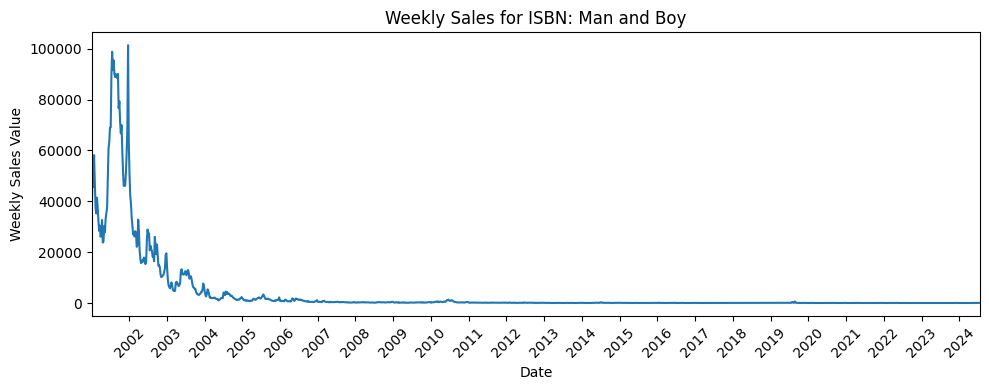

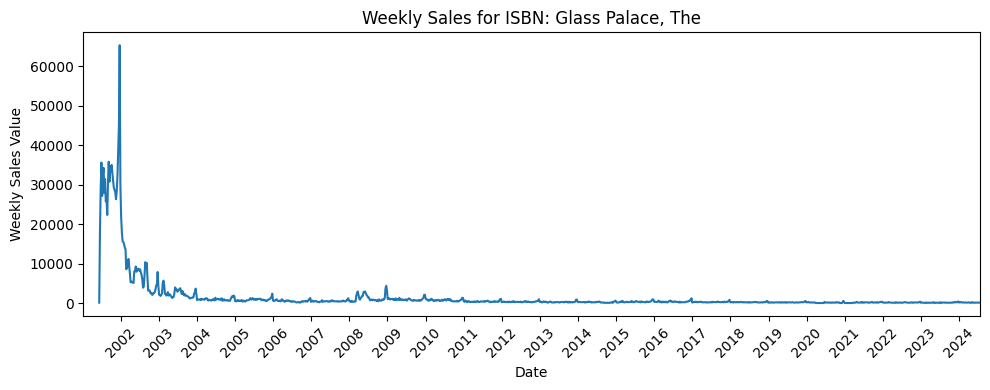

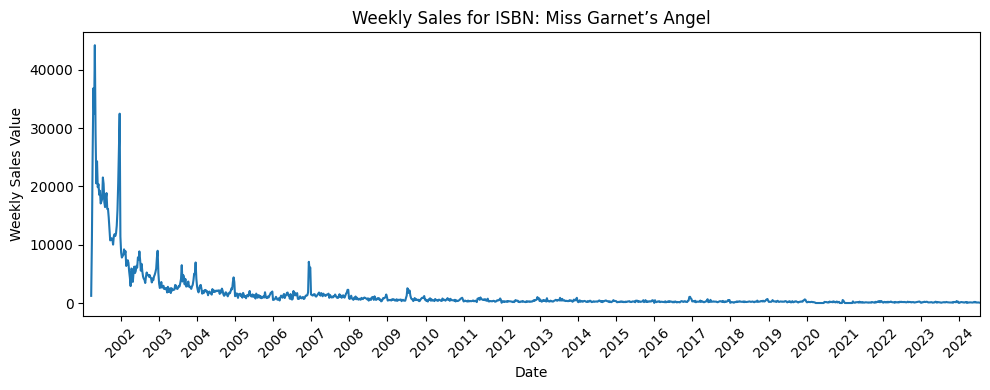

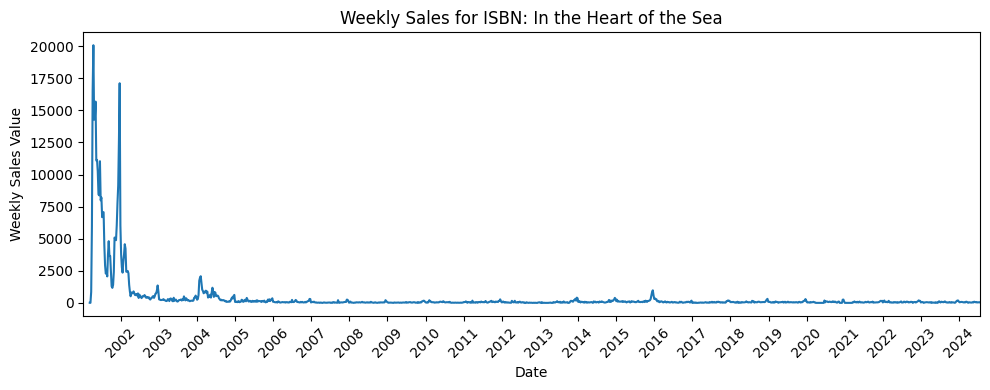

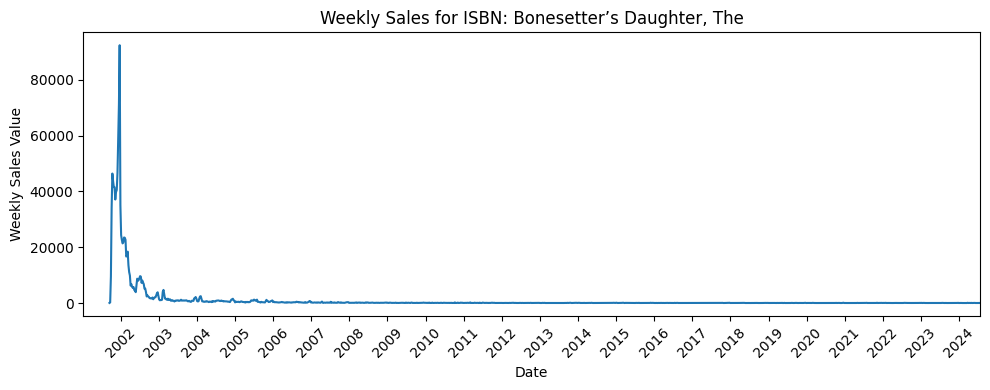

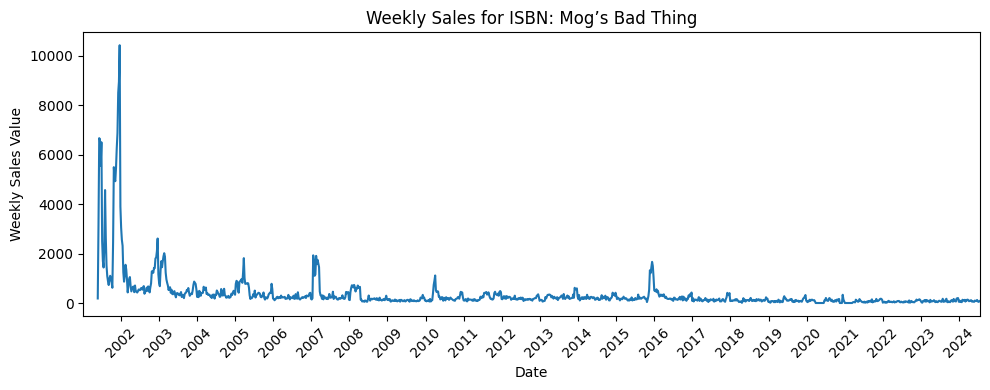

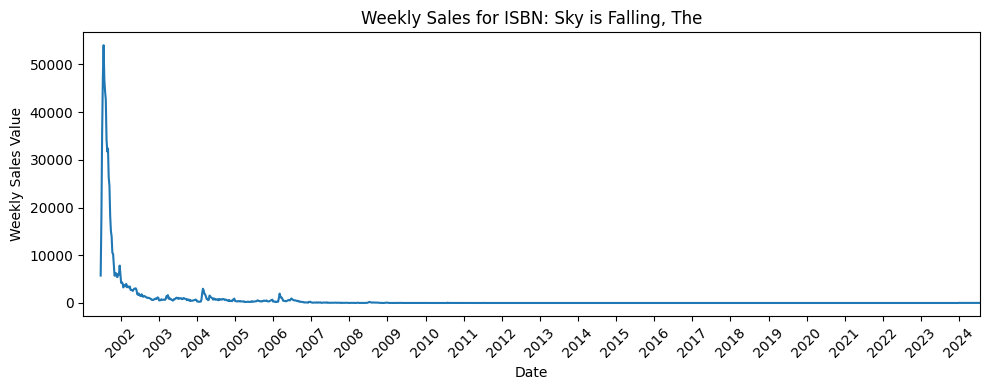

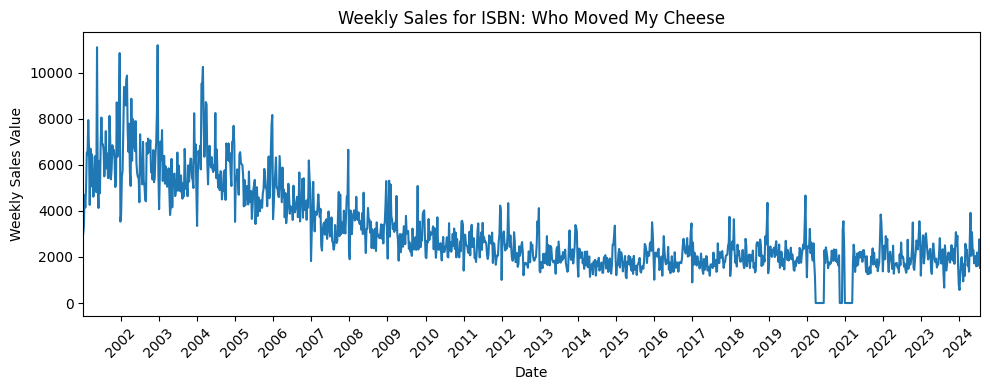

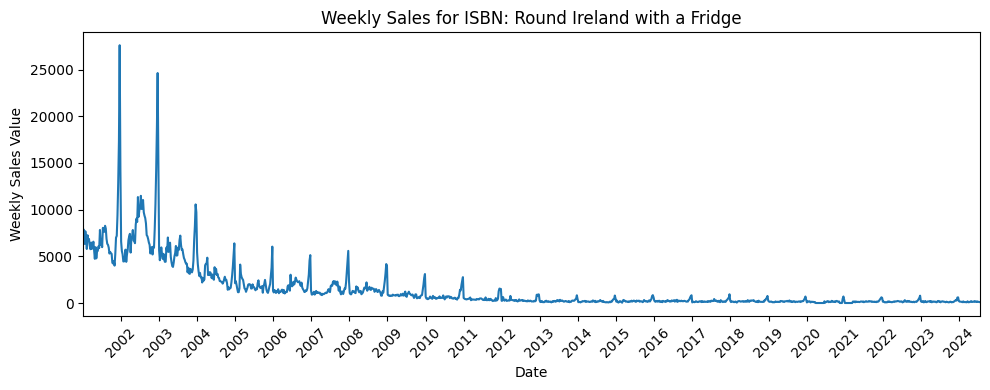

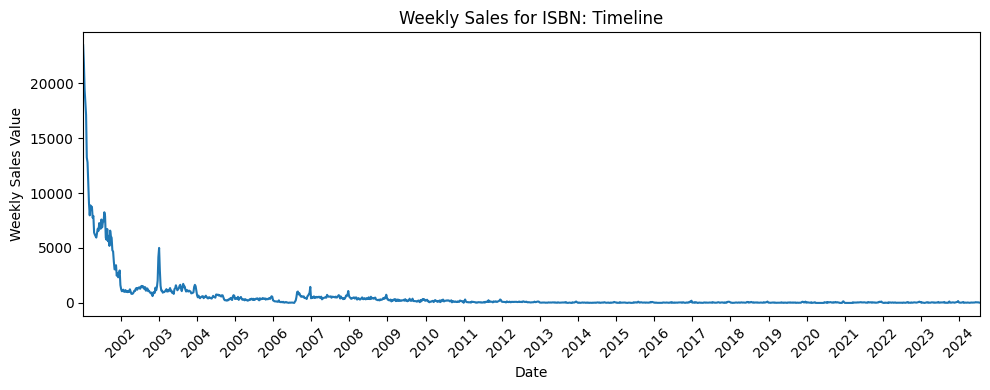

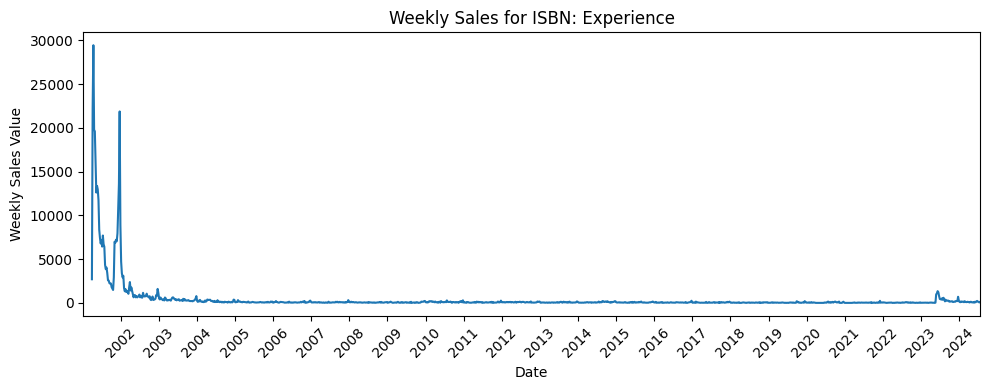

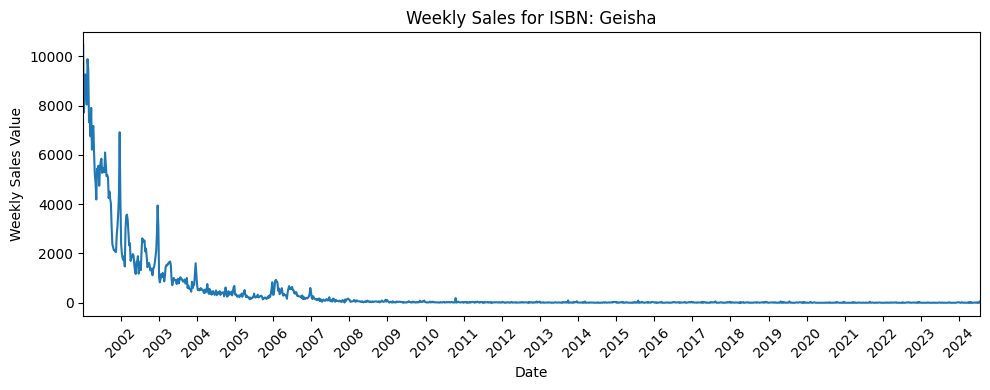

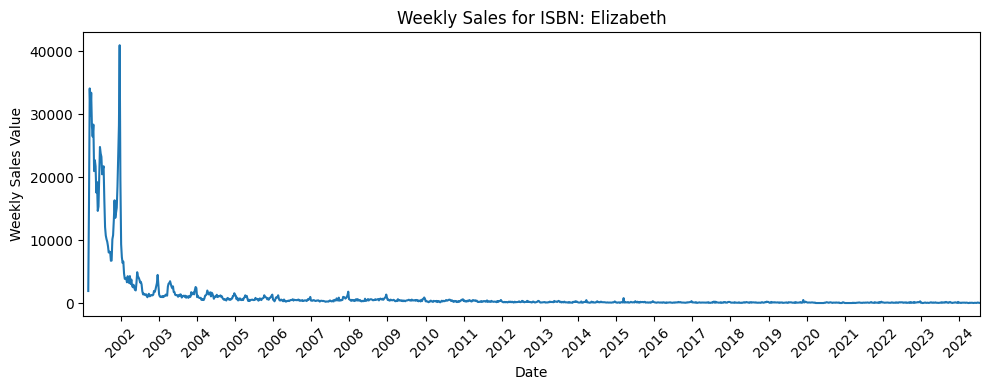

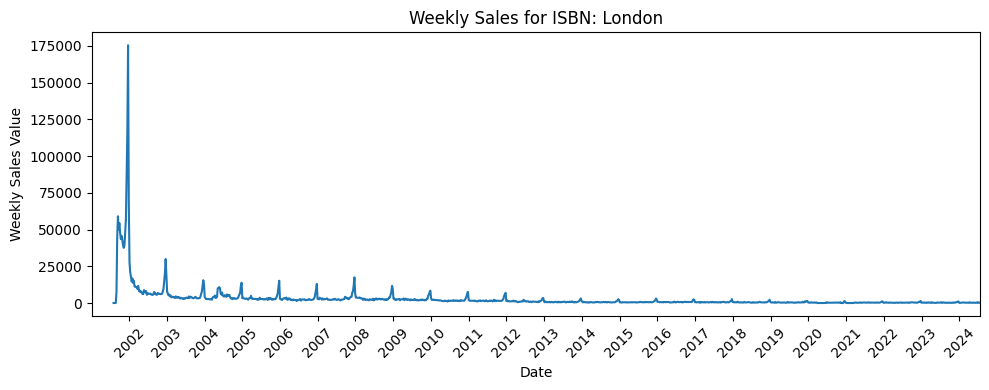

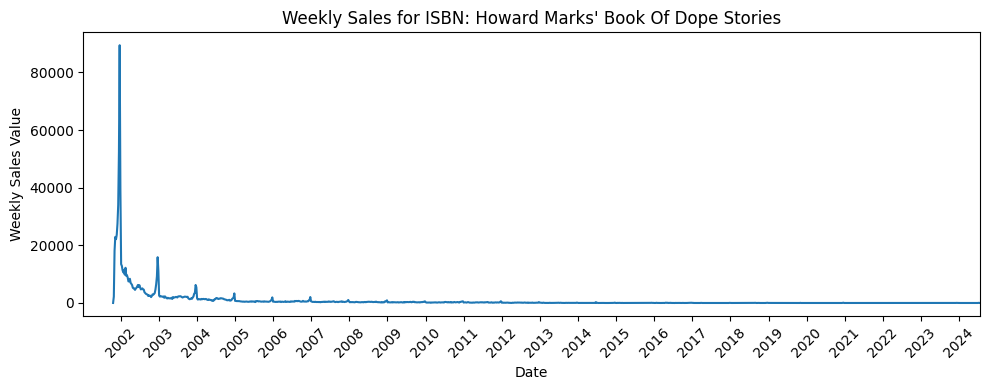

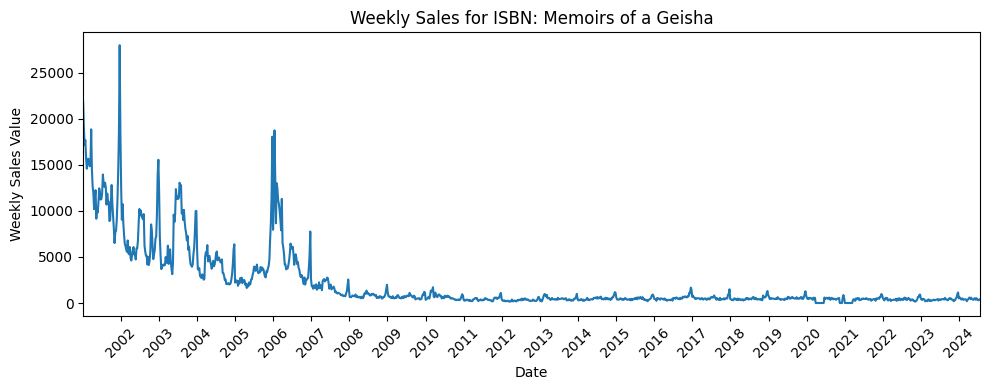

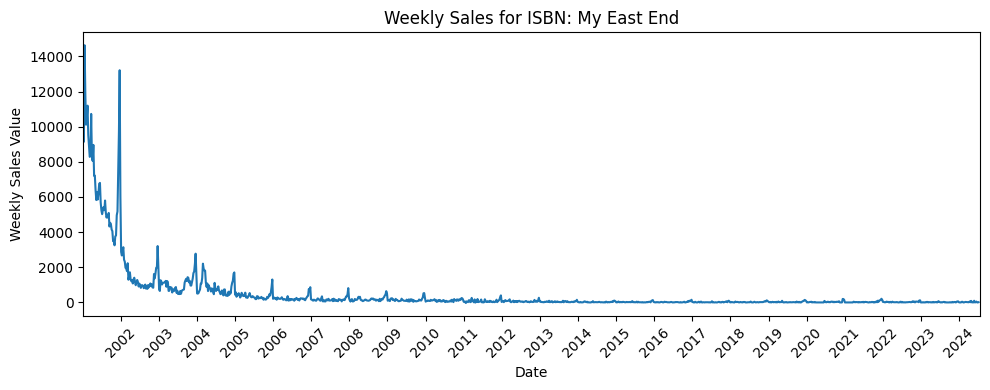

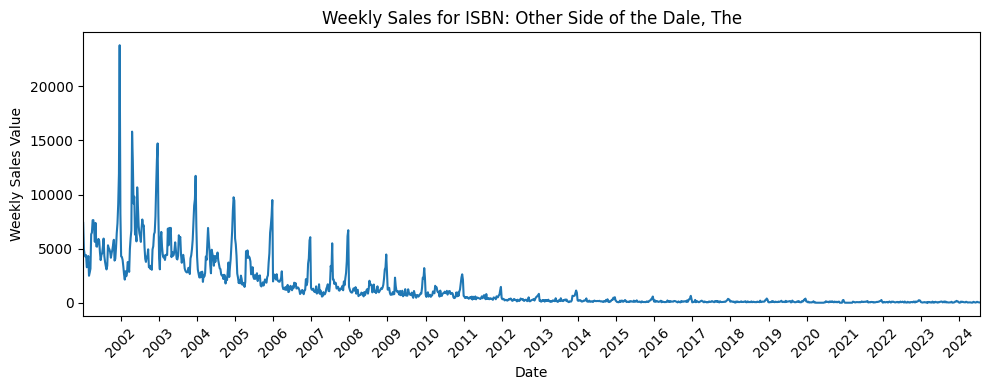

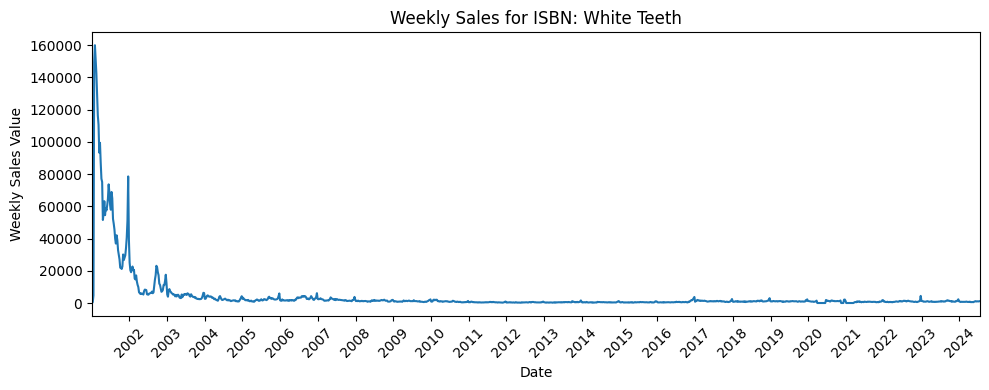

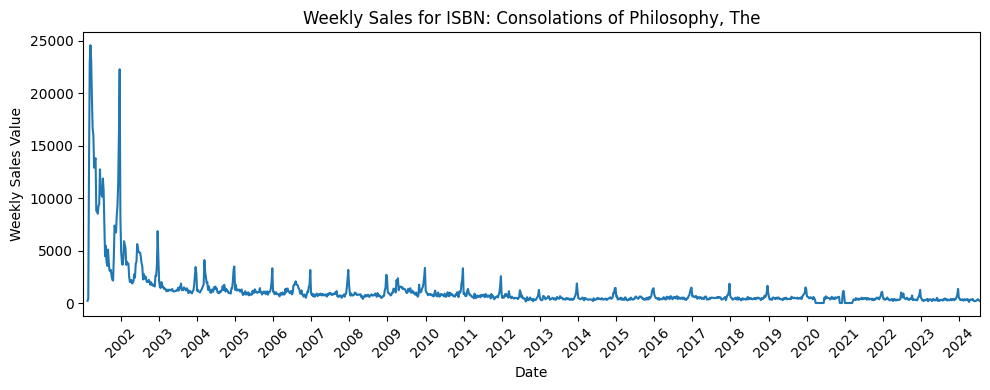

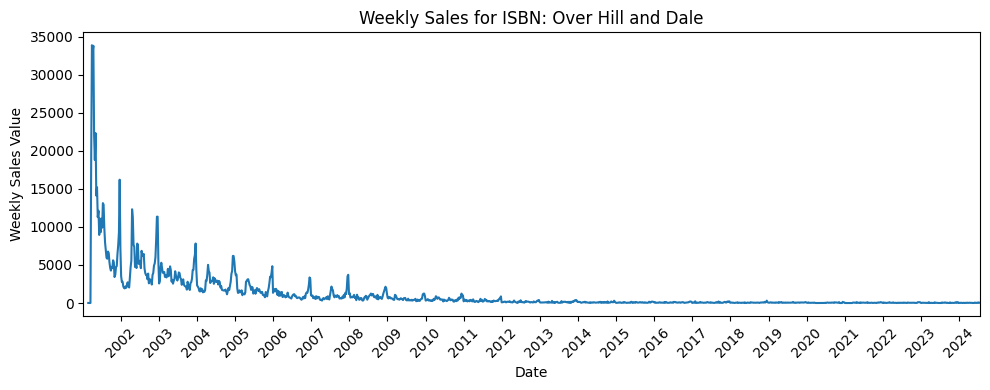

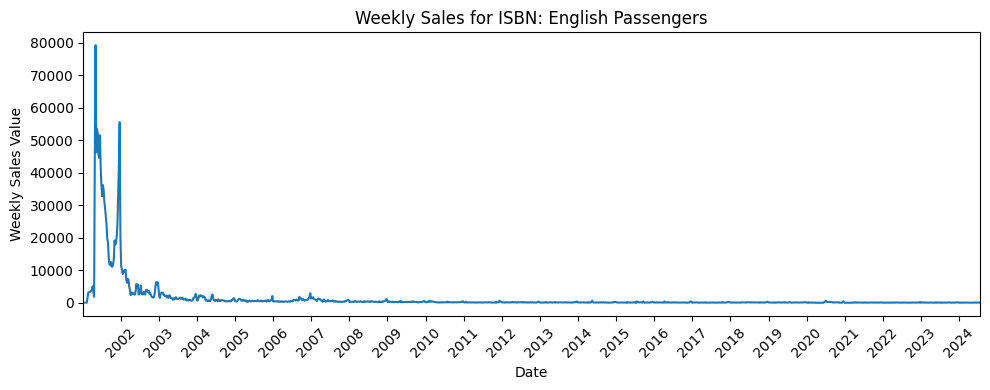

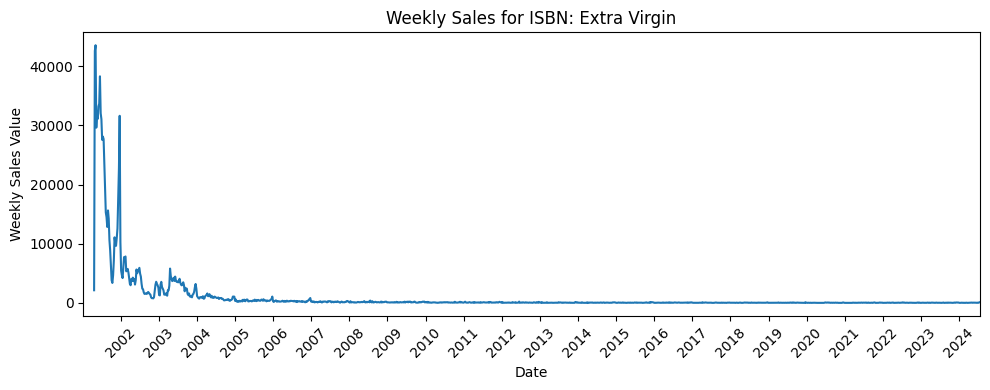

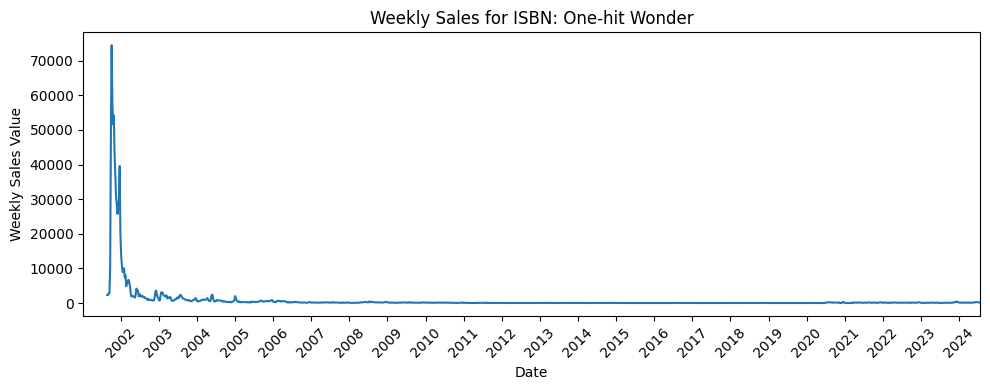

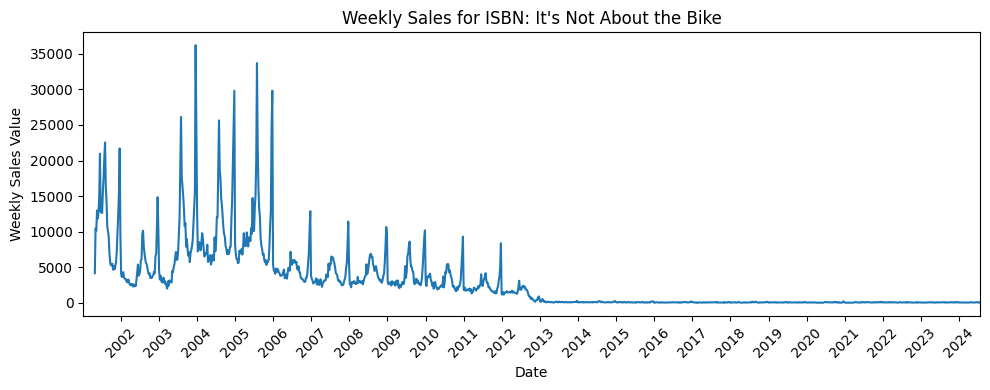

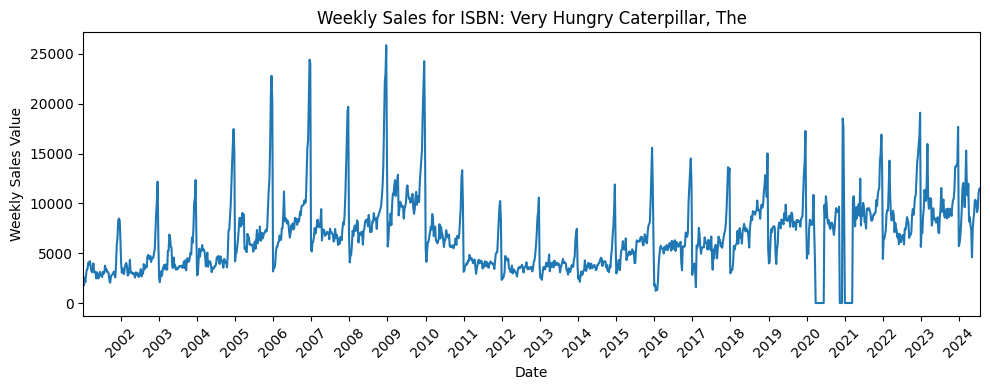

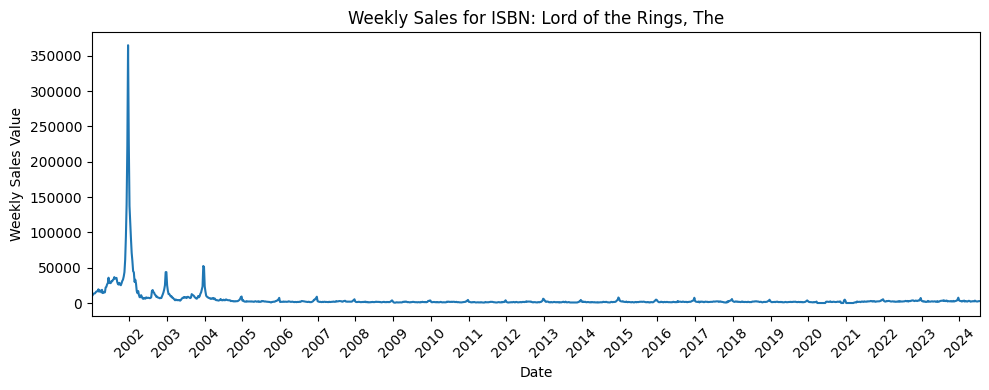

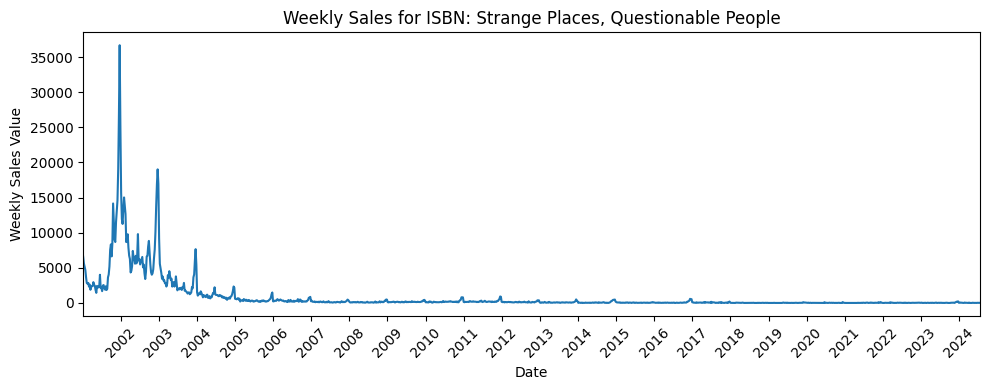

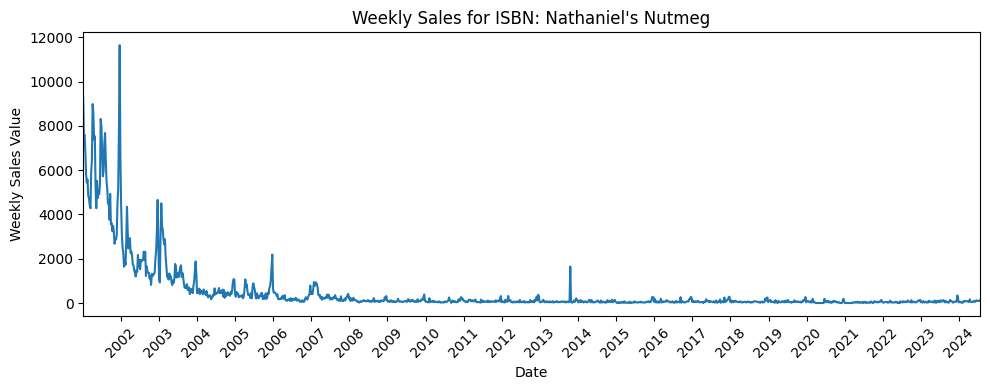

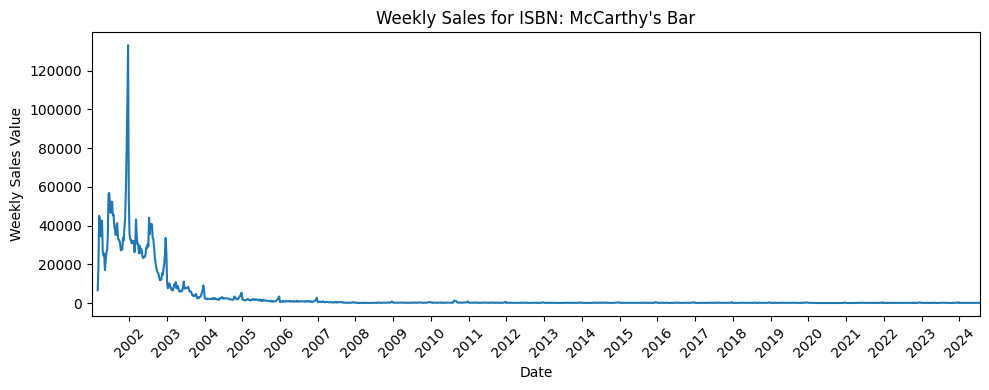

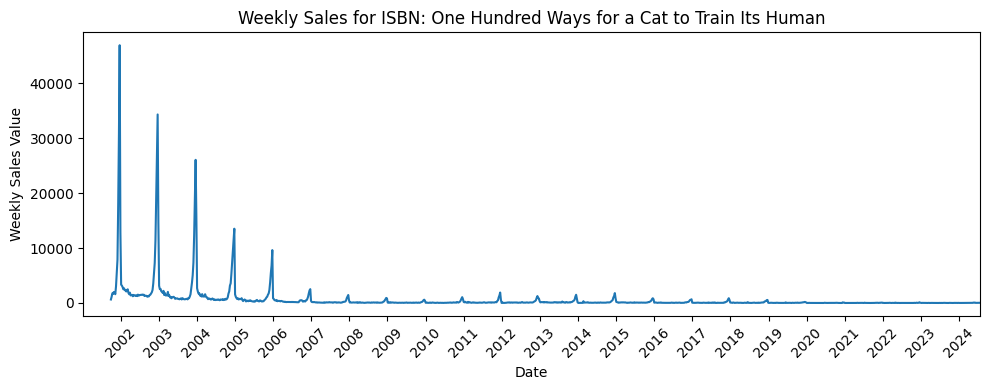

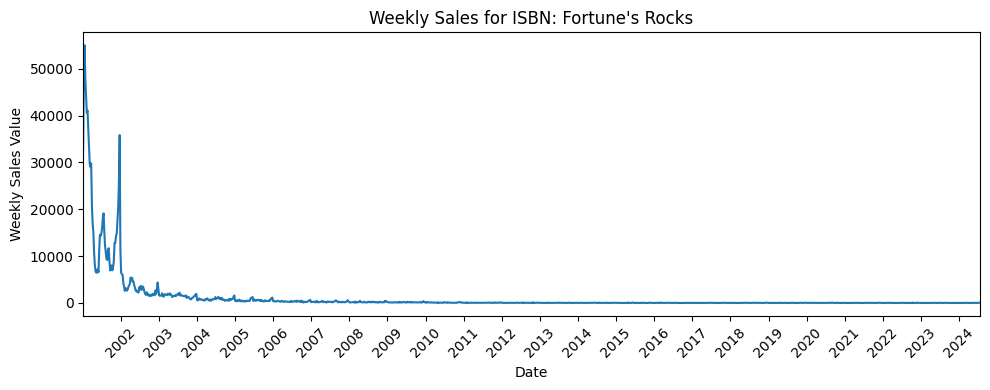

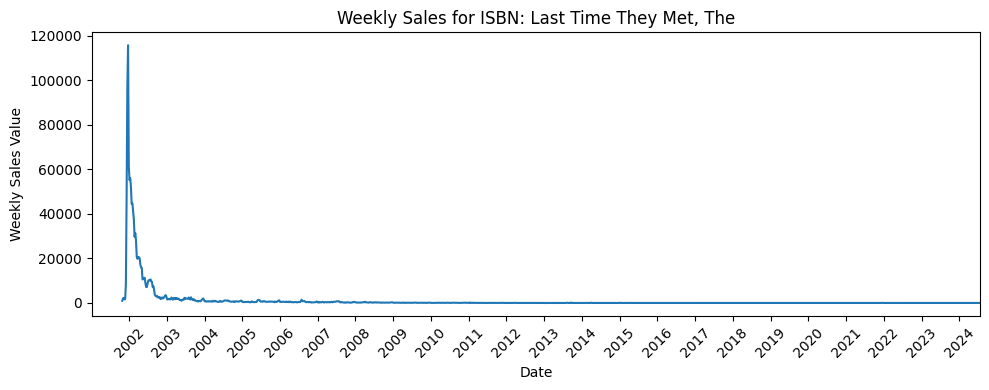

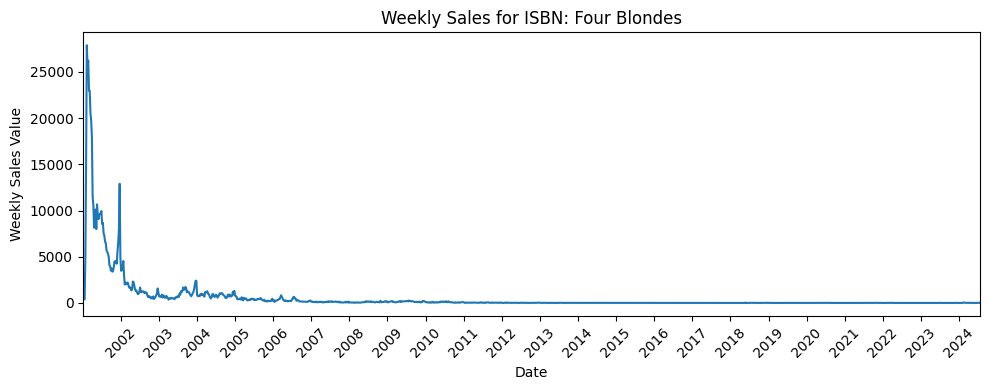

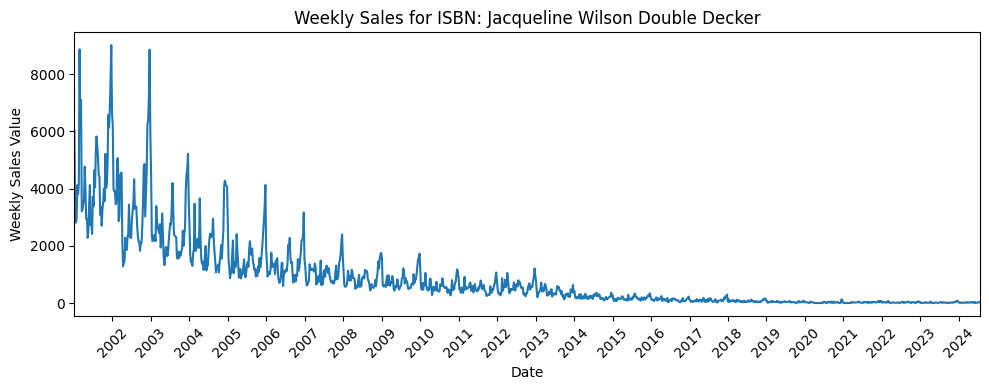

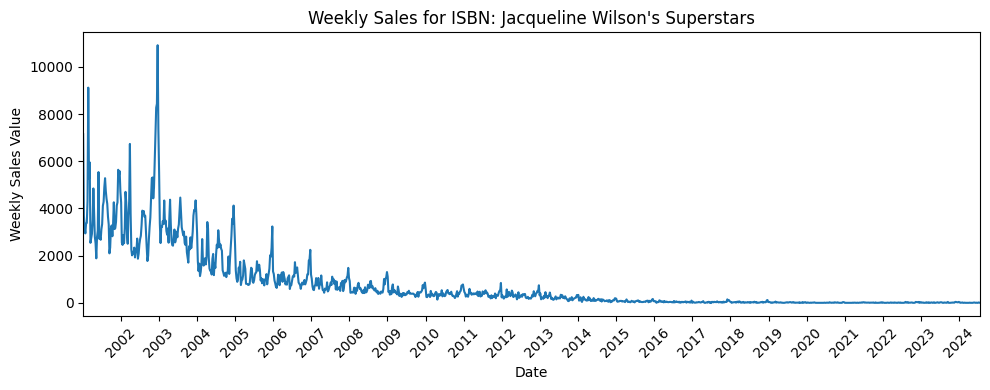

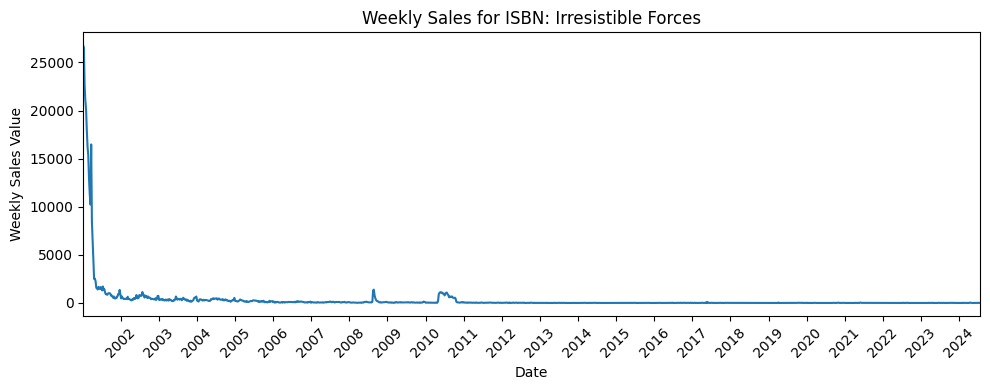

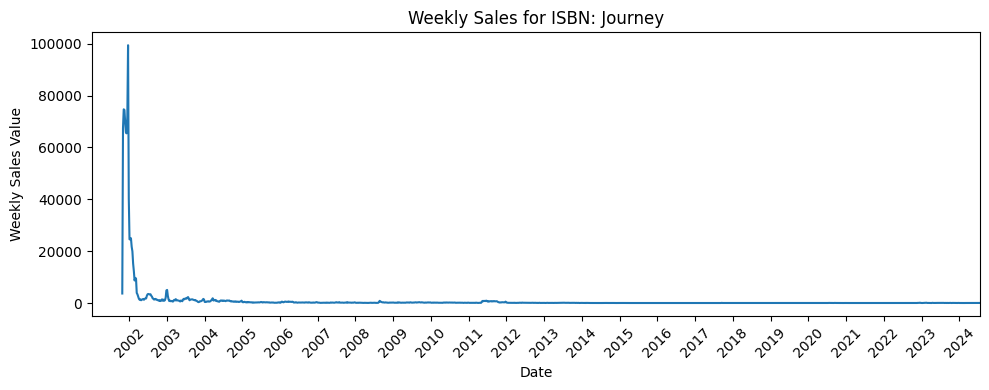

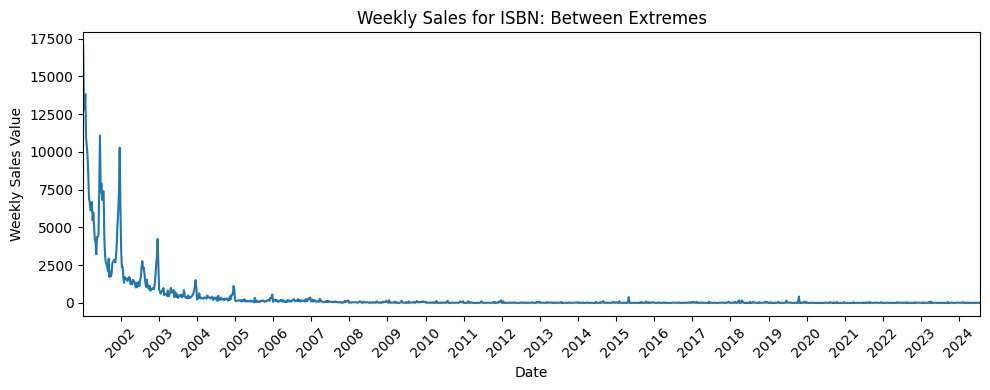

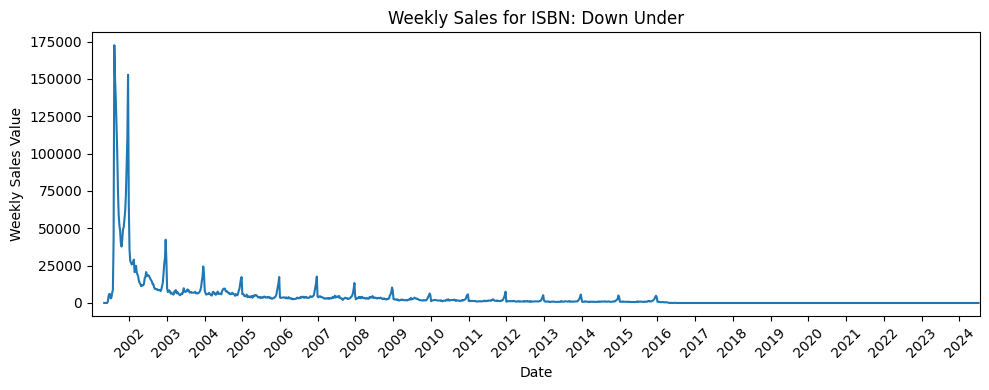

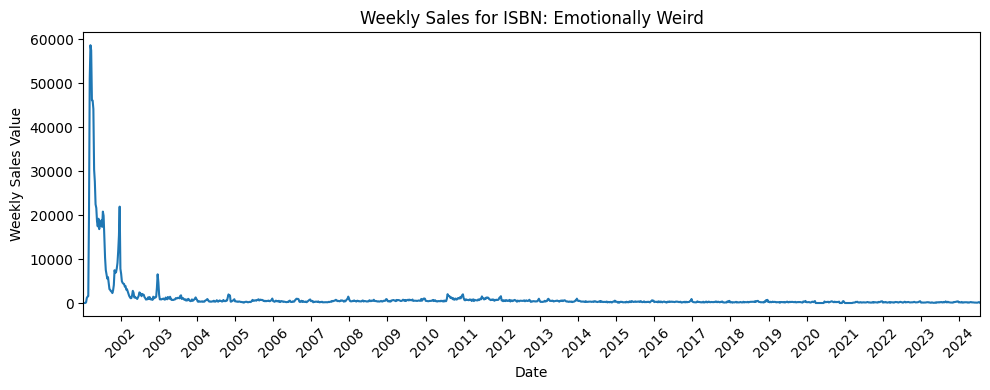

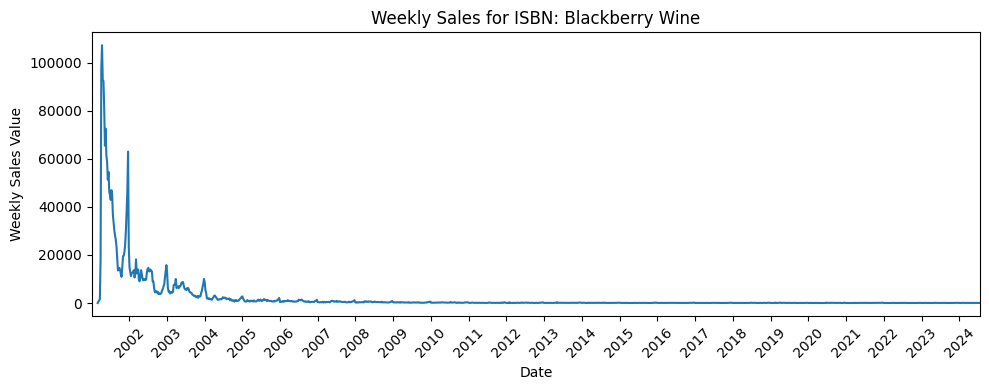

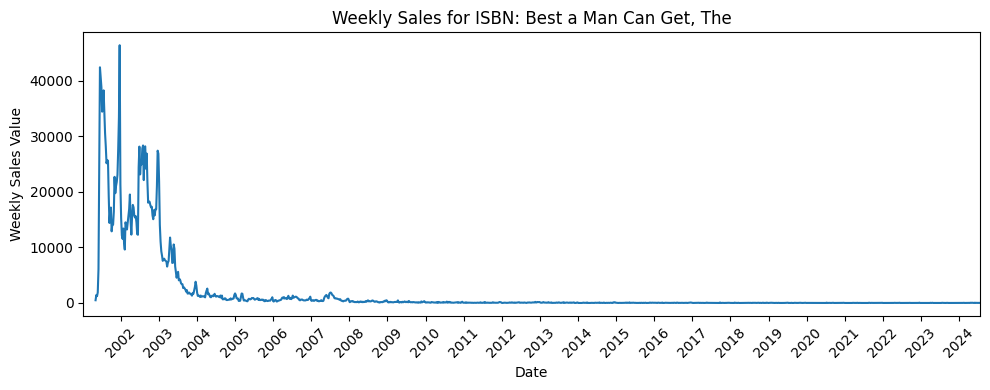

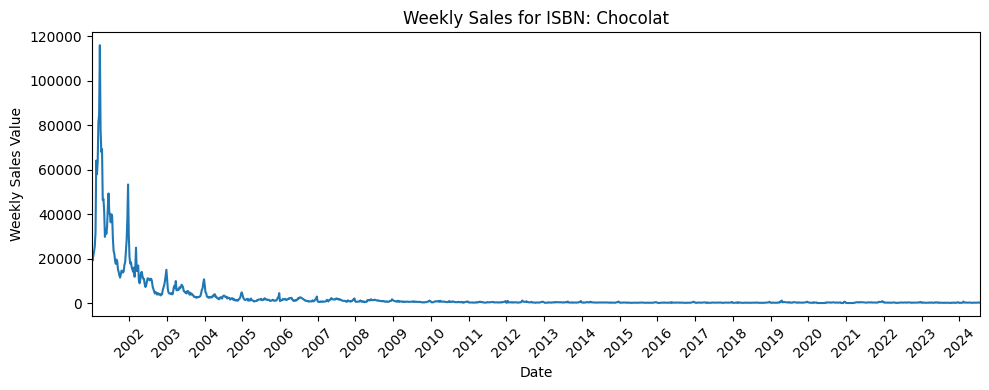

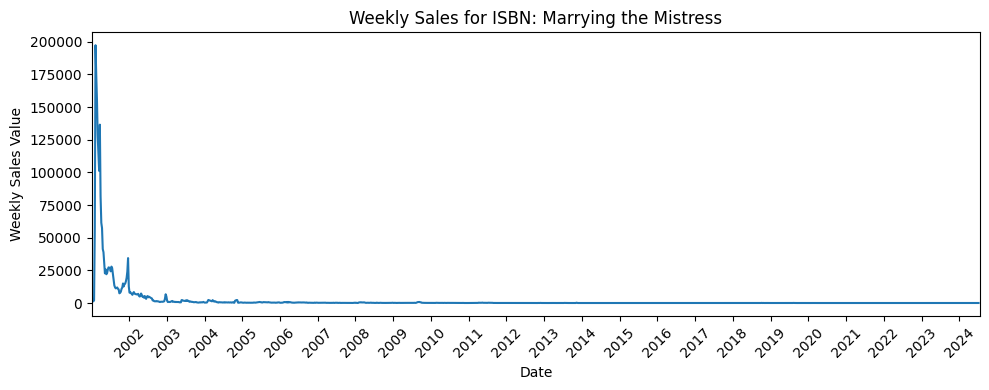

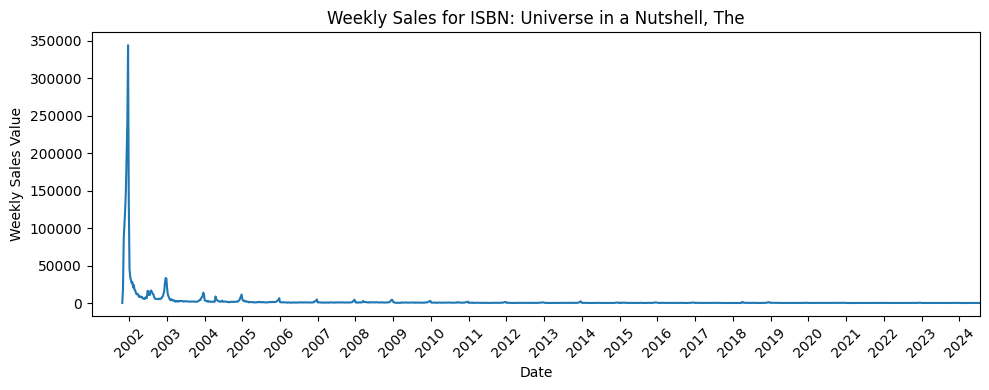

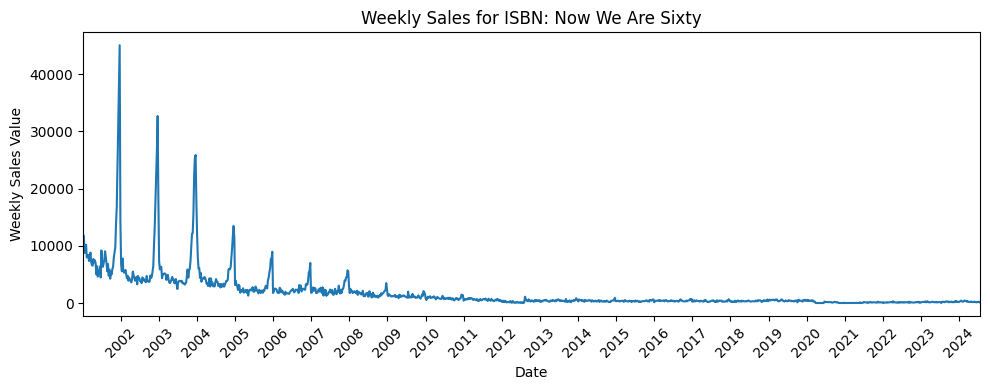

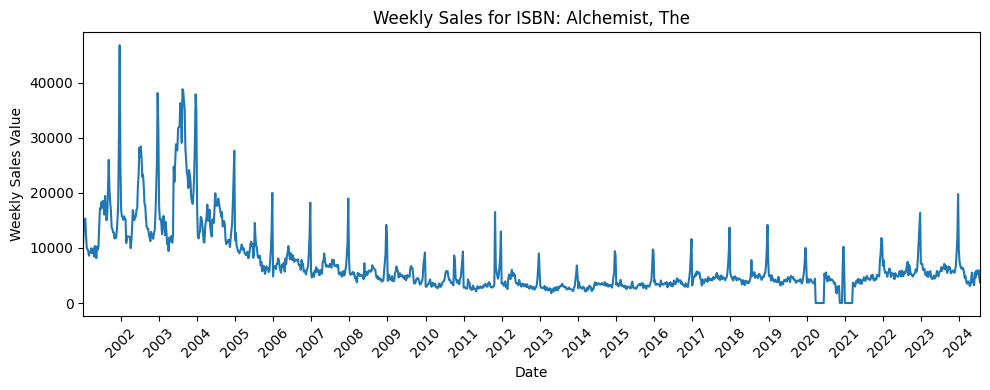

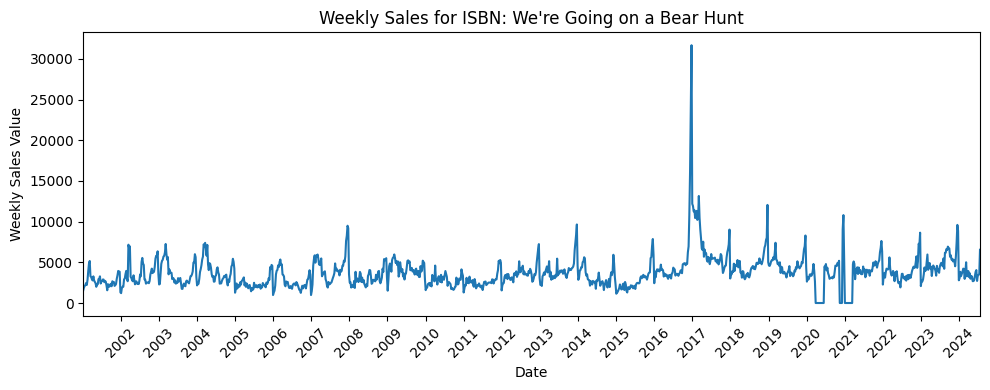

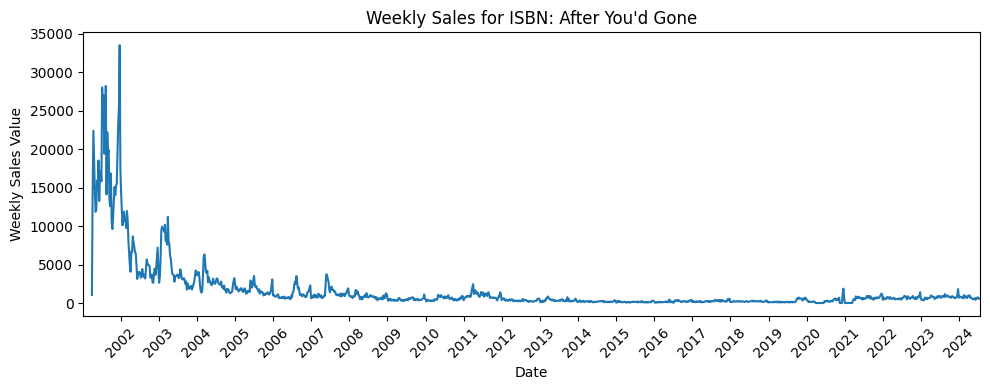

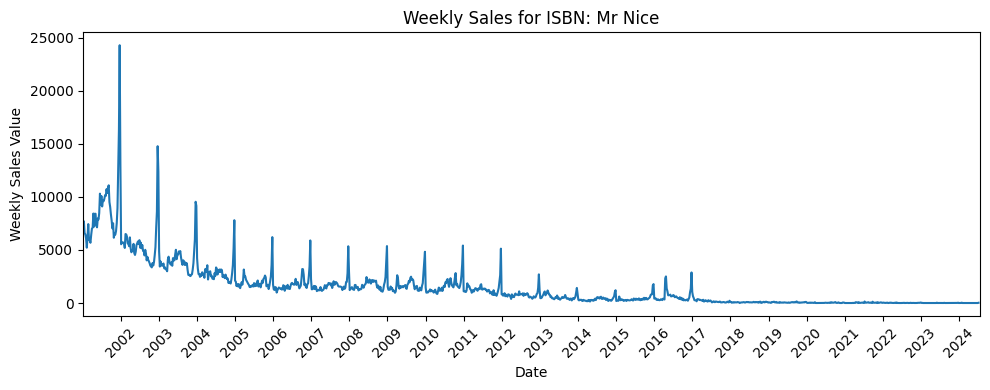

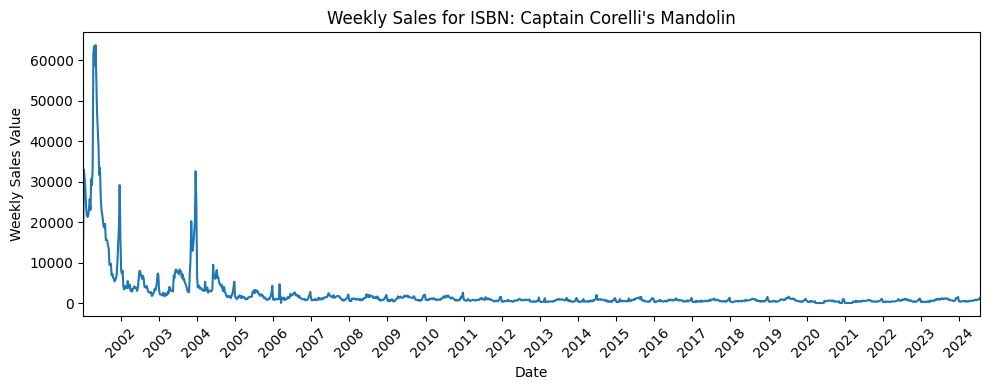

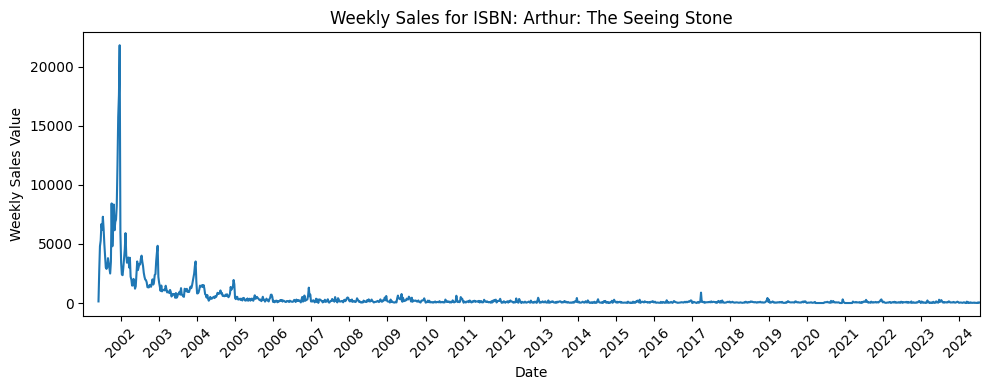

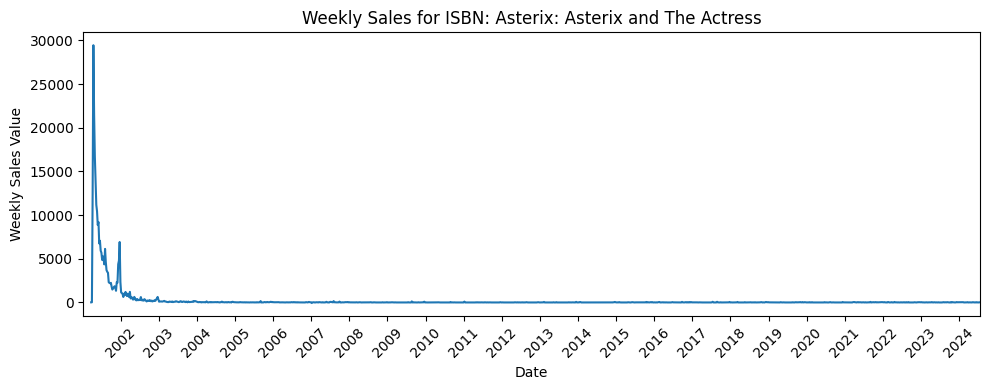

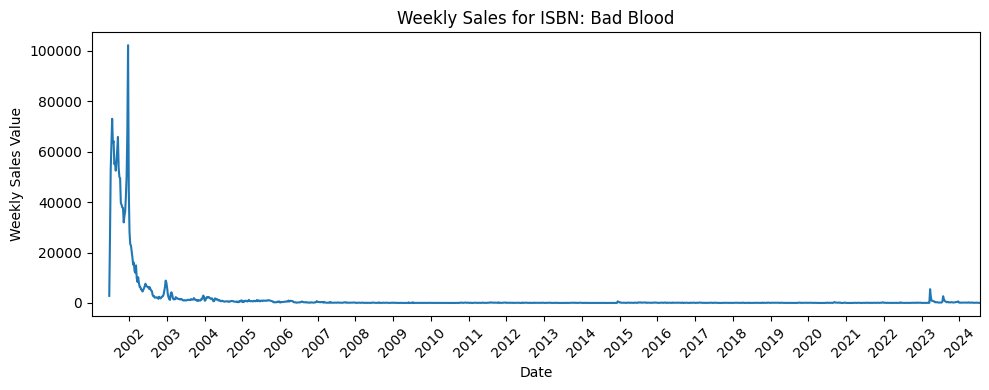

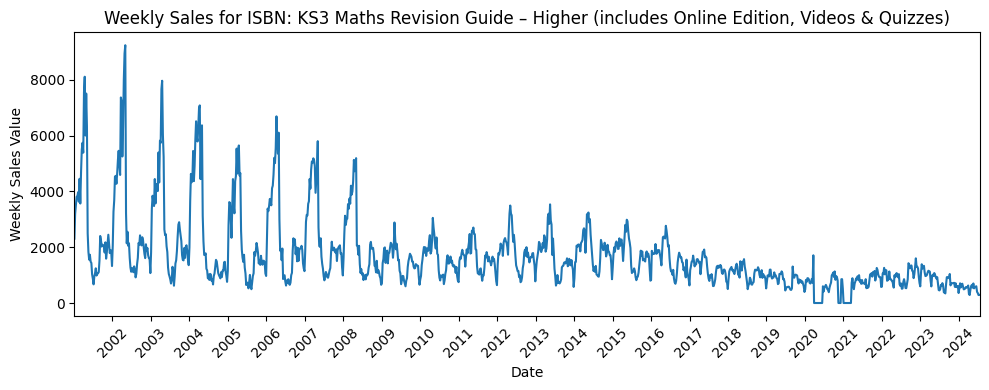

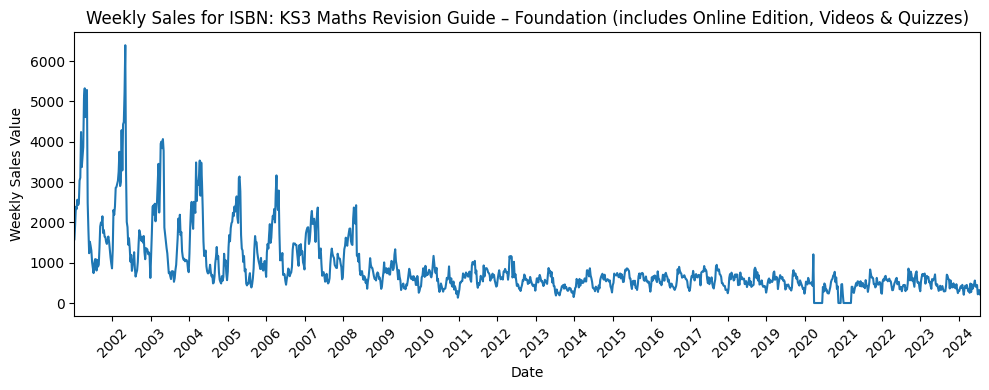

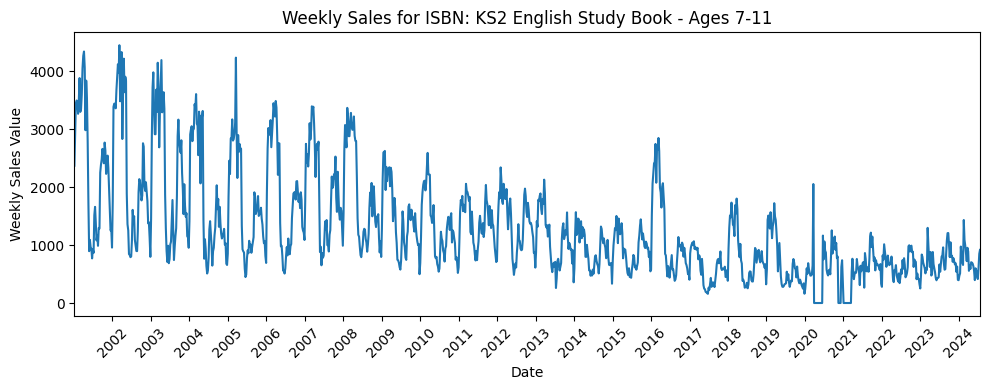

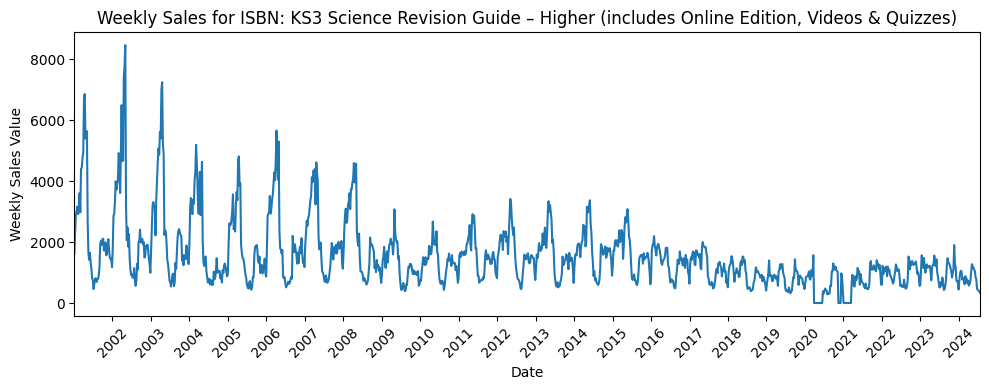

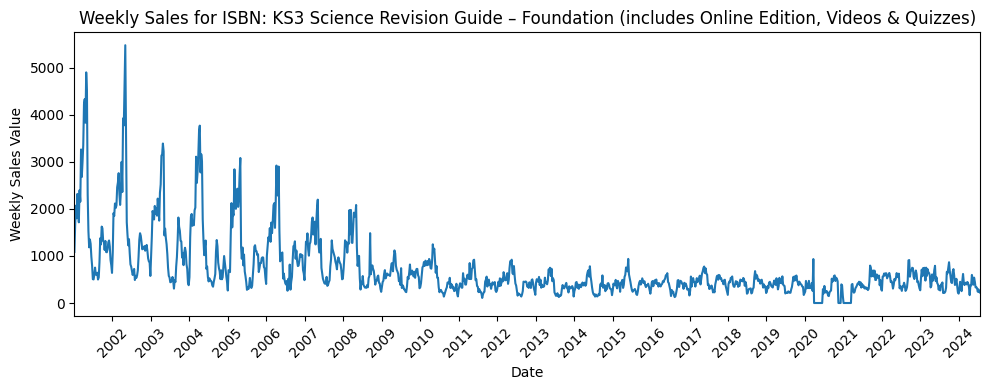

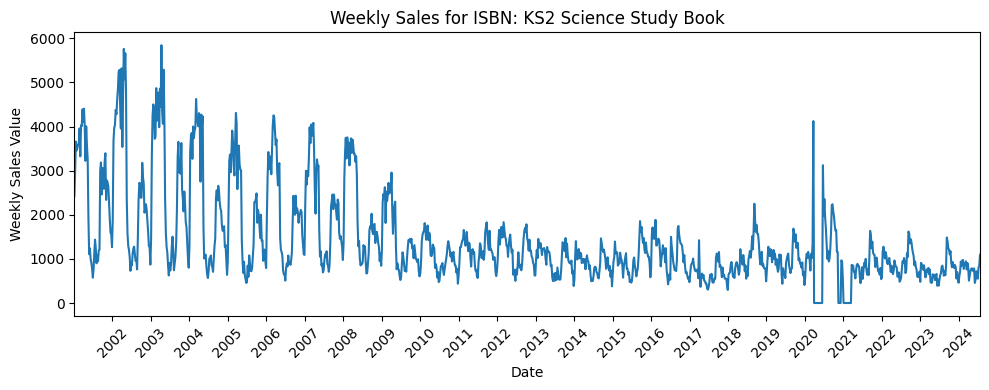

In [ ]:
for x in recent_isbn_list:

  book_title = timeseries_df_resampled.loc[timeseries_df_resampled['ISBN'] == x, 'Title'].iloc[0]

  plotting_data = timeseries_df_resampled[timeseries_df_resampled['ISBN'] == x]

  plt.figure(figsize=(10, 4))

  plt.plot(plotting_data.Value)

  plt.xlim(oldest_date, newest_date)



  plt.title(f"Weekly Sales for ISBN: {book_title}")
  plt.xlabel("Date")
  plt.ylabel("Weekly Sales Value")



  ax = plt.gca()
  ax.xaxis.set_major_locator(mdates.YearLocator()) #tick every year
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) #format as YYYY
  plt.xticks(rotation=45) #rotate for readability

  plt.tight_layout()
  plt.show()

The 61 above plots show weekly sales for books that have been sold in the most recent ~month of the available data. In general, books seem to show seasonality of period 12 months, roughly corresponding with Christmas, indicating that books are regularly bought as gifts.

However, this seasonality isn't always present, nor is it always repeated in the back end of the year.

Education books have broader spikes which may correspond to the lead up to mock and actual exam seasons. Some books show no seasonality and remain near zero for the majority of the span the data includes. This may be because a new version of the same book is released under a different ISBN, therefore reducing sales of the prior ISBN. This could be explored by summating sales of similar title-author pairs through vector embedding similarity scores on each.

The first 12 years show higher sales for many of the fiction and non-fiction works compared to a marked drop off in the latter 12 years. This may indicate the general populus is moving away from reading physical books for entertainment as they move towards other mediums, as this corresponds with the time period where advanced technology became significantly more available to the average person. This relationship is not confirmed and would have to be explored further, such as via time series analysis of iPhone sales compared to book sales to indicate whether there is a statstically significant correlation. Moreover, causation would have to be considered.

Moreover, it is interesting to note that there are three periods around 2020-2022 where sales drop to zero for all books which would be expected to have sales. These time periods seem to align with COVID-19 restrictions which would have closed in-person stores for sales. These periods drop to zero relatively close to the current available data which may throw off model predictions and parameters as they try to learn why the time series dropped to zero.

Imputation of these anomalous periods should be completed for reliable forecasting. This will be omitted for now but completed in a later step so the difference in predictive power, with and without imputation, can be seen.

## Book Selection

Whilst the above plots vary significantly, for further exploration two shall be arbitrarily chosen. These are The Very Hungry Caterpillar and The Alchemist. These are chosen since they seem to contain interesting relationships to test performance of many time series model architectures.

Both seem to show seasonality and do not stay at zero for any significant period demonstrating that they are books that have maintained popularity where others have lost theirs. Moreover, The Alchemist has shown little variance in sales over the past 12 years, whereas The Very Hungry Caterpillar shows greater variance and on a, potentially, increasing trend in the past 12 years, making for interesting comparisons.

In [ ]:
hungry_caterpillar_isbn = timeseries_df_resampled.loc[timeseries_df_resampled["Title"].str.contains("hungry", case=False, na=False) & timeseries_df_resampled["Title"].str.contains("caterpillar", case=False, na=False), "ISBN"].unique().tolist()

print(hungry_caterpillar_isbn)

['9780140500875', '9780241003008']


Note that there are two ISBNs for The Very Hungry Caterpillar, corresponding to both hardback and paperback versions. The hardback version is the one visualised above, `9780241003008`, so this is chosen to proceed with.

In [ ]:
hungry_caterpillar_isbn = hungry_caterpillar_isbn[1] #only keep the desired ISBN
hungry_caterpillar_isbn = str(hungry_caterpillar_isbn) #convert to string

print(hungry_caterpillar_isbn)

9780241003008


In [ ]:
alchemist_isbn = timeseries_df_resampled.loc[timeseries_df_resampled["Title"].str.contains("alchemist", case=False, na=False), "ISBN"].unique().tolist()
alchemist_isbn = str(alchemist_isbn[0]) #convert to string

print(alchemist_isbn)

9780722532935


In [ ]:
print(timeseries_df_resampled.index)

DatetimeIndex(['2001-01-06', '2001-01-13', '2001-01-20', '2001-01-27',
               '2001-02-03', '2001-02-10', '2001-02-17', '2001-02-24',
               '2001-03-03', '2001-03-10',
               ...
               '2008-10-18', '2008-10-25', '2008-11-01', '2008-11-08',
               '2008-11-15', '2008-11-22', '2008-11-29', '2008-12-06',
               '2008-12-13', '2008-12-20'],
              dtype='datetime64[ns]', name='End Date', length=382871, freq=None)


In [ ]:


hungry_caterpillar = timeseries_df_resampled[(timeseries_df_resampled["ISBN"].str.strip() == str(hungry_caterpillar_isbn)) & (timeseries_df_resampled.index > "2012-01-01")] #filtering to get relevant records
hungry_caterpillar = hungry_caterpillar["Value"] #extracting 1D series with End Date as index for subsequent methods

alchemist = timeseries_df_resampled[(timeseries_df_resampled["ISBN"].str.strip() == str(alchemist_isbn)) & (timeseries_df_resampled.index > "2012-01-01")] #filtering to get relevant records
alchemist = alchemist["Value"] #extracting 1D series with End Date as index for subsequent methods


print(f"TVHC: {hungry_caterpillar_isbn}") #confirm ISBN
display(hungry_caterpillar) #view series

print(f"-------------------------\nTA: {alchemist_isbn}") #confirm ISBN
display(alchemist) #view series

TVHC: 9780241003008


,Value
End Date,
2012-01-07,2522.13
2012-01-14,2473.31
2012-01-21,2757.83
2012-01-28,3072.66
2012-02-04,4724.18
...,...
2024-06-22,9126.36
2024-06-29,9517.24
2024-07-06,10974.10


-------------------------
TA: 9780722532935


,Value
End Date,
2012-01-07,3601.76
2012-01-14,3610.12
2012-01-21,3105.62
2012-01-28,3431.29
2012-02-04,3929.22
...,...
2024-06-22,5182.65
2024-06-29,5530.58
2024-07-06,5947.09


In [ ]:
#renaming series names from value to the book name
hungry_caterpillar.name = "The Very Hungry Caterpillar"
alchemist.name = "The Alchemist"

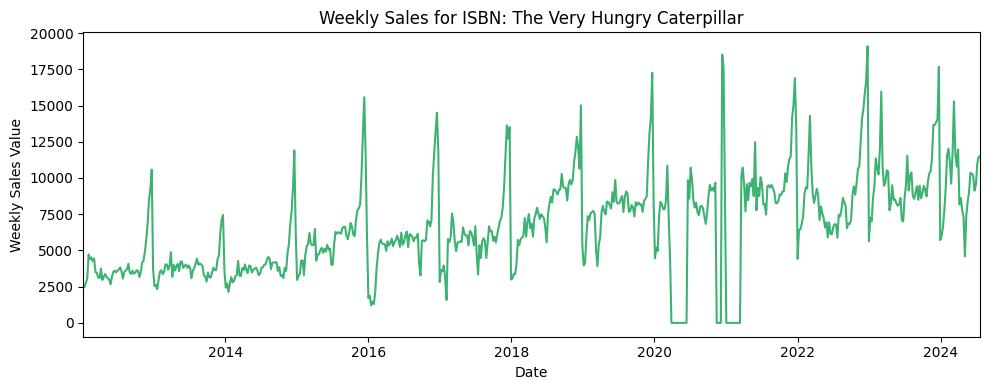

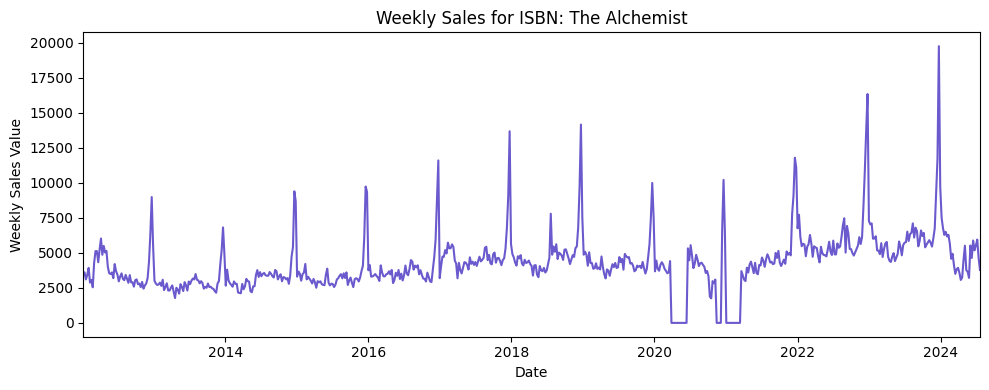

In [ ]:
mid_date = min(hungry_caterpillar.index) #get oldest date of the last 12 years for plotting

for idx, x in enumerate([hungry_caterpillar, alchemist]): #plot each of the time series for confirmation they have been correctly extracted
  plt.figure(figsize=(10, 4))
  if idx == 0: #using if else for plot title and colour since x.name will not return the variable name of the series, instead it will give the namve of the series "column" which is "value", from prior df
    plt.plot(x, color = 'mediumseagreen')
  else:
    plt.plot(x, color = 'slateblue')
  plt.title(f"Weekly Sales for ISBN: {x.name}")
  plt.xlabel("Date") #set x axis label
  plt.ylabel("Weekly Sales Value") #set y axis label
  plt.xlim(mid_date, newest_date) #set appropriate x axis limits
  plt.tight_layout()
  plt.show()

# Diagnostics

## STL Decomposition and Transformations

Two types of decomposition exist: additive and multiplicative. The former is used when the amplitude of seasonal variation is relatively constant over time, whereas the latter is used when the amplitude of seasonal fluctuations change over time.

Two models are considered here: X11 and STL. X11 can complete both additive and multiplicative decomposition, yet it is restricted to data with monthly/quarterly frequency. Therefore, STL will be chosen.

However, STL is strictly an additive decomposition model which requires seasonal amplitude to show little variance. The time series for The Very Hungry Caterpillar and The Alchemist both show variation in the amplitude of their seasonal component across time so transformations should be done to adjust these for decomposition.

In [ ]:
#defining common transformation functions
def standardise_data(data):
  standardised_data = ((data - data.mean()) / data.std())
  return standardised_data

def reciprocal_data(data):
  transformed_data = 1/data
  return transformed_data

def log_data(data):
  transformed_data = np.log(data)
  return transformed_data

def root_data(data):
  transformed_data = np.sqrt(data)
  return transformed_data

def box_cox(data):
  index = data.index #extract original index
  transformed_array, lam = boxcox(data)
  transformed_data = pd.Series(transformed_array, index=index) #make array into series and restore index so behaves like other transformations
  return transformed_data, lam

In [ ]:
def compare_transformations(data): #function to visualise different transformations
  #applying transformations
  std_orig = standardise_data(data)
  std_log = standardise_data(log_data(data))
  std_root = standardise_data(root_data(data))
  std_reciprocal = standardise_data(reciprocal_data(data))

  box_cox_data, box_cox_lam = box_cox(data)
  std_box_cox = standardise_data(box_cox_data)

  #plotting transformations
  fig, axes = plt.subplots(5, 1, figsize=(10, 8)) #5 plots for 5 visualisations

  axes[0].set_title(data.name) #title of book at top

  #for each transformation type, plot black line with appropriate legend
  axes[0].plot(std_orig, label='Original (standardised)', color="black")
  axes[0].legend(loc=9)

  axes[1].plot(std_log, label='Log', color="black")
  axes[1].legend(loc=9)

  axes[2].plot(std_root, label='Root', color="black")
  axes[2].legend(loc=9)

  axes[3].plot(std_reciprocal, label='Reciprocal', color="black")
  axes[3].legend(loc=9)

  axes[4].plot(std_box_cox, label='Box Cox', color="black")
  axes[4].legend(loc=9)

The current `hungry_caterpillar` and `alchemist` time series contain zero values for the missing weeks that correlate with COVID. Applying transformations now will not work since zero values are not tolerated by the transformations as leave an undefined transformation output (e.g. /0 and log(0))

Therefore, these zero values should be (roughly) imputed so these transformations can be applied. Zero values will be replaced with NaN and then linearlly imputed. Since time steps are evenly spaced, linear interpolation works here.

In [ ]:
hungry_caterpillar_rough_interpolation = hungry_caterpillar.replace(0, np.nan).interpolate(method="linear")
alchemist_rough_interpolation = alchemist.replace(0, np.nan).interpolate(method="linear")

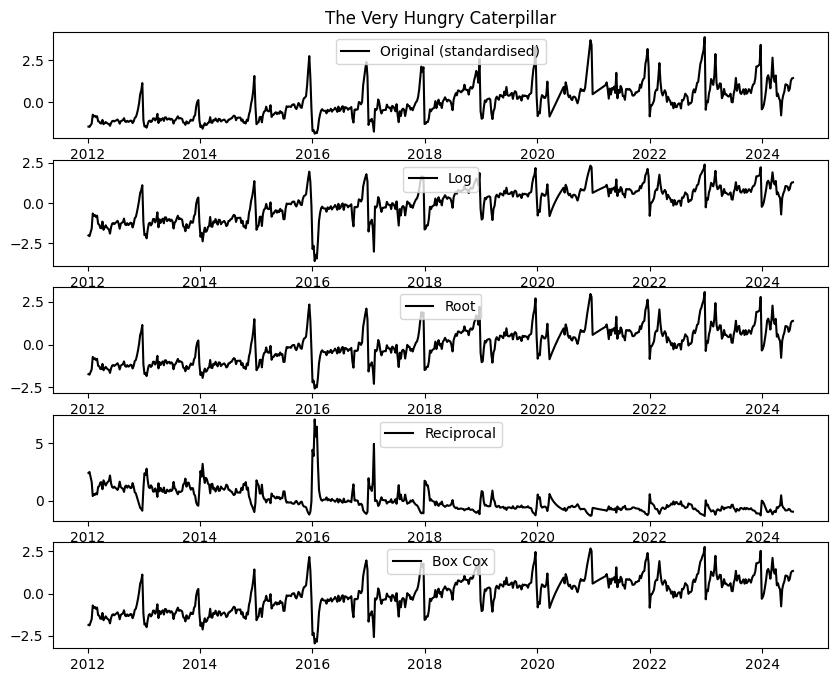

In [ ]:
compare_transformations(hungry_caterpillar_rough_interpolation)

The first plot highlights the issue of the seasonal amplitude variance when looking at the seasonal spike around the 2014 tick compared to the seasonal spike around any of the later ticks.

The various transformation change the shape of the data in different ways.

The reciprocal transformation exaggerates the 2016 spike and compresses later seasonality, meaning this is not an appropriate transformation.

Visual inspection of other transformations affords that the Box Cox transformation gives an ideal transformation with the most consistent seasonal spike amplitudes.

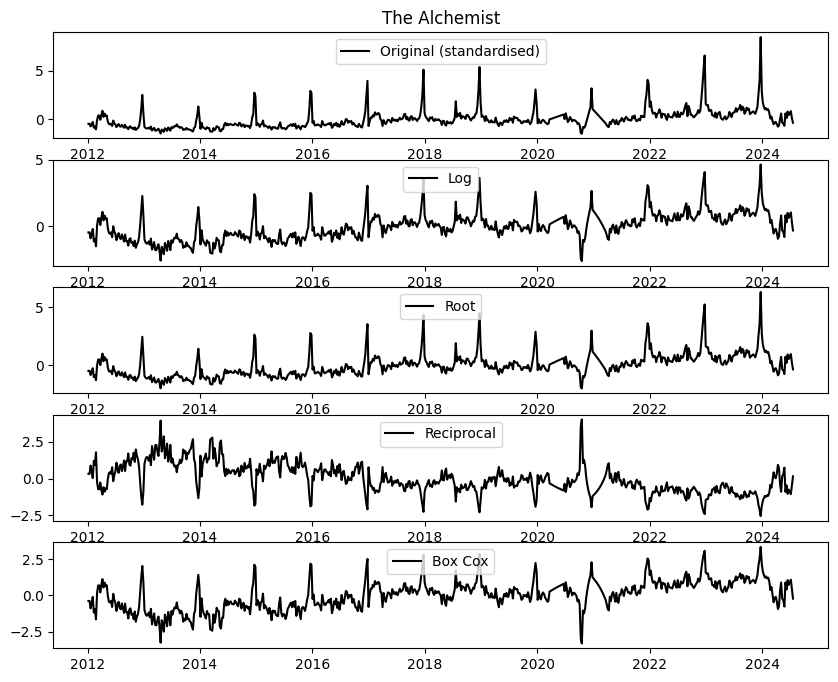

In [ ]:
compare_transformations(alchemist_rough_interpolation)

The first plot highlights the issue, with seasonal spikes getting increasingly large as time goes on. The imputed values fall around one of the seasonal spikes, making for a unique, broader, spike shape due to the linear interpolation.

Subjective visual inspection shows the Log transformation gives the most consistent amplitude of seasonal peaks, so this is the transformation chosen for The Alchemist.

Now, the chosen transformations can be applied to the time series when passing to the additive STL decomposition model.

In [ ]:
#define reusable function to decompose a time series
def stl_decomposer(data, period=52, seasonal=13, trend=251): #initialise default values which make sense for the period being analysed - leaving adjusttable if neccesary
    stl = STL(data, period=period, seasonal=seasonal, trend=trend)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(10, 8))

    if "hungry" in str(data.name).lower():
      color = "mediumseagreen"
    else:
      color = "slateblue"

    axes[0].set_title(data.name)
    axes[0].plot(data, label='Original', color=color)
    axes[0].legend(loc=9)

    axes[1].plot(result.trend, label='Trend', color='dodgerblue')
    axes[1].legend(loc=9)

    axes[2].plot(result.seasonal, label='Seasonal', color='darkorange')
    axes[2].legend(loc=9)

    axes[3].plot(result.resid, label='Residual', color='black')
    axes[3].legend(loc=9)

    plt.tight_layout()
    plt.show()

    seasonal_component = result.seasonal
    trend_component = result.trend

    return result, seasonal_component, trend_component

In [ ]:
hungry_caterpillar_rough_interpolation_transformed, hungry_caterpillar_lambda = box_cox(hungry_caterpillar_rough_interpolation)

alchemist_rough_interpolation_transformed = log_data(alchemist_rough_interpolation)

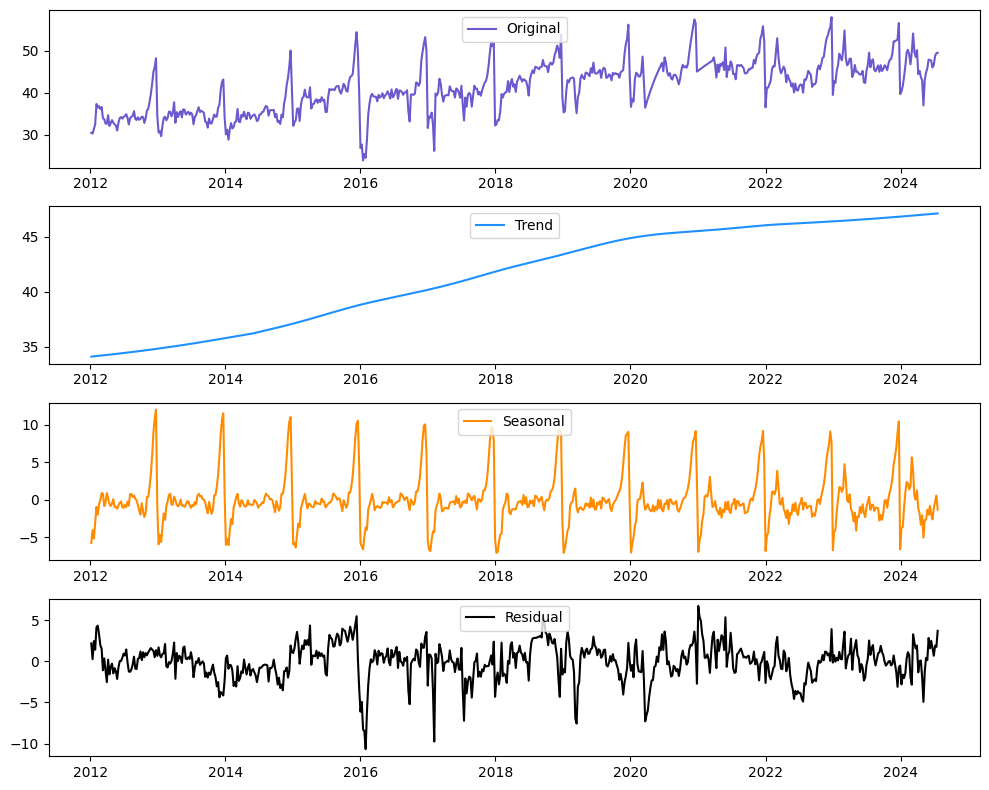

In [ ]:
_, hungry_caterpillar_rough_interpolation_transformed_seasonal_component, hungry_caterpillar_rough_interpolation_transformed_trend_component = stl_decomposer(hungry_caterpillar_rough_interpolation_transformed)

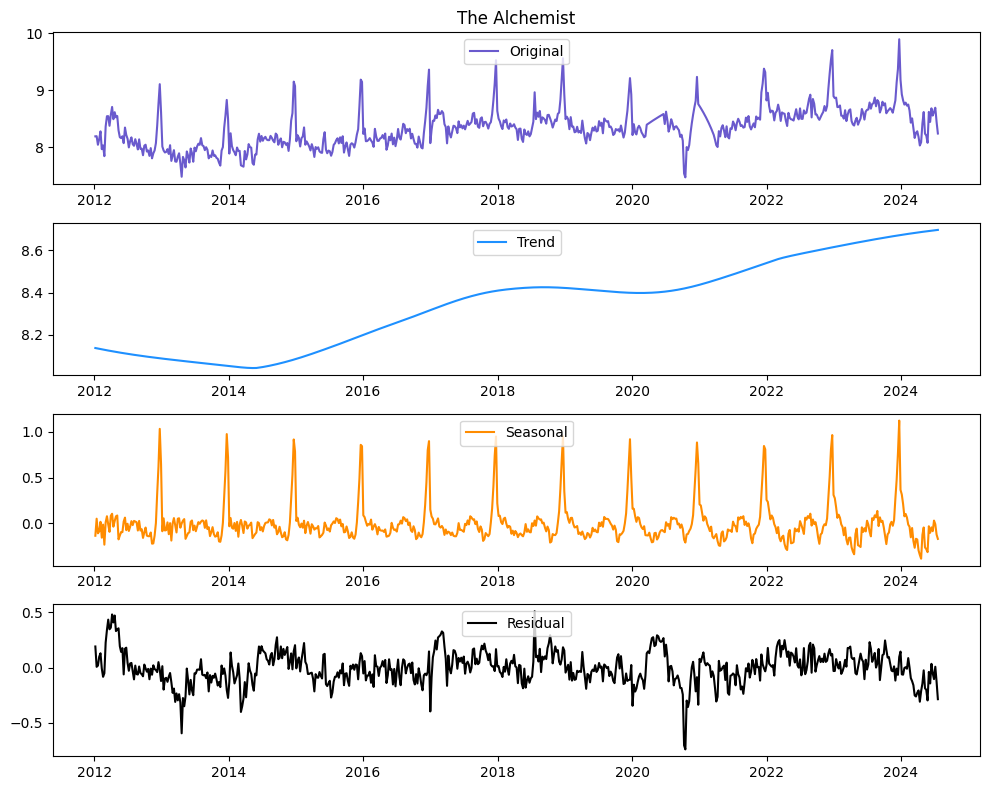

In [ ]:
_, alchemist_rough_interpolation_transformed_seasonal_component, alchemist_rough_interpolation_transformed_trend_component = stl_decomposer(alchemist_rough_interpolation_transformed)

The STL models with the appropriate transformations have worked well and decomposed the time series into its constituent elements. It should also be noted that these components relate to the data in the transformed space, not the original space. The inverse must be applied to visualise the trend in the original data space.

In [ ]:
hungry_catterpillar_rough_interpolation_trend_component = inv_boxcox(hungry_caterpillar_rough_interpolation_transformed_trend_component, hungry_caterpillar_lambda)
hungry_catterpillar_rough_interpolation_seasonal_component = inv_boxcox(hungry_caterpillar_rough_interpolation_transformed_seasonal_component, hungry_caterpillar_lambda)

alchemist_rough_interpolation_trend_component = np.exp(alchemist_rough_interpolation_transformed_trend_component)
alchemist_rough_interpolation_seasonal_component = np.exp(alchemist_rough_interpolation_transformed_seasonal_component)

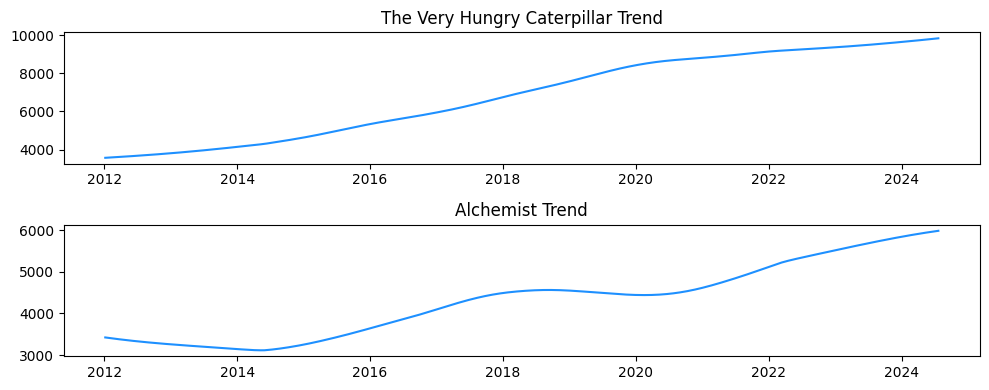

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharey=True)

axes[0].set_title("The Very Hungry Caterpillar Trend")
axes[0].plot(hungry_catterpillar_rough_interpolation_trend_component, color="dodgerblue")

axes[1].set_title("Alchemist Trend")
axes[1].plot(alchemist_rough_interpolation_trend_component, color="dodgerblue")

plt.tight_layout()

The inverse transformation changes the scale of the trend components, but it does not change their shape.

The Very Hungry Caterpillar shows a clear positive trend, indicating it is non-stationary. The Alchemist shows a "stepping up" trend and it is hard to determine stationarity from this due to the dips/plateaus that exist.

Looking back to the decomposition plots, some significant residuals are still seen around the missing period values, so a more advanced imputation technique will be attempted.

This involves subtracting the seasonal component of this rough fit from the original time series with NaN values. Since NaN values are present, as seasonality is removed from all other data points, only the trend and residual contributions remain.

Fitting a linear interpolation on this, then adding the seasonal component back, should result in a more realistic approximation for the missing data.

The missing values are being treated as anomalies and being imputed to ensure subsequent models have the best chance of capturing as much information as possible.

## STL Imputation

In [ ]:
def stl_impute(seasonal_stl_component, transformed_data): #note transformed_data has to be the original dataframe with NaNs after transformation
    #in transformed box cox space
    deseasonalized = transformed_data - seasonal_stl_component

    deseasonalized_imputed = deseasonalized.interpolate(method='linear')

    imputed_data = deseasonalized_imputed + seasonal_stl_component

    return imputed_data

In [ ]:
hungry_caterpillar_nan_transformed = boxcox(hungry_caterpillar.replace(0, np.nan), hungry_caterpillar_lambda)

alchemist_nan_transformed = log_data(alchemist.replace(0, np.nan))

In [ ]:
hungry_caterpillar_imputed_transformed = stl_impute(hungry_caterpillar_rough_interpolation_transformed_seasonal_component, hungry_caterpillar_nan_transformed)
hungry_caterpillar_imputed = inv_boxcox(hungry_caterpillar_imputed_transformed, hungry_caterpillar_lambda)

alchemist_imputed_transformed = stl_impute(alchemist_rough_interpolation_transformed_seasonal_component, alchemist_nan_transformed)
alchemist_imputed = np.exp(alchemist_imputed_transformed)

4342.794865504616


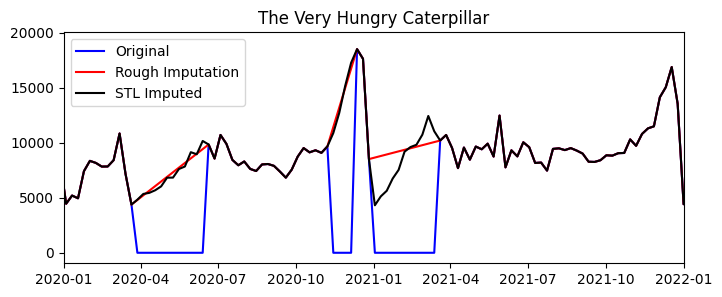

In [ ]:
plt.figure(figsize=(8, 3))
plt.title(hungry_caterpillar_rough_interpolation.name)
plt.plot(hungry_caterpillar, label='Original', color='blue')
plt.plot(hungry_caterpillar_rough_interpolation, label='Rough Imputation', color='red')
plt.plot(hungry_caterpillar_imputed, label='STL Imputed', color='black')
plt.legend(loc=2)
plt.xlim(dt.datetime(2020, 1, 1), dt.datetime(2022, 1, 1))

print(max(abs(hungry_caterpillar_rough_interpolation[:] - hungry_caterpillar_imputed[:])))

1984.5106098186388


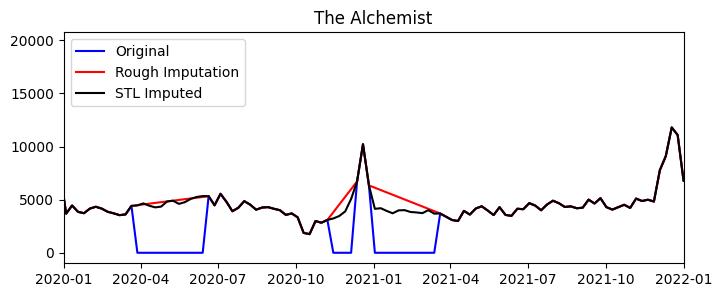

In [ ]:
plt.figure(figsize=(8, 3))
plt.title(alchemist_rough_interpolation.name)
plt.plot(alchemist, label='Original', color='blue')
plt.plot(alchemist_rough_interpolation, label='Rough Imputation', color='red')
plt.plot(alchemist_imputed, label='STL Imputed', color='black')
plt.legend(loc=2)
plt.xlim(dt.datetime(2020, 1, 1), dt.datetime(2022, 1, 1))

print(max(abs(alchemist_rough_interpolation[:] - alchemist_imputed[:])))

When the various datasets are plotted, the original with zeros for missing periods, roughly linearly imputed, and STL imputed, it can be seen that there are drastic differences.

The time series lines are plotted atop each other, so it is clear that the datasets hold the same values everywhere except the missing periods, as expected and wanted. These plots zoom into the missing value periods, but it has separately been validated it holds across the whole range of available data.

In the periods which relate to missing values around COVID, the blue line drops to zero. The red line is the simple linear interpolation, connecting the available points either side of the missing period.

The STL version builds on this to estimate values which align with the seasonal component that was found.

In The Very Hungry Caterpillar plot, this means that the characteristic trough and subsequent smaller peak after the main seasonal peak is retained, instead of being missed.

In The Alchemist plot, this means that the seasonal peak is narrower, as expected from other peaks, instead of being broadened by the linear interpolation forced from missing data.

The value of this approach is that it imputes estimated values that are likely given the overall trend, meaning that subsequent forecasting models can focus on learning the actual trends instead of trying to explain the anomalous missing data.

As such, the synthetically generated STL imputed data will be used going forwards.

## ACF/PACF

In [ ]:
def plot_acf_pacf(data, lag = 60, title=None):
  fig, axes = plt.subplots(1, 2, figsize=(14, 4))

  if title is not None:
    fig.suptitle(title, fontsize=16)

  plot_acf(data, ax=axes[0], lags = lag, title="Autocorrelation (ACF)")
  axes[0].set_xlabel("Lag")
  axes[0].set_ylabel("Correlation")
  axes[0].axvline(x=52, color="red", linestyle="--", alpha=0.7, label="Lag 52")
  axes[0].legend(loc = "upper right")

  plot_pacf(data, ax=axes[1], lags = lag, title="Partial ACF (PACF)")
  axes[1].set_xlabel("Lag")
  axes[1].set_ylabel("Partial Correlation")
  axes[1].axvline(x=52, color="red", linestyle="--", alpha=0.7, label="Lag 52")
  axes[1].legend(loc = "upper right")

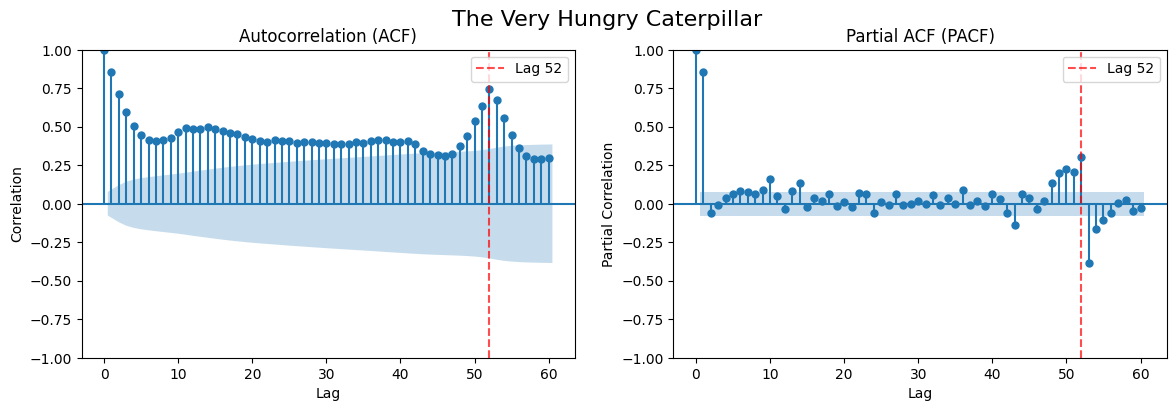

In [ ]:
plot_acf_pacf(hungry_caterpillar_imputed, title="The Very Hungry Caterpillar")

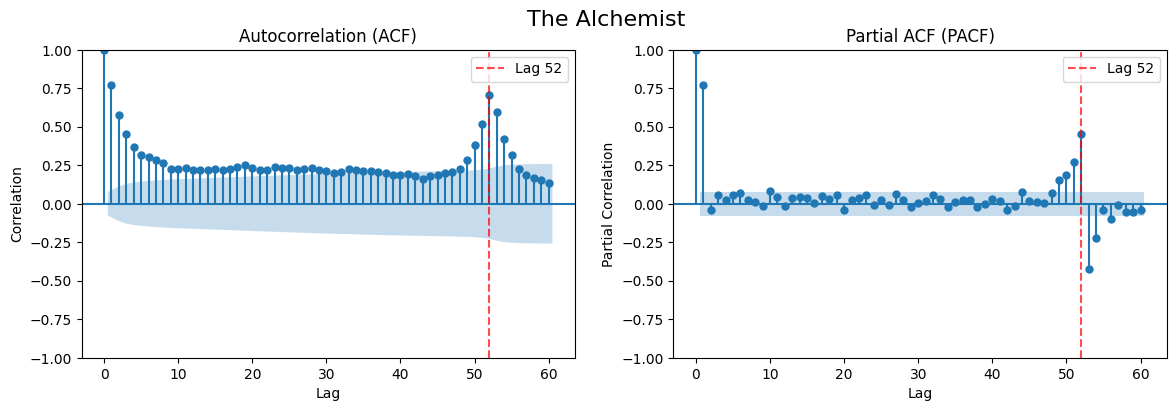

In [ ]:
plot_acf_pacf(alchemist_imputed, title="The Alchemist")

The ACF and PACF plots reveal similar information about both series.

Both ACFs decay slowly, only dropping into the insignificance region around the 30-40 week mark. This suggests they exhibit non-stationary character which should be further explored.

The ACF plots of both books also reveal a sharp peak centering around a lag of 52, i.e. 1 year, confirming the suspicion of annual seasonality in the data. This is also seen in the PACF plots, showing the sharp oscillating spikes between positive and negative partial correlations at the 52 week mark.

Moreover, the PACF of both books shows strong lag 1 partial correlation and quickly drops to the insignificance region, indicating that the value at a given week is highly dependent on the prior.

## ADF Stationarity

In [ ]:
#renaming series names from value to the book name
hungry_caterpillar_imputed.name = "The Very Hungry Caterpillar"
alchemist_imputed.name = "The Alchemist"

In [ ]:
def adf_test(data):
  adf_result = adfuller(data)
  print(f"{data.name} Results:")
  print(f"p-value: {adf_result[1]}")

In [ ]:
adf_test(hungry_caterpillar_imputed)

The Very Hungry Caterpillar Results:
p-value: 0.11028979351630891


In [ ]:
adf_test(alchemist_imputed)

The Alchemist Results:
p-value: 1.846043514095079e-15


The ADF test has a null hypothesis that the time series has a unit root, therefore making it non-stationary.

The Very Hungry Caterpillar has a large p-value, so there is not enough evidence to reject the null hypothesis, so we can conclude that this time series is non-stationary. This aligns with the clear trend component seen prior.

Conversely, The Alchemist shows a small p-value with enough evidence to reject the null hypothesis, indicating that this is a stationary time series. This seems like a somewhat surprising result since the trend component of The Alchemist seems to increase stepwise. It may be that the plateaus/dips resist the unit root character that the ADF test looks for. However, when looking at the orignal plot of The Alchemist across the entire available data period, this period from 2012 onwards was the "flatter" part that was expected to be stationary.

# Single Architecture Models

## Helper Functions

In [ ]:
def split_train_test_data(data, no_test_weeks):
  train_data = data.iloc[:-no_test_weeks]
  test_data = data.iloc[-no_test_weeks:]
  print(len(test_data))
  return train_data, test_data

In [ ]:
def plot_prediction_master(train_data, test_data, predictions, title_name, method_name, forecast_int):

  plt.rcParams.update({'font.size': 16})


  if hasattr(train_data.index, 'to_timestamp'):
        train_data = train_data.copy()
        train_data.index = train_data.index.to_timestamp()
  if hasattr(test_data.index, 'to_timestamp'):
        test_data = test_data.copy()
        test_data.index = test_data.index.to_timestamp()
  if hasattr(predictions.index, 'to_timestamp'):
        predictions = predictions.copy()
        predictions.index = predictions.index.to_timestamp()


  if forecast_int is not None:
        if isinstance(forecast_int, pd.DataFrame):
            f_lower = forecast_int.iloc[:, 0].astype(float).to_numpy()
            f_upper = forecast_int.iloc[:, 1].astype(float).to_numpy()
        else:
            f_arr = np.asarray(forecast_int, dtype=float)
            f_lower = f_arr[:, 0]
            f_upper = f_arr[:, 1]

  mae = mean_absolute_error(test_data, predictions)
  mape = mean_absolute_percentage_error(test_data, predictions)

  residuals = test_data - predictions

  fig = plt.figure(figsize=(15, 12))
  gs = fig.add_gridspec(3, 2)

    # Create a list of axes to enable the axes[0], axes[1]... syntax
  axes = [
        fig.add_subplot(gs[0, :]),  # axes[0]: Top row, spans both columns
        fig.add_subplot(gs[1, 0]),  # axes[1]: Middle row, left
        fig.add_subplot(gs[1, 1]),  # axes[2]: Middle row, right
        fig.add_subplot(gs[2, 0]),  # axes[3]: Bottom row, left
        fig.add_subplot(gs[2, 1])   # axes[4]: Bottom row, right
    ]


  split_date = test_data.index[0] #where training data stops/test data starts
  x_min = split_date - pd.DateOffset(years=2) #plot 2 years before split date
  x_max = test_data.index[-1] #plot up to end of prediction period

  if forecast_int is not None:
      # Convert DataFrame or array-like to a NumPy array for uniform 2D indexing
      f_vals = forecast_int.values if isinstance(forecast_int, pd.DataFrame) else np.asarray(forecast_int)
      axes[0].fill_between(test_data.index,
                           f_lower,  # Lower bound
                           f_upper,  # Upper bound
                           color='darkgrey', alpha=.7, label='Confidence Interval')

  axes[0].plot(train_data.index, train_data.values, color='black')
  axes[0].plot(test_data.index, test_data.values, label='Actual Data', color='black')
  axes[0].axvline(x=split_date, color='red', linestyle='--', label='Train/Test Split')
  axes[0].plot(predictions.index, predictions.values, label='Forecast', color='dodgerblue')

  axes[0].set_title(f"{title_name} {method_name} - MAE: {mae:.2f}, MAPE: {mape:.3f}")
  axes[0].legend(loc='upper left')
  axes[0].set_xlim(x_min, x_max)

  axes[1].plot(residuals, color='black')
  axes[1].axhline(0, color='red', linestyle='--')
  axes[1].set_title("Residuals")
  axes[1].tick_params(axis='x', rotation=45)

  axes[2].hist(residuals, bins=20, edgecolor='black')
  axes[2].set_title("Residual Histogram")


  plot_acf(residuals, ax=axes[3], title="Residual ACF")

  plot_pacf(residuals, ax=axes[4], title="Residual PACF")

  plt.tight_layout()
  plt.show()

  return mae, mape

## Auto ARIMA

In [ ]:
def run_auto_arima(data_train, season_length):
  model = auto_arima(y=data_train, X=None, #training data and any exogeneous variables
    start_p=0, max_p=3, start_q=0, max_q=3, d=None, max_d=2, #non seasonal parameters
    start_P=0, max_P=1, start_Q=0, max_Q=1, D=1, max_D=1, #seasonal parameters, settting seasonal differencing, D, to 1 since seasonality known to repeat yearly
    m=season_length, #season length wrt sampling frequency e.g. weekly data with yearly seasonality is 52
    seasonal=True, #whether seasonal ARIMA model should be fit
    information_criterion='bic', #scoring metric to be used, common ones include aic and bic
    stepwise=True,
    trace=True)
  print("Done!")
  return model

In [ ]:
def best_arima_pred(model, data_test):
  n_periods = len(data_test)
  predictions, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)
  print(model.summary())
  return predictions, conf_int

### Hungry Caterpillar

In [ ]:
hungry_caterpillar_train_32, hungry_caterpillar_test_32 = split_train_test_data(hungry_caterpillar_imputed, 32)

32


In [ ]:
hungry_caterpillar_arima_model = run_auto_arima(hungry_caterpillar_train_32, 52)

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,1,0)[52] intercept   : BIC=10116.526, Time=0.39 sec
 ARIMA(1,0,0)(1,1,0)[52] intercept   : BIC=9664.342, Time=33.63 sec
 ARIMA(0,0,1)(0,1,1)[52] intercept   : BIC=9786.683, Time=14.98 sec
 ARIMA(0,0,0)(0,1,0)[52]             : BIC=10166.217, Time=0.33 sec
 ARIMA(1,0,0)(0,1,0)[52] intercept   : BIC=9722.999, Time=1.85 sec
 ARIMA(1,0,0)(1,1,1)[52] intercept   : BIC=9673.984, Time=11.33 sec
 ARIMA(1,0,0)(0,1,1)[52] intercept   : BIC=9663.875, Time=15.68 sec
 ARIMA(0,0,0)(0,1,1)[52] intercept   : BIC=9993.570, Time=19.26 sec
 ARIMA(2,0,0)(0,1,1)[52] intercept   : BIC=9665.576, Time=17.81 sec
 ARIMA(1,0,1)(0,1,1)[52] intercept   : BIC=9664.637, Time=21.58 sec
 ARIMA(2,0,1)(0,1,1)[52] intercept   : BIC=9673.369, Time=18.46 sec
 ARIMA(1,0,0)(0,1,1)[52]             : BIC=9683.396, Time=17.70 sec

Best model:  ARIMA(1,0,0)(0,1,1)[52] intercept
Total fit time: 173.035 seconds
Done!


In [ ]:
hc_arima_pred, hc_arima_conf_int = best_arima_pred(hungry_caterpillar_arima_model, hungry_caterpillar_test_32)

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  623
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 52)   Log Likelihood               -4819.243
Date:                              Mon, 24 Aug 2026   AIC                           9646.485
Time:                                      06:45:48   BIC                           9663.875
Sample:                                  01-07-2012   HQIC                          9653.270
                                       - 12-09-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    192.9561     41.353      4.666      0.000     111.905     274.007
ar.L1          0.67

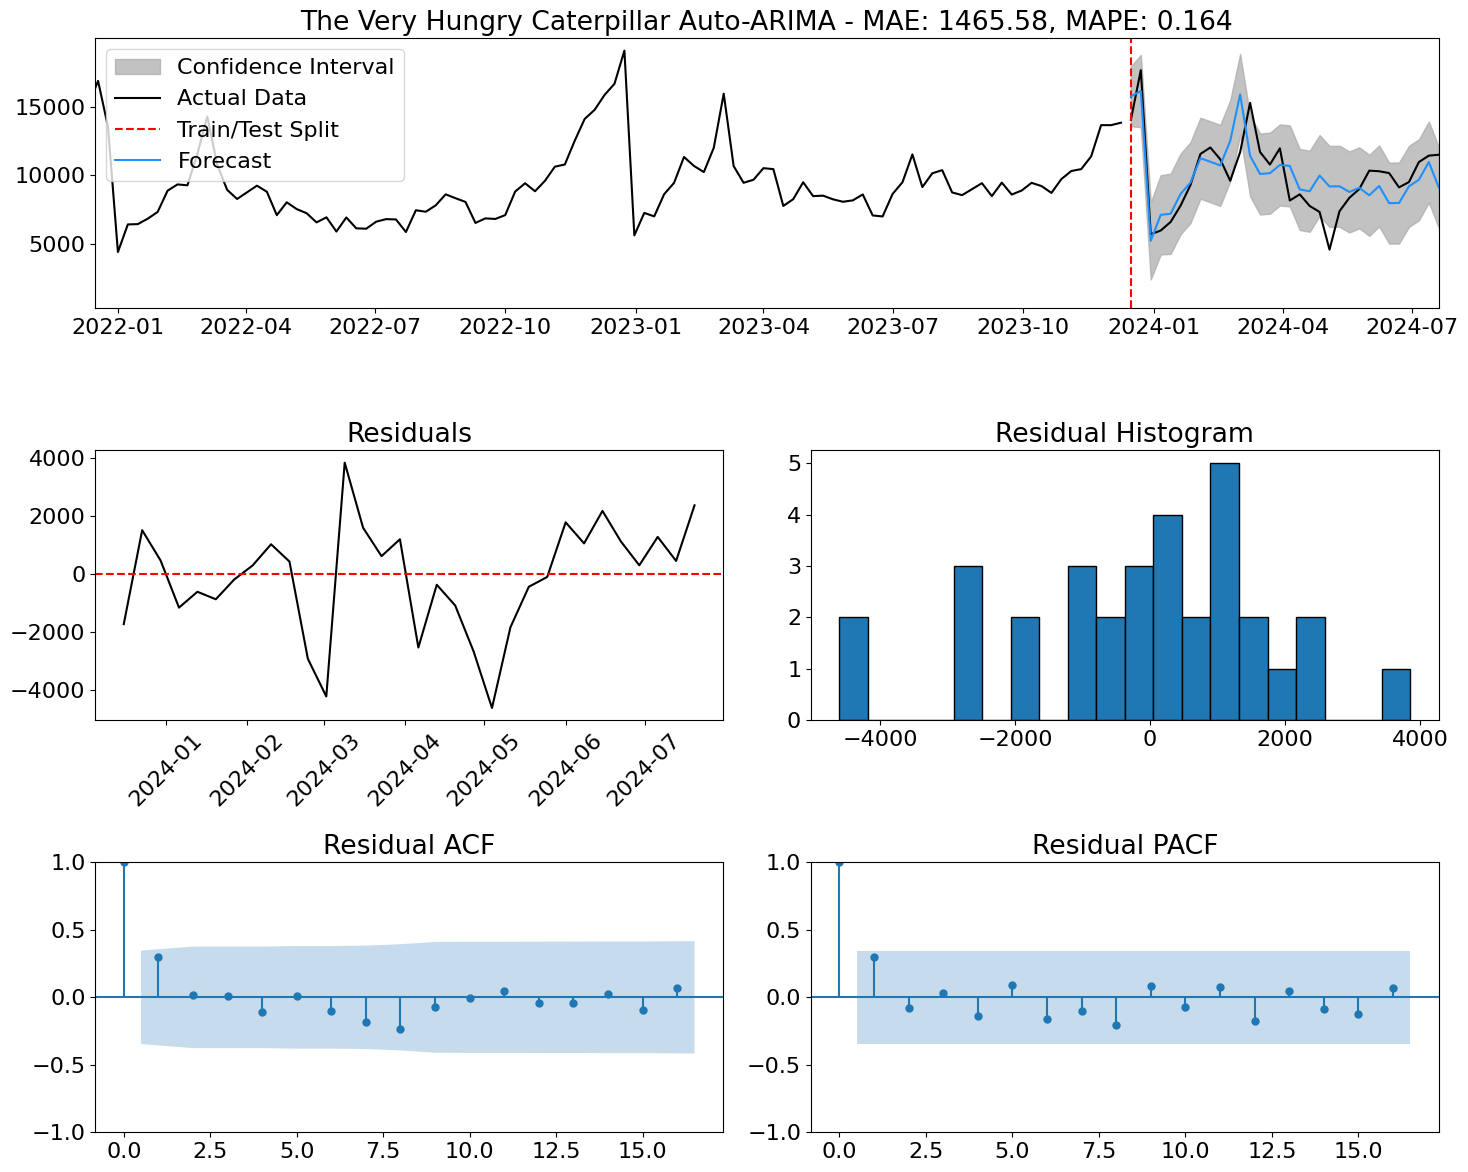

(1465.5806721181043, 0.16386091284729096)

In [ ]:
plot_prediction_master(hungry_caterpillar_train_32, hungry_caterpillar_test_32, hc_arima_pred, "The Very Hungry Caterpillar", "Auto-ARIMA", hc_arima_conf_int)

The Auto-ARIMA model for The Very Hungry Caterpillar is quite good. It accurately captures the immediate dip and subsequent rise around the train-test split. Confidence intervals include the majority of the actual data with only a few small parts dropping outside of this region.

The residuals are centred around a mean of zero with a rough normal distribution, indicating the model has successfully captured most information that is available.

Moreover, the ACF/PACF show the residuals show no significant lag relationships.

### Alchemist

In [ ]:
alchemist_train_32, alchemist_test_32 = split_train_test_data(alchemist_imputed, 32)

32


In [ ]:
alchemist_arima_model = run_auto_arima(alchemist_train_32, 52)

Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,1,0)[52]             : BIC=9252.018, Time=2.35 sec
 ARIMA(1,1,0)(1,1,0)[52]             : BIC=9150.425, Time=18.63 sec
 ARIMA(0,1,1)(0,1,1)[52]             : BIC=9097.823, Time=17.24 sec
 ARIMA(0,1,1)(0,1,0)[52]             : BIC=9136.034, Time=0.69 sec
 ARIMA(0,1,1)(1,1,1)[52]             : BIC=9104.049, Time=27.46 sec
 ARIMA(0,1,1)(1,1,0)[52]             : BIC=9101.154, Time=16.16 sec
 ARIMA(0,1,0)(0,1,1)[52]             : BIC=9224.859, Time=32.22 sec
 ARIMA(1,1,1)(0,1,1)[52]             : BIC=9097.149, Time=26.51 sec
 ARIMA(1,1,1)(0,1,0)[52]             : BIC=9133.326, Time=1.05 sec
 ARIMA(1,1,1)(1,1,1)[52]             : BIC=9103.437, Time=41.87 sec
 ARIMA(1,1,1)(1,1,0)[52]             : BIC=9100.606, Time=23.39 sec
 ARIMA(1,1,0)(0,1,1)[52]             : BIC=9149.893, Time=8.43 sec
 ARIMA(2,1,1)(0,1,1)[52]             : BIC=9103.104, Time=42.30 sec
 ARIMA(1,1,2)(0,1,1)[52]             : BIC=inf, Time=49.52 sec
 ARIMA(0,1,2)(

In [ ]:
alch_arima_pred, alch_arima_conf_int = best_arima_pred(alchemist_arima_model, alchemist_test_32)

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  623
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 52)   Log Likelihood               -4535.883
Date:                            Mon, 24 Aug 2026   AIC                           9079.767
Time:                                    06:53:19   BIC                           9097.149
Sample:                                01-07-2012   HQIC                          9086.549
                                     - 12-09-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2069      0.054      3.833      0.000       0.101       0.313
ma.L1         -0.7262      0.043   

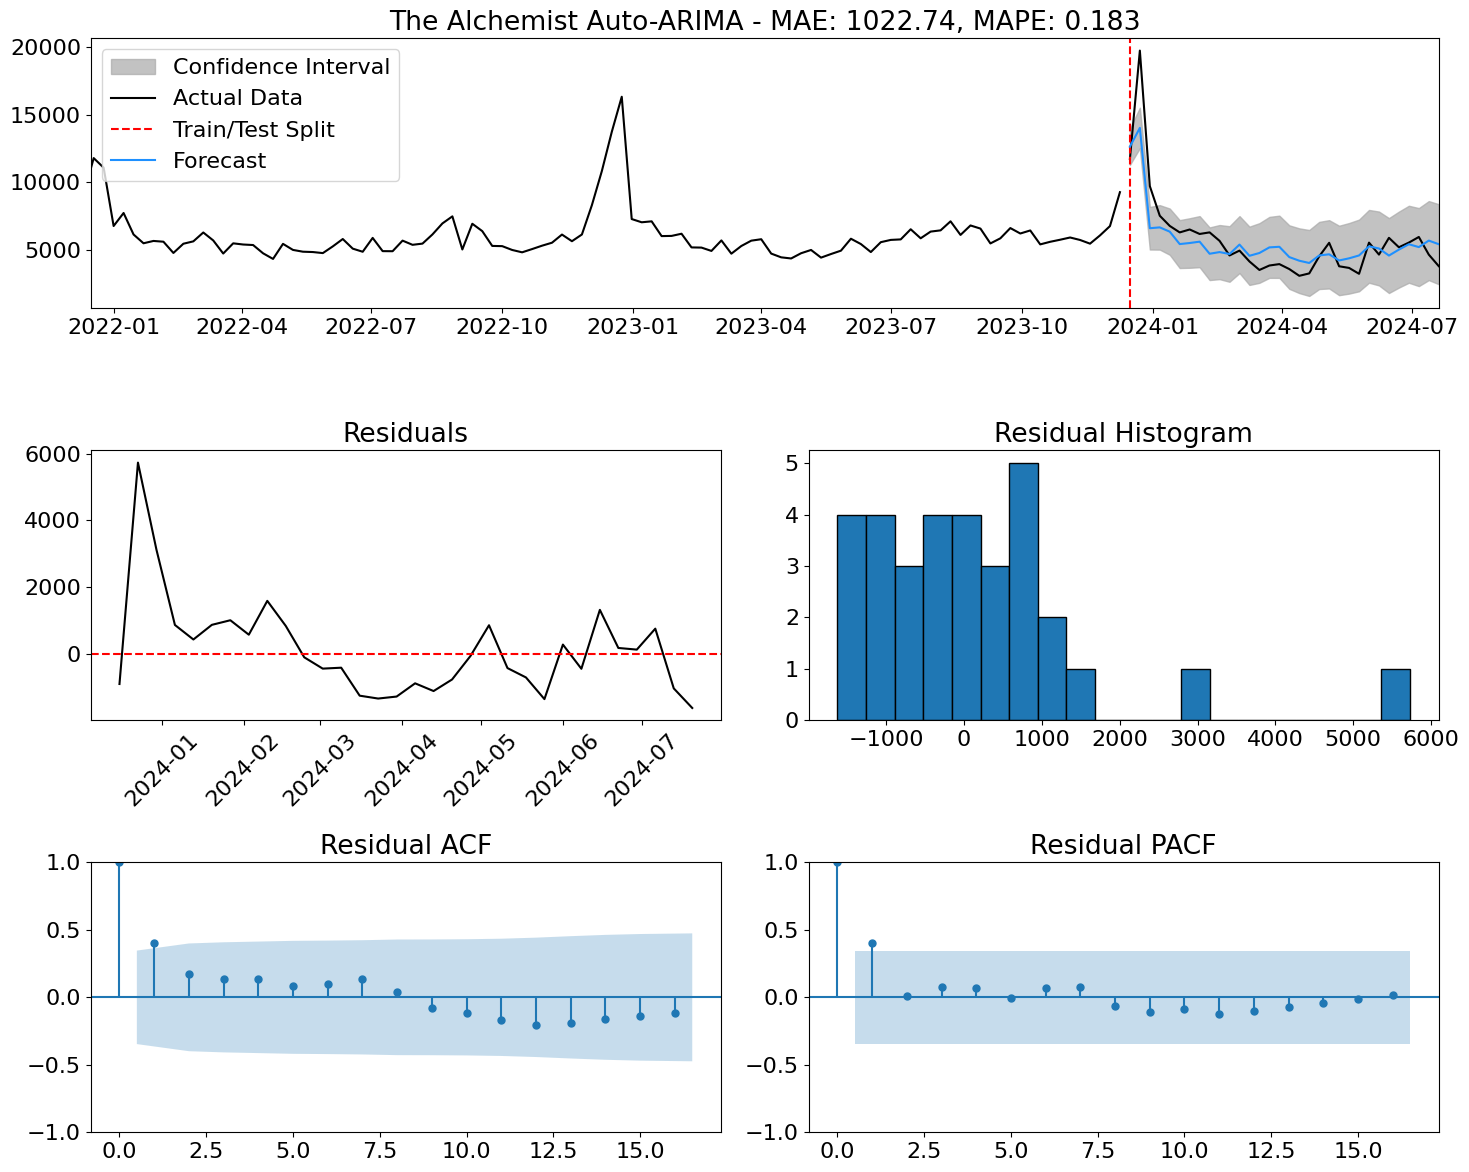

(1022.7369692255595, 0.18324867203032746)

In [ ]:
plot_prediction_master(alchemist_train_32, alchemist_test_32, alch_arima_pred, "The Alchemist", "Auto-ARIMA", alch_arima_conf_int)

Similarly to The Very Hungry Caterpillar, the Auto-ARIMA model worked well for The Alchemist.

The confidence region contains the actual data nearly the whole way through too which is good for the forecast.

However, residual behaviour is worse than that seen for The Very Hungry Caterpillar. Whilst mostly centered around the mean, there are some significant residuals which dwarf the rest. The distribution is also more uniform around zero than normally distributed.

The ACF/PACF show lag-1 is statistically significant, which may explain the residual behaviour identified above.

This aligns with comparison of the MAPE between the books, with The Very Hungry Caterpillar Auto-ARIMA model slightly outperforming the equivalent for The Alchemist.

## XGBoost

Machine learning models may be able to pick up more nuanced relationships in underlying data, however they do not understand "time" and treat every record in tabular data independently.

Time series data has temporal order baked into it, so it needs to be transformed into some tabular format which enables ML models to interpret and understand the relationships.

A common way to do this is to engineer input features which contain lag information through a preceding sliding window.

A tabular form of time series data would have the same number of columns as the window length + 1. Each input feature corresponds to the lagged values of the target, one through the window length, with an additional column for the target variable.

For example, with a window length of 3, the table would have 4 columns (those being lag-3, lag-2, lag-1, for the input features plus the target).

The first record in this table would take the first through fourth values of the time series, the second record would take the second through fifth values and so on. This allows machine learning models to learn how prior, lagged values, impact the target variable.

A grid search of window lengths can be tested to see which performs best.

In [ ]:
param_grid = {"forecast__window_length": [4, 8, 13, 26, 52]} #could expand to do more hyperparam but not done here for computational expense

In [ ]:
def xgboost_predictor(data, test_period, param_grid, transform_method, seasonality = 52):

  data = data.to_period("W-SAT")

  data_train, data_test = split_train_test_data(data, test_period)

  print(test_period)
  print(len(data_test))

  variance_transformers = {"box_cox": BoxCoxTransformer(),
                           "log": LogTransformer()}

  xgb_model = XGBRegressor(device="cuda", tree_method="hist")

  predictor = TransformedTargetForecaster([("variance_transform", variance_transformers[transform_method]),
                                           ("deseasonalize", Deseasonalizer(model="additive", sp=seasonality)),
                                           ("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=1))),
                                           ("forecast", make_reduction(xgb_model, window_length=6, strategy="recursive"))])

  cv = ExpandingWindowSplitter(initial_window=int(len(data_train) * 0.7)) #define expanding cross validation

  gscv = ForecastingGridSearchCV(predictor, strategy="refit", cv=cv, param_grid=param_grid, scoring=MeanAbsolutePercentageError(symmetric=True), backend="loky", backend_params={"n_jobs":-1}, error_score="raise") #define the grid search, use predictor blueprint (which defines XGBoost),

  gscv.fit(data_train) #grid search XGBoost models to get best model

  print(f"Best parameters: {gscv.best_params_}") #display best parameters found by grid search e.g. window length

  future_horizon = np.arange(test_period) + 1 #create an array between 1 and test period e.g. 1, 2, 3, ..., test_period (+1 since .arrange() starts at zero)


  best_model = gscv.best_forecaster_
  probabilistic_model = ConformalIntervals(best_model, initial_window = 104)
  probabilistic_model.fit(data_train)

  raw_intervals = probabilistic_model.predict_interval(fh=future_horizon, coverage=0.95) #note that confidence intervals aren't natively outputted my xgboost so trying to create some with predict_interval
  forecast_int = pd.DataFrame({"lower": raw_intervals.xs('lower', axis=1, level=-1).iloc[:, 0].values,
                               "upper": raw_intervals.xs('upper', axis=1, level=-1).iloc[:, 0].values}, index=data_test.index)




  prediction = gscv.predict(fh=future_horizon) #use best model, stored in gscv, to predict the next 1 - test_period steps, returns a series of length test_period
  prediction.index = data_test.index #set correct index

  return data_train, data_test, prediction, forecast_int

### Hungry Caterpillar

In [ ]:
xgb_hungry_caterpillar_train, xgb_hungry_caterpillar_test, xgb_hungry_caterpillar_pred, xgb_hungry_caterpillar_forecast_int = xgboost_predictor(hungry_caterpillar_imputed, 32, param_grid, "box_cox")

32
32
32
Best parameters: {'forecast__window_length': 4}


/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [06:59:16] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


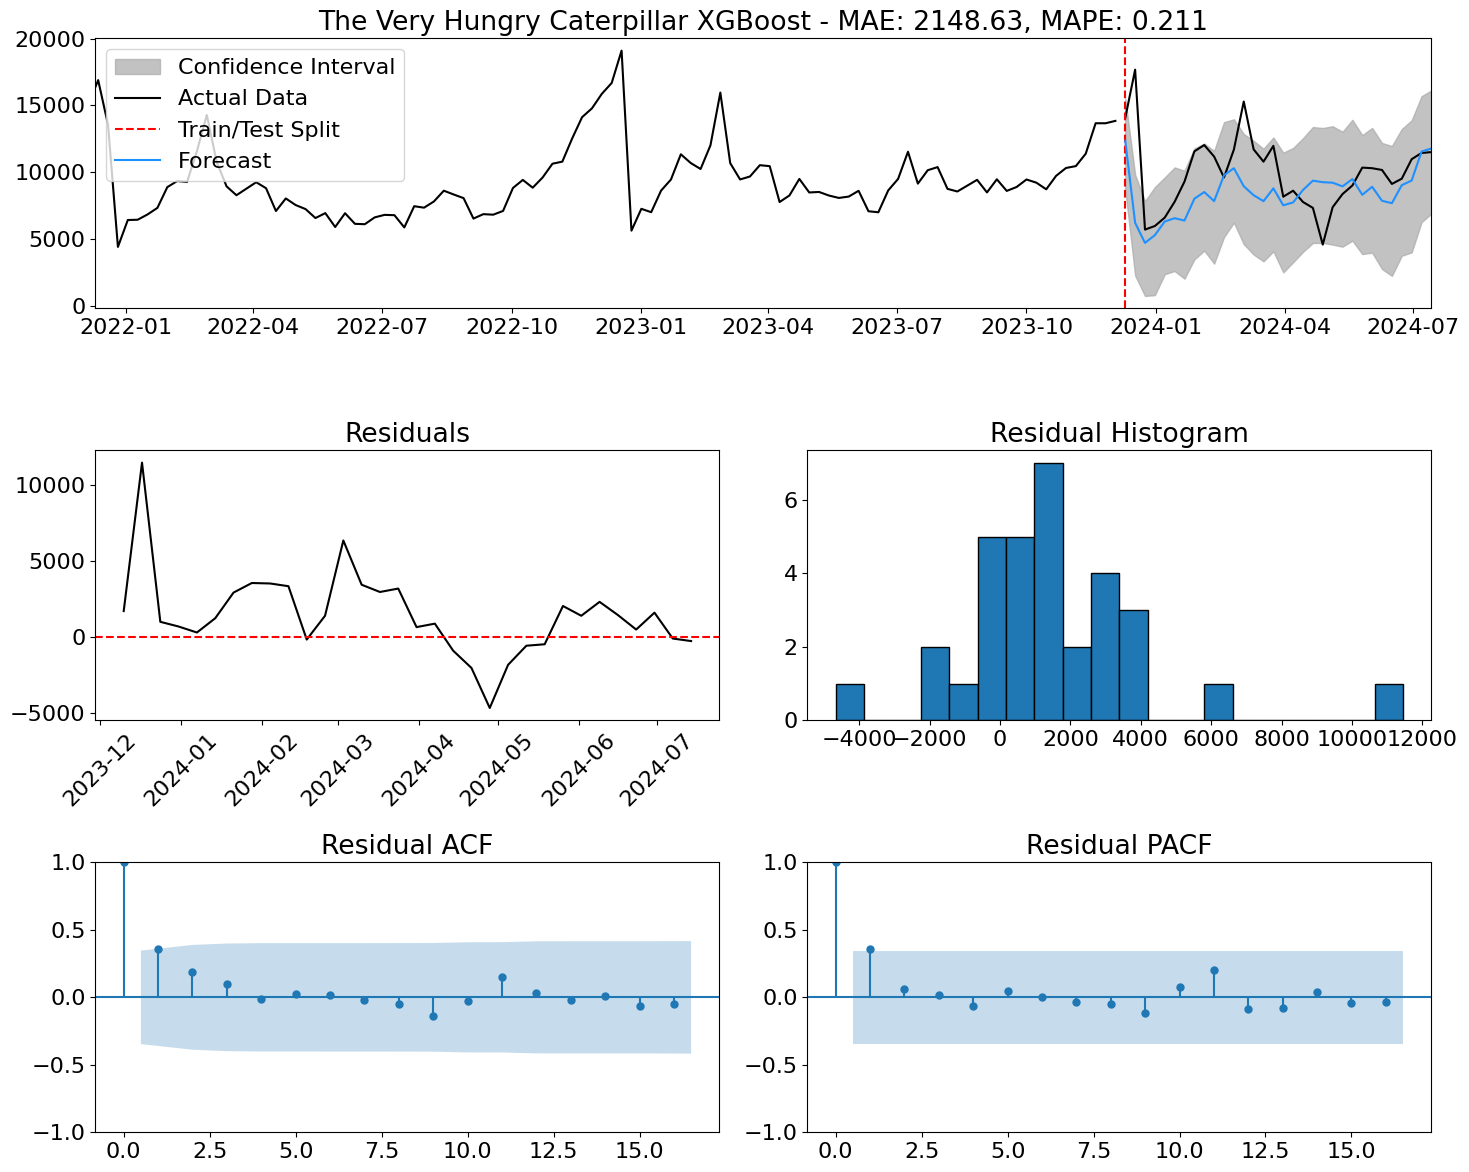

(2148.631774313336, 0.2112271262451526)

In [ ]:
plot_prediction_master(xgb_hungry_caterpillar_train, xgb_hungry_caterpillar_test, xgb_hungry_caterpillar_pred, "The Very Hungry Caterpillar", "XGBoost", xgb_hungry_caterpillar_forecast_int)

The XGBoost model performs moderately. The general shape of the prediction is similar to the actual data, but it misses the characteristic next spike after the main seasonal one. The MAPE is also slightly worse than the ARIMA model, which makes sense given residuals aren't as centered around the mean and the ACF/PACF plots show lag-1 might be statistically significant.

### Alchemist

In [ ]:
xgb_alchemist_train, xgb_alchemist_test, xgb_alchemist_pred, xgb_alchemist_forecast_int = xgboost_predictor(alchemist_imputed, 32, param_grid, "log")

32
32
32
Best parameters: {'forecast__window_length': 4}


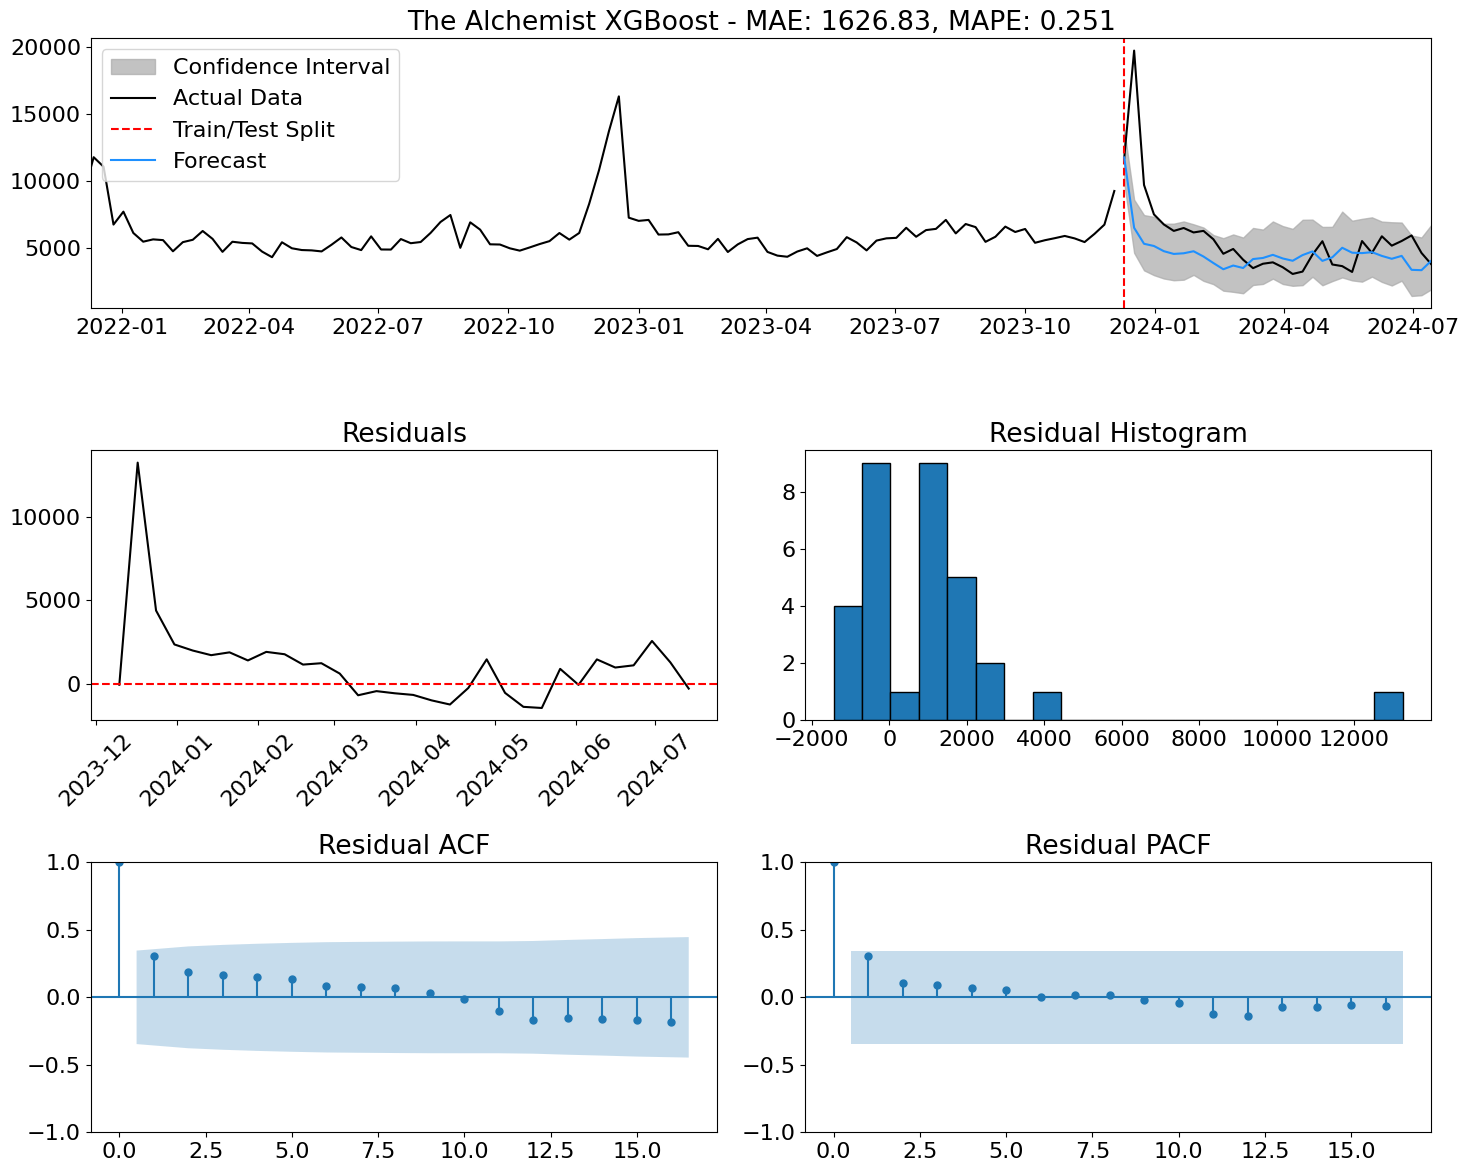

(1626.828340463838, 0.250740855138313)

In [ ]:
plot_prediction_master(xgb_alchemist_train, xgb_alchemist_test, xgb_alchemist_pred, "The Alchemist", "XGBoost", xgb_alchemist_forecast_int)

Similarly, XGBoost performed worse on The Alchemist then ARMIA performed. This lack of performance may be due to lack of hyperparameter tuning of the base model, since the only hyperparameter tuning done here is on the optimal window length. This is left as an extension for future work.

# LSTM Recurrent Neural Network

Similarly to XGBoost, LSTMs need time series data to be transformed into a 3D format to make predictions. This is done by splitting the one dimensional time series into many windows across the time series (lookback, input) to make a prediction of its future values (forecast, target).

For example, take the time series:
[1, 2, 3, 4, 5, 6, 7, 8, 9]

If we considered a lookback of 3 and a forecast of 2, our lookback windows would be:

[1, 2, 3], [2, 3, 4], [3, 4, 5], [4, 5, 6], [5, 6, 7]

With respective forecast windows of:

[4, 5], [5, 6], [6, 7], [7, 8], [8, 9]

The lookback windows are formatted in a 3D array format, looking similar to:
[[[1], [2], [3]], [[2], [3], [4]], [[3], [4], [5]], [[4], [5], [6]], [[5], [6], [7]]]
This is 3D since it needs 3 indicies to extract a single value (sample/window number, time step/lookback number, and the actual value)

In a similar manner, the respective forecast window is 2D as the target is an array of two values.

In [ ]:
def create_windows(data, lookback_length, forecast_length): #looks back at x values to forecast y future values
  lookback_windows = []
  forecast_windows = []

  for i in range(lookback_length, len(data) - forecast_length + 1): #starts at lookback since need at least that many values prior, goes up to last available index (total - what is trying to be forecast +1 for 0 start index)
      lookback_windows.append(data[i - lookback_length : i]) #fetches past chunks of length lookback increasing by 1 each time e.g. idx 1 2 3 4 then 2 3 4 5 then 3 4 5 6...
      forecast_windows.append(data[i: i + forecast_length].flatten()) #fetches future chunks of length forecast increasing by 1 each time e.g. 5 6 7 then 6 7 8 then 7 8 9...

  X = np.array(lookback_windows) #numpy array
  y = np.array(forecast_windows) #numpy array

  return X, y

In [ ]:
def lstm_data(data, lookback_period, test_forecast_period):
  data_train, data_test = split_train_test_data(data, test_forecast_period) #returns two pandas series

  scaler = MinMaxScaler(feature_range=(0, 1))
  train_scaled = scaler.fit_transform(data_train.values.reshape(-1, 1))

  X_train_scaled, y_train_scaled = create_windows(train_scaled, lookback_period, test_forecast_period)

  return X_train_scaled, y_train_scaled, data_train, train_scaled, scaler, data_test


In [ ]:
#define lstm blueprint
def tuned_model_blueprint(hp, lookback=52, forecast=32):
  """Defines the hyperparameter search space for Keras Tuner."""
  model = Sequential()

  # Tune the number of units in the first LSTM layer (52-week lookback)
  model.add(LSTM(hp.Int('input_unit', min_value=16, max_value=128, step=16),
                   return_sequences=True, input_shape=(lookback, 1)))

  # Tune the number of hidden LSTM layers and their units
  for i in range(hp.Int('n_layers', 1, 1)):
    model.add(LSTM(hp.Int(f'lstm_{i}_units', min_value=16, max_value=128, step=16),
                      return_sequences=True))

  # Final LSTM layer
  model.add(LSTM(hp.Int('layer_2_neurons', min_value=16, max_value=128, step=16)))

  # Tune dropout rate
  model.add(Dropout(hp.Float('Dropout_rate', min_value=0.0, max_value=0.5, step=0.1)))

  # Tune activation function of the output layer
  model.add(Dense(forecast, activation=hp.Choice('dense_activation', values=['relu', 'linear'], default='linear')))

  model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mse'])


  return model



In [ ]:
def run_hyperparameter_tuning(data, lookback_period, forecast_period):

  X_train_scaled, y_train_scaled, data_train, train_scaled, scaler, data_test = lstm_data(data, lookback_period, forecast_period)


  #initialise tuner
  tuner = RandomSearch(
        lambda hp: tuned_model_blueprint(hp, lookback = lookback_period, forecast = forecast_period),
        objective='val_mse', # Optimize based on validation data, not training data
        max_trials=15,
        executions_per_trial=1,
        overwrite=True # Clears previous tuning logs
        )

    # Abort a trial if the validation MSE doesn't improve for 5 consecutive epochs
  early_stop = EarlyStopping(monitor='val_mse', patience=15, restore_best_weights=True)

  tuner.search(
        x=X_train_scaled,
        y=y_train_scaled,
        epochs=150,           # Increased from 10 to allow sufficient learning time
        batch_size=32,
        validation_split=0.2, # Hold back 20% of data to test generalization, note this should take the final 20% of data so temporal order is preserved
        callbacks=[early_stop],
        verbose=0,
        shuffle=True)

  best_hp = tuner.get_best_hyperparameters()[0]

    # Build a fresh, untrained model using the winning architecture
  best_model = tuner.hypermodel.build(best_hp)

  best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
  best_epochs = best_trial.best_step + 1

  return best_model, best_epochs, X_train_scaled, y_train_scaled, data_train, train_scaled, scaler, data_test

In [ ]:
def run_best_model(best_model, best_epochs, X_train, y_train, train_scaled, scaler, data_test, lookback_period):



  best_model.fit(x=X_train,
        y=y_train,
        epochs=600,           # Increased from 10 to allow sufficient learning time
        batch_size=32,
        verbose=0,
        shuffle=True)

  print(f"{best_model.summary()}\n\n\n")

  last_available_input = train_scaled[-lookback_period:] #this will be the input to make a prediction, the last lookback_period items in training set

  last_available_input = last_available_input.reshape(-1, lookback_period, 1) #reshape into LSTM 3D form

  predictions_scaled = best_model.predict(last_available_input) #make predictions (scaled)

  predictions_scaled_reshape = predictions_scaled.reshape(-1, 1) #reshape predictions (scaled)

  predictions = scaler.inverse_transform(predictions_scaled_reshape) #inverse scaling on predictions

  predictions = pd.Series(predictions.flatten(), index=data_test.index)


  #CI via past result residuals

  train_preds_scaled = best_model.predict(X_train)

  # Calculate residuals (actual - predicted) in the scaled space
  residuals_scaled = y_train - train_preds_scaled

  # Calculate the standard deviation of residuals for each of the 32 forecast steps
  # This ensures the CI adjusts based on how error degrades further into the future
  std_scaled = np.std(residuals_scaled, axis=0).reshape(1, -1)

  # Calculate 95% bounds in scaled space
  lower_scaled = predictions_scaled - (1.96 * std_scaled)
  upper_scaled = predictions_scaled + (1.96 * std_scaled)

  # Inverse transform the bounds back to original sales values
  lower_inv = scaler.inverse_transform(lower_scaled.reshape(-1, 1)).flatten()
  upper_inv = scaler.inverse_transform(upper_scaled.reshape(-1, 1)).flatten()

  # Create the forecast_int DataFrame to match plot_prediction_master requirements
  forecast_int = pd.DataFrame({
        "lower": lower_inv,
        "upper": upper_inv}, index=data_test.index)



  return predictions, forecast_int

In [ ]:
lookback = 52
forecast = 32

### Hungry Caterpillar

In [ ]:
lstm_model_hc, lstm_model_epoch_hc, lstm_hc_X_train_scaled, lstm_hc_y_train_scaled, lstm_hc_data_train, lstm_hc_train_scaled, lstm_hc_scaler, lstm_hc_data_test = run_hyperparameter_tuning(hungry_caterpillar_imputed, lookback, forecast)

32


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_hc_pred, lstm_hc_conf = run_best_model(lstm_model_hc, lstm_model_epoch_hc, lstm_hc_X_train_scaled, lstm_hc_y_train_scaled, lstm_hc_train_scaled, lstm_hc_scaler, lstm_hc_data_test, lookback)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 52, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 52, 16)         │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 96)             │        43,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         3,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 367,010 (1.40 MB)

 Trainable params: 122,336 (477.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 244,674 (955.76 KB)

None



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


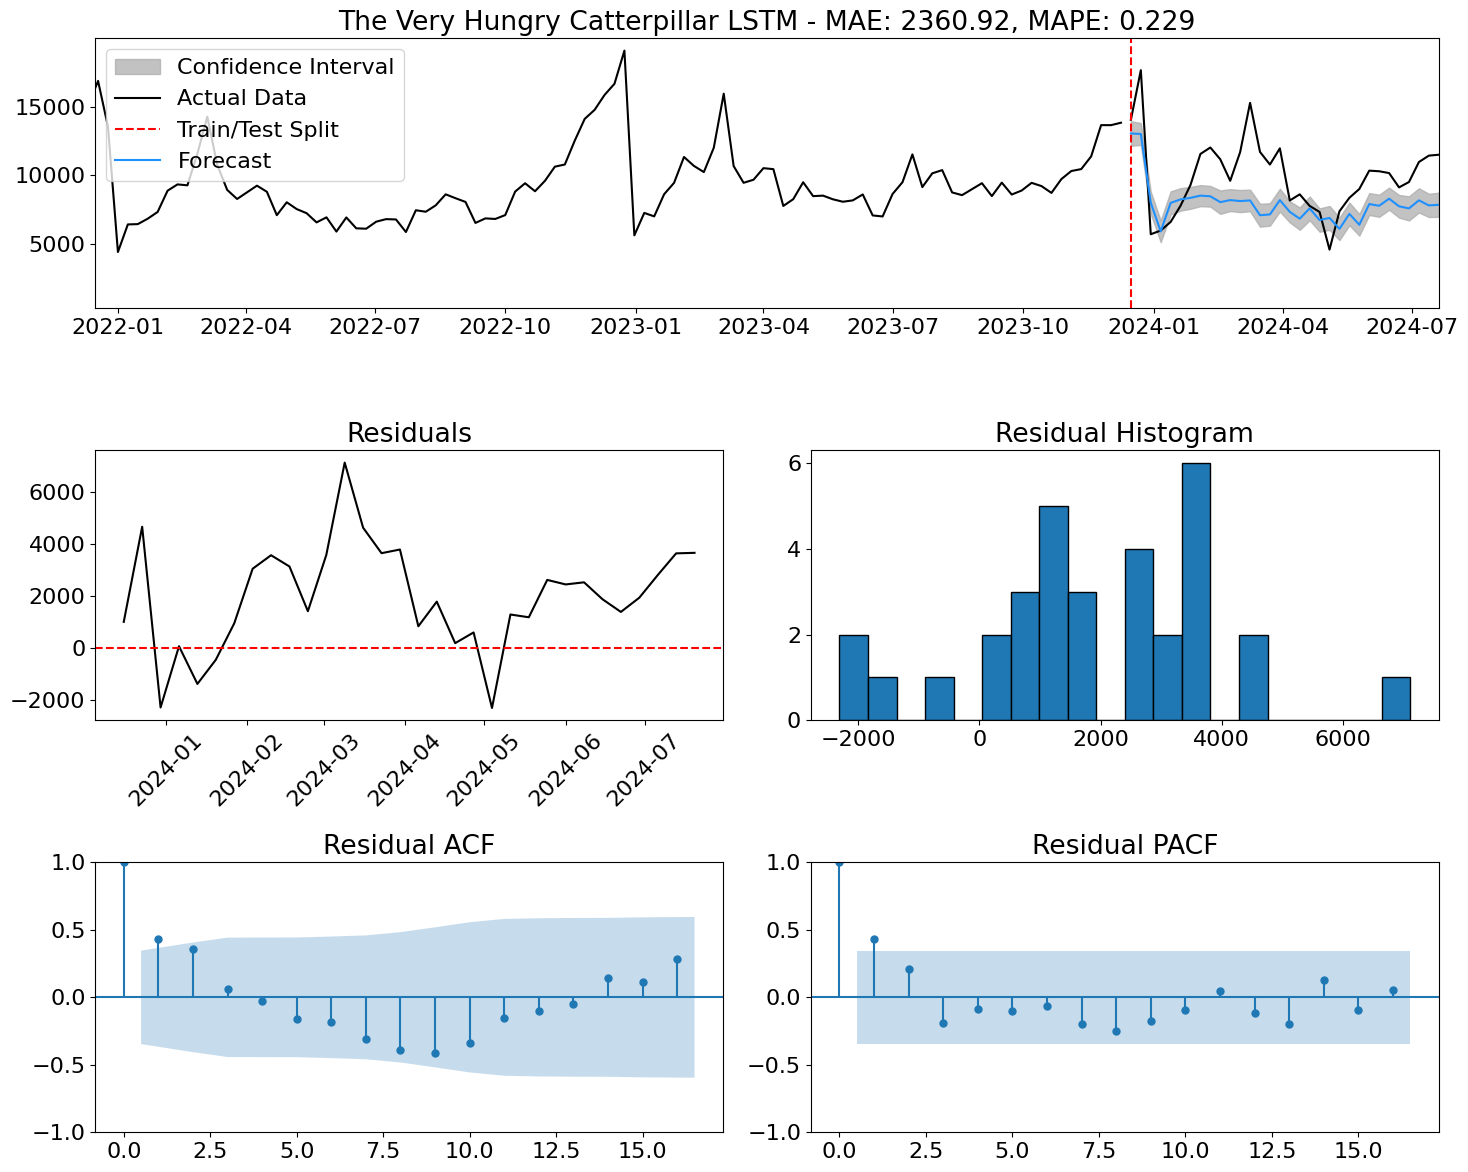

(2360.9158972167966, 0.22933397400131184)

In [ ]:
plot_prediction_master(lstm_hc_data_train, lstm_hc_data_test, lstm_hc_pred, "The Very Hungry Catterpillar", "LSTM", lstm_hc_conf)

The LSTM model performs similarly to the untuned XGBoost model for The Very Hungry Caterpillar in terms of MAE and MAPE, but visually the fit does look better.

### Alchemist

In [ ]:
lstm_model_alch, lstm_model_epoch_alch, lstm_alch_X_train_scaled, lstm_alch_y_train_scaled, lstm_alch_data_train, lstm_alch_train_scaled, lstm_alch_scaler, lstm_alch_data_test = run_hyperparameter_tuning(alchemist_imputed, lookback, forecast)

32


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_alch_pred, lstm_alch_conf = run_best_model(lstm_model_alch, lstm_model_epoch_alch, lstm_alch_X_train_scaled, lstm_alch_y_train_scaled, lstm_alch_train_scaled, lstm_alch_scaler, lstm_alch_data_test, lookback)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 52, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 52, 112)        │        79,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       123,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 671,138 (2.56 MB)

 Trainable params: 223,712 (873.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 447,426 (1.71 MB)

None



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


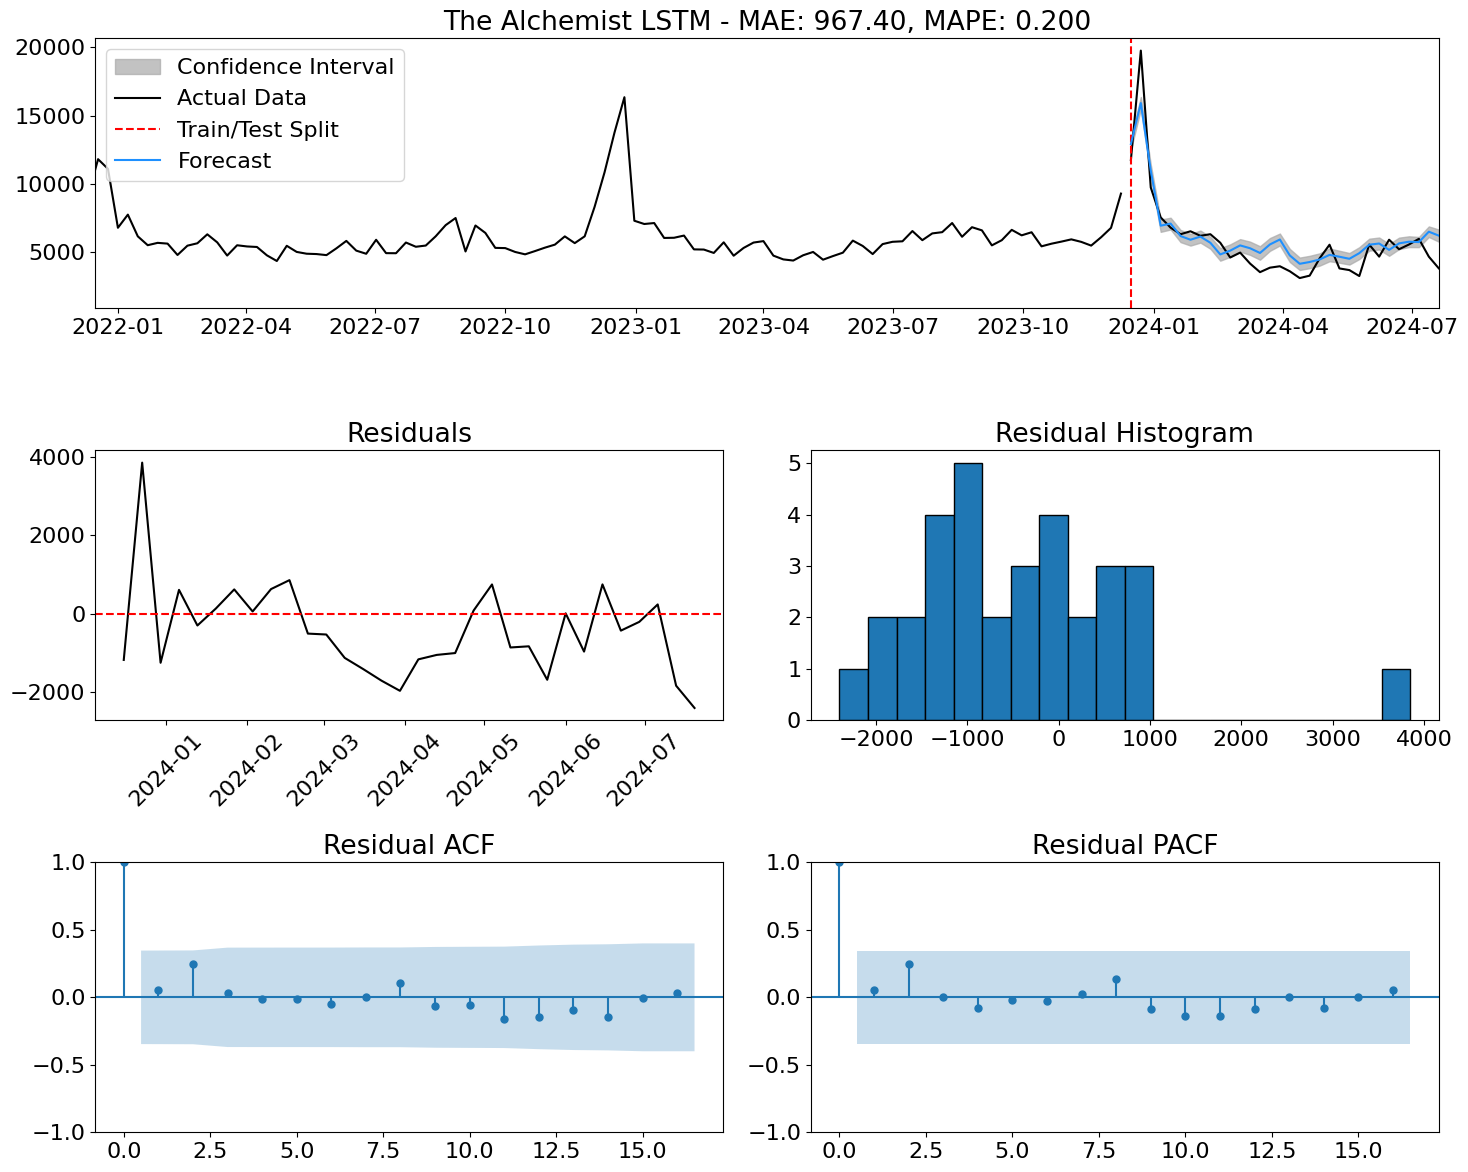

(967.4036041259781, 0.19990476343090052)

In [ ]:
plot_prediction_master(lstm_alch_data_train, lstm_alch_data_test, lstm_alch_pred, "The Alchemist", "LSTM", lstm_alch_conf)

The LSTM model visually gave a good fit, but it was not able to capture the height of the seasonal peak which degraded its scores. Residuals are mostly nicely centred around the mean, bar the first few due to the seasonal spike it couldn't replicate. ACF/PACF plots look promising too.

#Hybrid Architecture Models

## Sequential SARIMA-LSTM

In [ ]:
hungry_caterpillar_arima_residuals = pd.Series(hungry_caterpillar_arima_model.resid(), index=hungry_caterpillar_train_32.index) #generates residuals for training data ONLY
dummy_test_residuals_hc = pd.Series(0, index=hungry_caterpillar_test_32.index) #dummy data of 32 zeros
padded_hungry_caterpillar_arima_residuals = pd.concat([hungry_caterpillar_arima_residuals, dummy_test_residuals_hc])


alchemist_arima_residuals = pd.Series(alchemist_arima_model.resid(), index=alchemist_train_32.index) #generates residuals for training data ONLY
dummy_test_residuals_alch = pd.Series(0, index=alchemist_test_32.index) #dummy data of 32 zeros
padded_alchemist_arima_residuals = pd.concat([alchemist_arima_residuals, dummy_test_residuals_alch])

display(hungry_caterpillar_arima_residuals)
print(f"This is a:\n{type(hungry_caterpillar_arima_residuals)}\n\nwith length: {len(hungry_caterpillar_arima_residuals)} weeks")

,0
End Date,
2012-01-07,1932.178276
2012-01-14,950.555636
2012-01-21,1136.197211
2012-01-28,1309.689474
2012-02-04,2793.292023
...,...
2023-11-11,-597.316803
2023-11-18,-873.264758
2023-11-25,375.632428


This is a:
<class 'pandas.core.series.Series'>

with length: 623 weeks


### Hungry Caterpillar

In [ ]:
seq_lstm_model_hc, seq_lstm_model_epoch_hc, seq_lstm_hc_X_train_scaled, seq_lstm_hc_y_train_scaled, seq_lstm_hc_data_train, seq_lstm_hc_train_scaled, seq_lstm_hc_scaler, seq_lstm_hc_data_test = run_hyperparameter_tuning(padded_hungry_caterpillar_arima_residuals, lookback, forecast)

32


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
seq_lstm_hc_pred, seq_lstm_hc_conf = run_best_model(seq_lstm_model_hc, seq_lstm_model_epoch_hc, seq_lstm_hc_X_train_scaled, seq_lstm_hc_y_train_scaled, seq_lstm_hc_train_scaled, seq_lstm_hc_scaler, seq_lstm_hc_data_test, lookback)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 52, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 52, 96)         │        49,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 16)             │         7,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,994 (722.64 KB)

 Trainable params: 61,664 (240.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 123,330 (481.76 KB)

None



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
seq_lstm_hc_pred += hc_arima_pred #from before

seq_lstm_hc_conf['lower'] += hc_arima_pred.values
seq_lstm_hc_conf['upper'] += hc_arima_pred.values

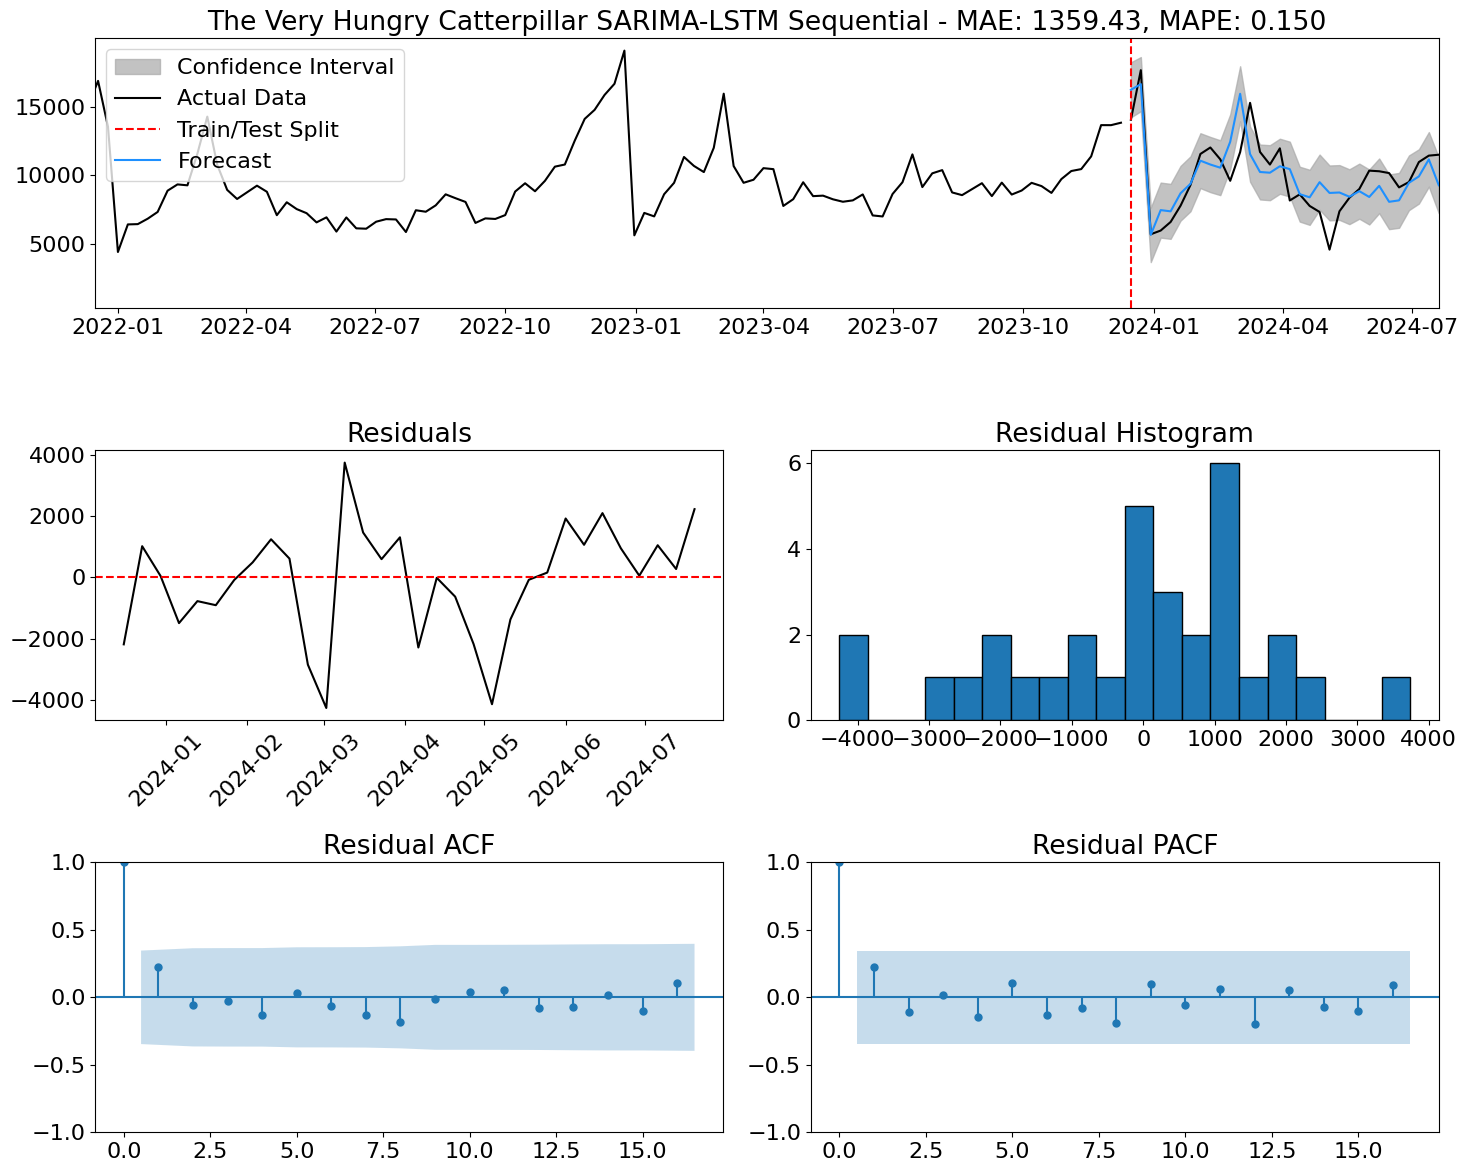

(1359.4258903640575, 0.14980291028370415)

In [ ]:
plot_prediction_master(hungry_caterpillar_train_32, hungry_caterpillar_test_32, seq_lstm_hc_pred, "The Very Hungry Catterpillar", "SARIMA-LSTM Sequential", seq_lstm_hc_conf)

Using a sequential approach, where the LSTM learns the ARIMA residuals gave a good fit, although not as good as ARIMA predictions alone. It was able to capture the height of the seasonal spike, but this is likely due to ARMIA's power. Adding the LSTM model to the ARMIA residuals does not add to model performance.

### Alchemist

In [ ]:
seq_lstm_model_alch, seq_lstm_model_epoch_alch, seq_lstm_alch_X_train_scaled, seq_lstm_alch_y_train_scaled, seq_lstm_alch_data_train, seq_lstm_alch_train_scaled, seq_lstm_alch_scaler, seq_lstm_alch_data_test = run_hyperparameter_tuning(padded_alchemist_arima_residuals, lookback, forecast)

32


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
seq_lstm_alch_pred, seq_lstm_alch_conf = run_best_model(seq_lstm_model_alch, seq_lstm_model_epoch_alch, seq_lstm_alch_X_train_scaled, seq_lstm_alch_y_train_scaled, seq_lstm_alch_train_scaled, seq_lstm_alch_scaler, seq_lstm_alch_data_test, lookback)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 52, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 52, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,618 (1.33 MB)

 Trainable params: 115,872 (452.62 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 231,746 (905.26 KB)

None



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
seq_lstm_alch_pred += alch_arima_pred #from before

seq_lstm_alch_conf['lower'] += alch_arima_pred.values
seq_lstm_alch_conf['upper'] += alch_arima_pred.values

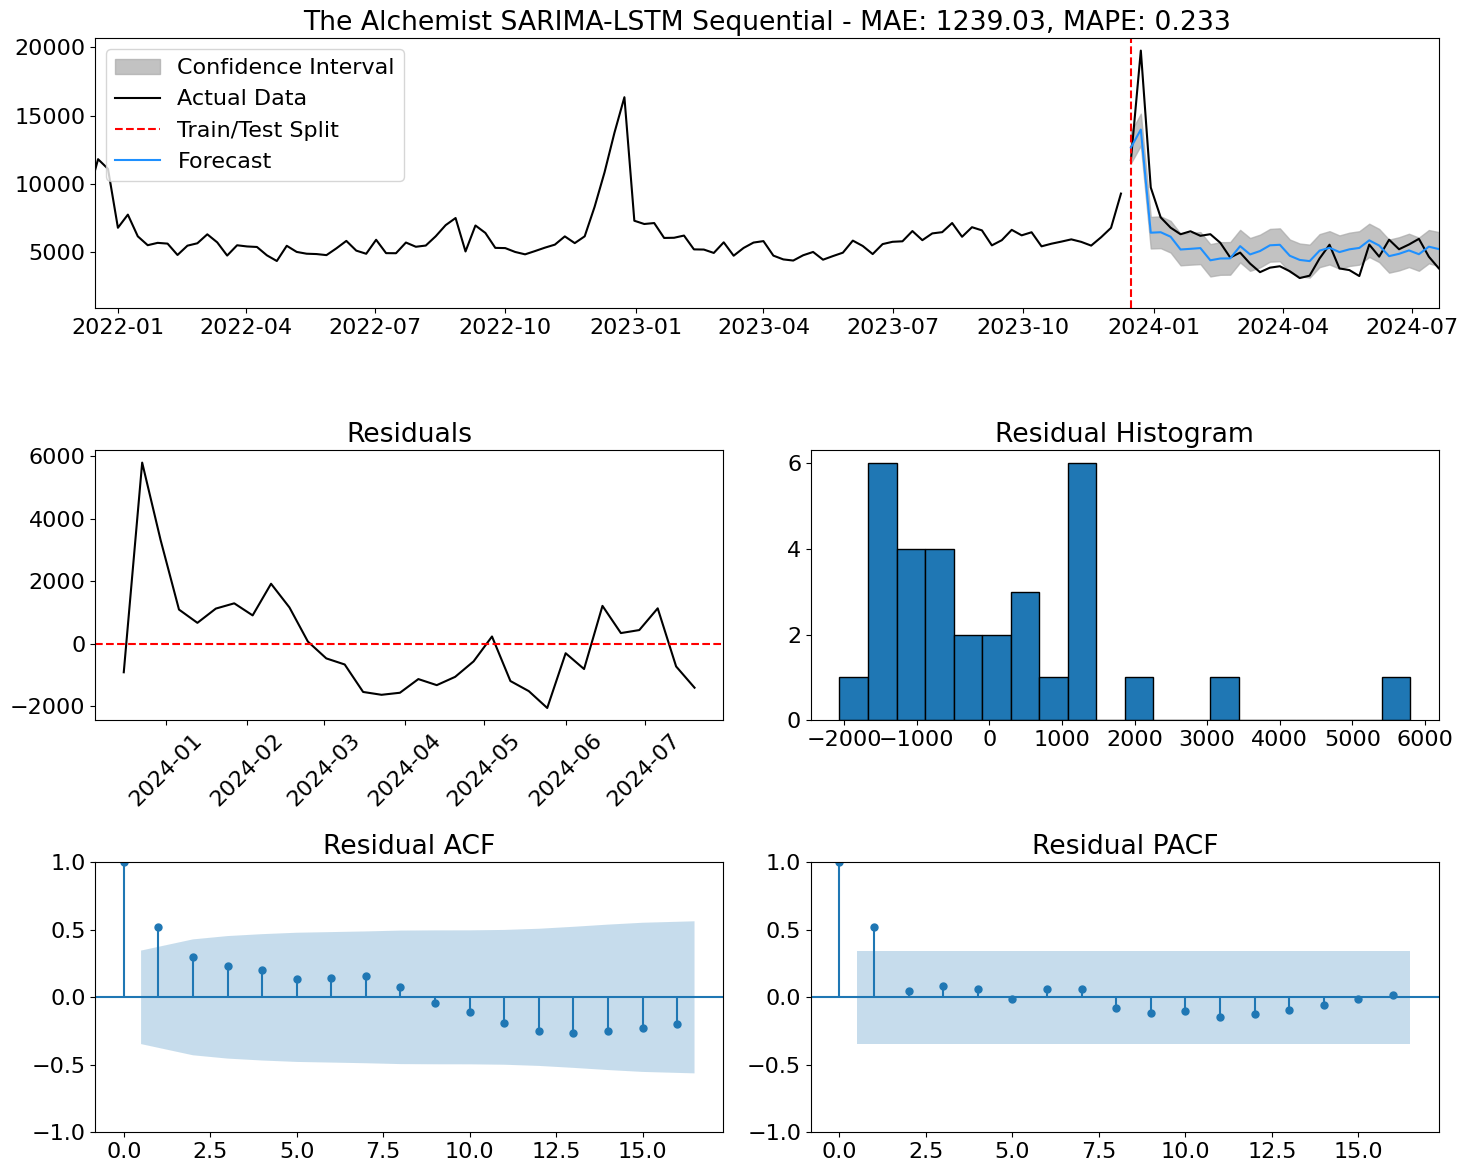

(1239.0289575931822, 0.23316159805719391)

In [ ]:
plot_prediction_master(alchemist_train_32, alchemist_test_32, seq_lstm_alch_pred, "The Alchemist", "SARIMA-LSTM Sequential", seq_lstm_alch_conf)

Whilst this provides a good model, similarly to before, the hybrid architecture of the LSTM-SARMIA model did not improve performance over ARMIA alone.

## Parallel SARAMIA-LSTM

In [ ]:
def find_optimal_weighting(arima_pred, lstm_pred, test_data):
  best_sarima_weight = 0
  best_mae = float('inf')

  # Loop through weights from 0.00 to 1.00
  for x in np.linspace(0, 1, 101):
    # w is the SARIMA weight, (1-w) is the LSTM weight
    combined_pred = (x * arima_pred) + ((1 - x) * lstm_pred)

    # Calculate error against the actual test data
    current_mae = mean_absolute_error(test_data, combined_pred)

    # Update if this weight combination yielded a lower error
    if current_mae < best_mae:
        best_mae = current_mae
        best_sarima_weight = x

  best_lstm_weight = 1 - best_sarima_weight

  print(f"Optimal SARIMA weight: {best_sarima_weight:.2f}")
  print(f"Optimal LSTM weight: {best_lstm_weight:.2f}")
  print(f"Lowest achievable MAE: {best_mae:.2f}")

  return best_sarima_weight, best_lstm_weight

In [ ]:
def get_parallel_pred(best_arima_weight, arima_pred, arima_conf, best_lstm_weight, lstm_pred, lstm_conf, test_data):

  parallel_pred = (best_arima_weight * arima_pred) + (best_lstm_weight * lstm_pred)

  parallel_conf_int = pd.DataFrame({
    'lower': (best_arima_weight * arima_conf['lower']) + (best_lstm_weight * lstm_conf['lower']),
    'upper': (best_arima_weight * arima_conf['upper']) + (best_lstm_weight * lstm_conf['upper'])}, index=test_data.index)

  return parallel_pred, parallel_conf_int

In [ ]:
hc_arima_conf_int = pd.DataFrame(
    hc_arima_conf_int,
    columns=['lower', 'upper'],
    index=hungry_caterpillar_test_32.index)

alch_arima_conf_int = pd.DataFrame(
    alch_arima_conf_int,
    columns=['lower', 'upper'],
    index=alchemist_test_32.index)

### Hungry Caterpillar

In [ ]:
best_hc_sarima_weight, best_hc_lstm_weight = find_optimal_weighting(hc_arima_pred, lstm_hc_pred, hungry_caterpillar_test_32)

Optimal SARIMA weight: 0.84
Optimal LSTM weight: 0.16
Lowest achievable MAE: 1453.72


In [ ]:
hc_parallel_pred, hc_parallel_conf = get_parallel_pred(best_hc_sarima_weight, hc_arima_pred, hc_arima_conf_int, best_hc_lstm_weight, lstm_hc_pred, lstm_hc_conf, hungry_caterpillar_test_32)

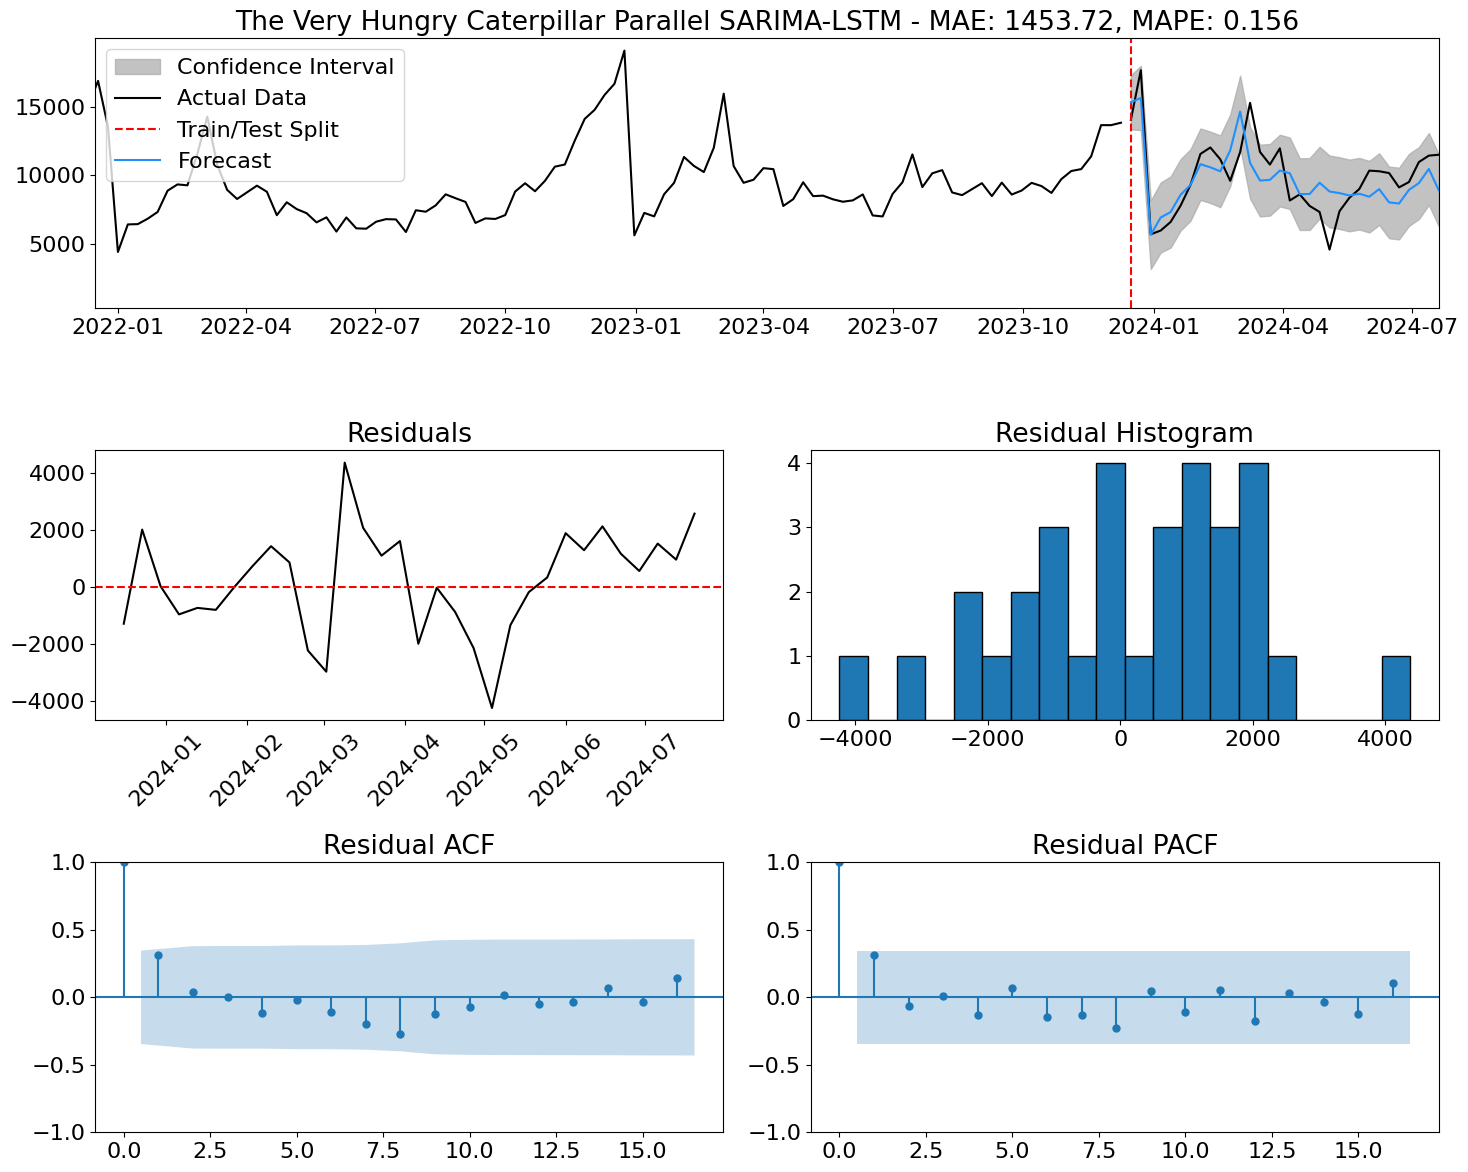

(1453.7210335690406, 0.15627344140003896)

In [ ]:
plot_prediction_master(hungry_caterpillar_train_32, hungry_caterpillar_test_32, hc_parallel_pred, "The Very Hungry Caterpillar", "Parallel SARIMA-LSTM", hc_parallel_conf)

This parallel combination method gave a very good fit, tied with the best seen previously. This is not a coincidence, since the optimal split was found to be 100% contribution from the prior best model, ARMIA, so the predictions and associated scores are identical.

NOTE: Non-deterministic nature means every time this notebook runs, a different weighting is found. E.g. it is no longer 100% SARMIA here.

### Alchemist

In [ ]:
best_alch_sarima_weight, best_alch_lstm_weight = find_optimal_weighting(alch_arima_pred, lstm_alch_pred, alchemist_test_32)

Optimal SARIMA weight: 0.29
Optimal LSTM weight: 0.71
Lowest achievable MAE: 913.75


In [ ]:
alch_parallel_pred, alch_parallel_conf = get_parallel_pred(best_alch_sarima_weight, alch_arima_pred, alch_arima_conf_int, best_alch_lstm_weight, lstm_alch_pred, lstm_alch_conf, hungry_caterpillar_test_32)

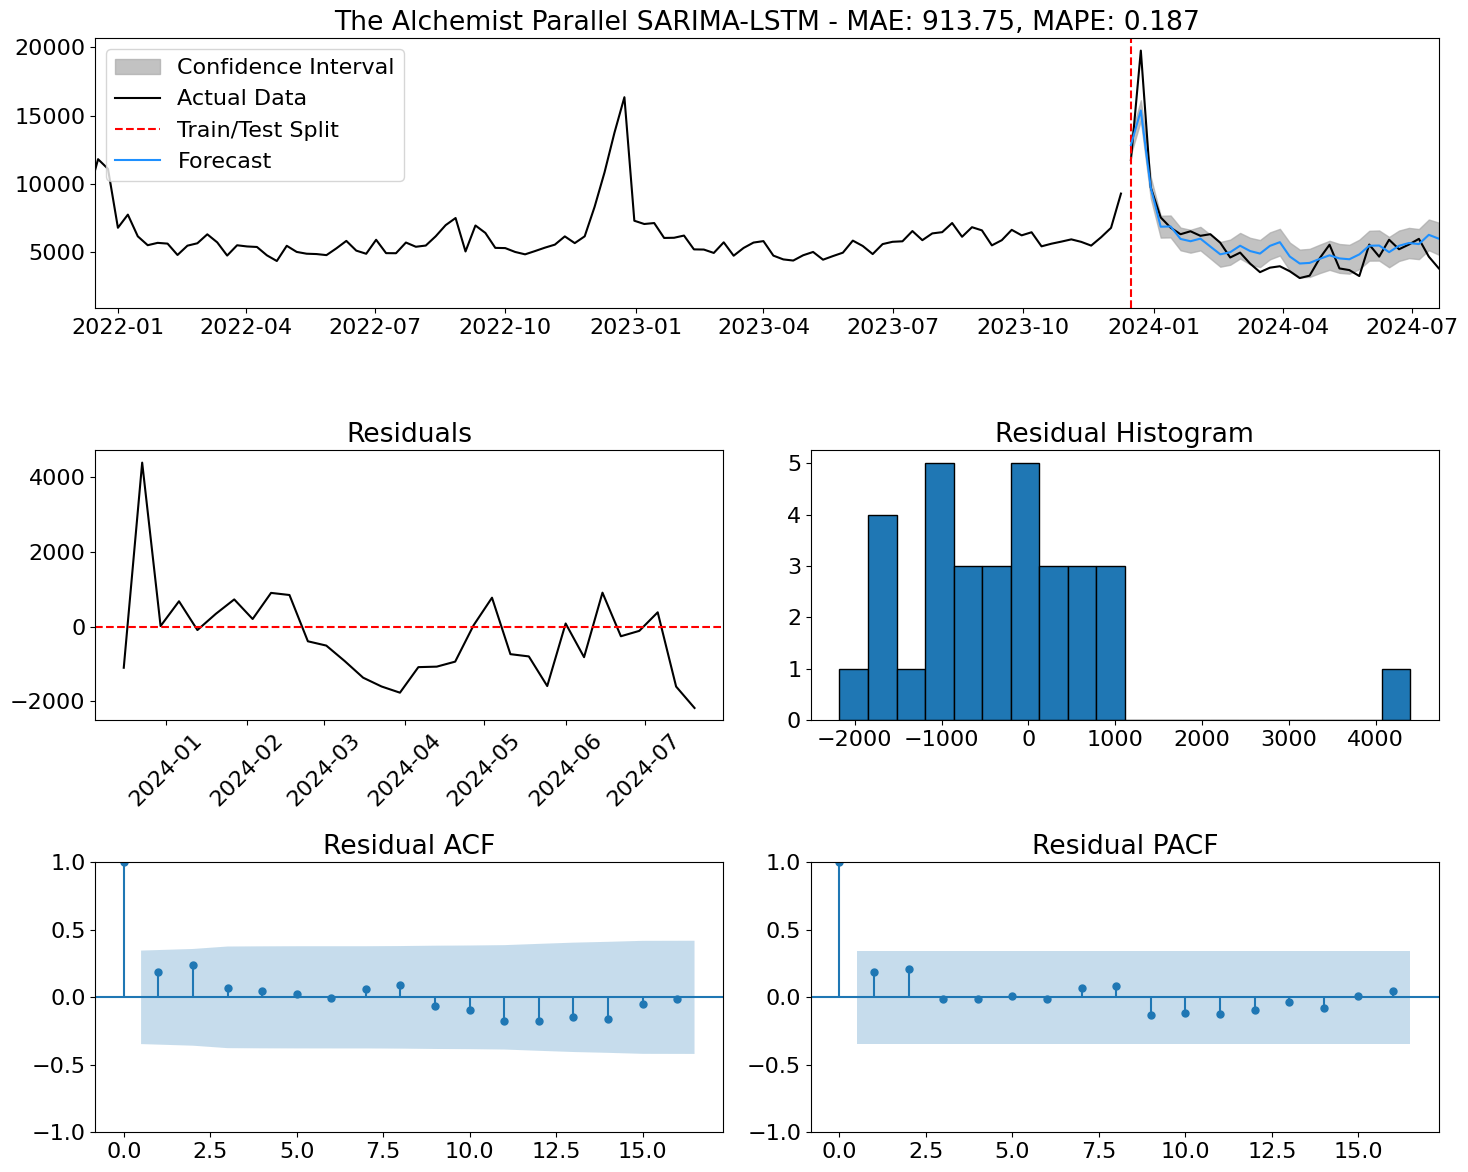

(913.7483563123353, 0.18695915629772267)

In [ ]:
plot_prediction_master(alchemist_train_32, alchemist_test_32, alch_parallel_pred, "The Alchemist", "Parallel SARIMA-LSTM", alch_parallel_conf)

Pairing the parallel approach to The Hungry Caterpillar does not improve the MAPE much, but there is a notable shift in the MAE. This is likely because the models are making errors at different points in the prediction so they can compensate for each other.

A slight preference is given to the ARMIA model here, but not as great as seen for The Very Hungry Caterpillar.

# Monthly Resample

Weekly samples provide good insight into the variations of book sales with a high enough resolution to discern peaks and their associated bandwidths.

For completeness, a comparison can be done to a lower sampling frequency, i.e. monthly. It is expected that model performance will be worse since signals will be too spread out to make accurate predictions.

To do this, the same data as before can be resampled to a monthly index, and the prior pipelines can be used with appropriate adjustment to parameters due to the changed seasonality with respect to the sampling frequency of the data.

In [ ]:
hungry_caterpillar_monthly = hungry_caterpillar_imputed.resample('M').sum()
alchemist_monthly = alchemist_imputed.resample('M').sum()

/tmp/ipykernel_3806/2160605690.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hungry_caterpillar_monthly = hungry_caterpillar_imputed.resample('M').sum()
/tmp/ipykernel_3806/2160605690.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  alchemist_monthly = alchemist_imputed.resample('M').sum()


## XGBoost

In [ ]:
param_grid = {"forecast__window_length": [1, 3, 6, 12, 24]} #setting new parameter grid for monthly sampling in sensible intervals

### Hungry Caterpillar

In [ ]:
xgb_hc_mon_train, xgb_hc_mon_test, xgb_hc_mon_pred, xgb_hc_mon_forecast_int = xgboost_predictor(hungry_caterpillar_monthly, 8, param_grid, "box_cox", 12)

8
8
8
Best parameters: {'forecast__window_length': 1}


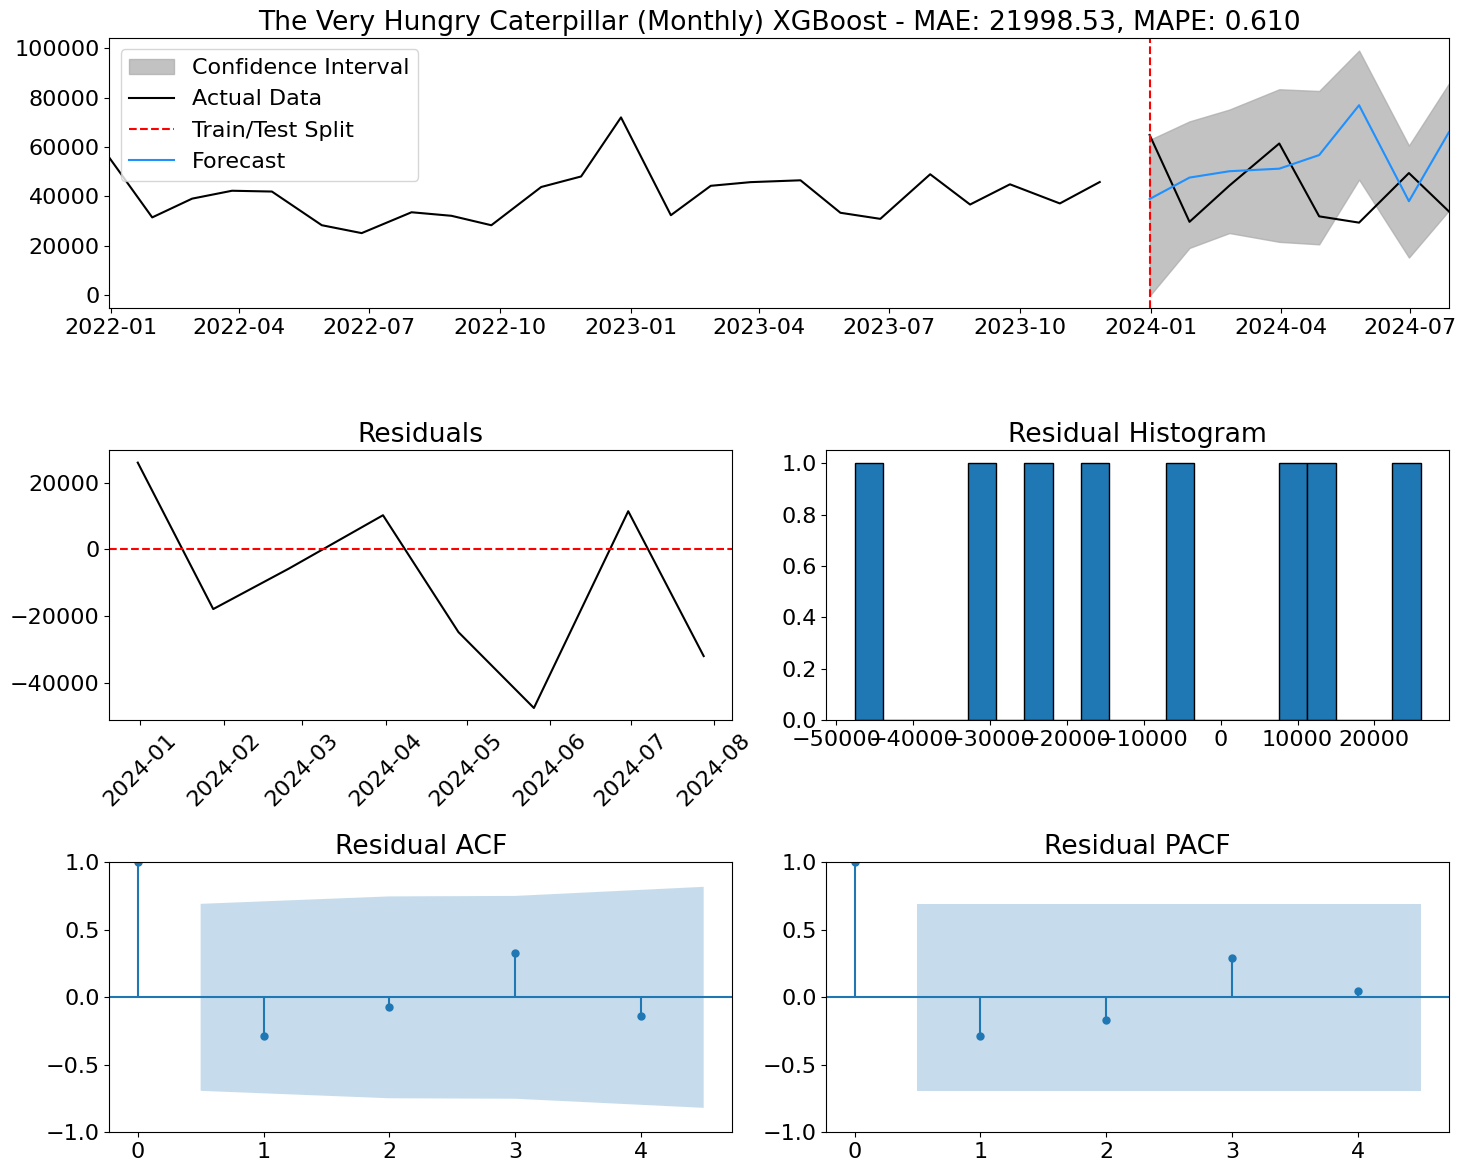

(21998.53005945011, 0.6101860516961357)

In [ ]:
plot_prediction_master(xgb_hc_mon_train, xgb_hc_mon_test, xgb_hc_mon_pred, "The Very Hungry Caterpillar (Monthly)", "XGBoost", xgb_hc_mon_forecast_int)

The performance is bad when monthly sampling. Visually, the prediction does not follow the actual data well and residuals are not well behaved so information is left available that higher sampling frequencies can capture better.

### Alchemist

In [ ]:
xgb_alch_mon_train, xgb_alch_mon_test, xgb_alch_mon_pred, xgb_alch_mon_forecast_int = xgboost_predictor(alchemist_monthly, 8, param_grid, "log", 12)

8
8
8
Best parameters: {'forecast__window_length': 1}


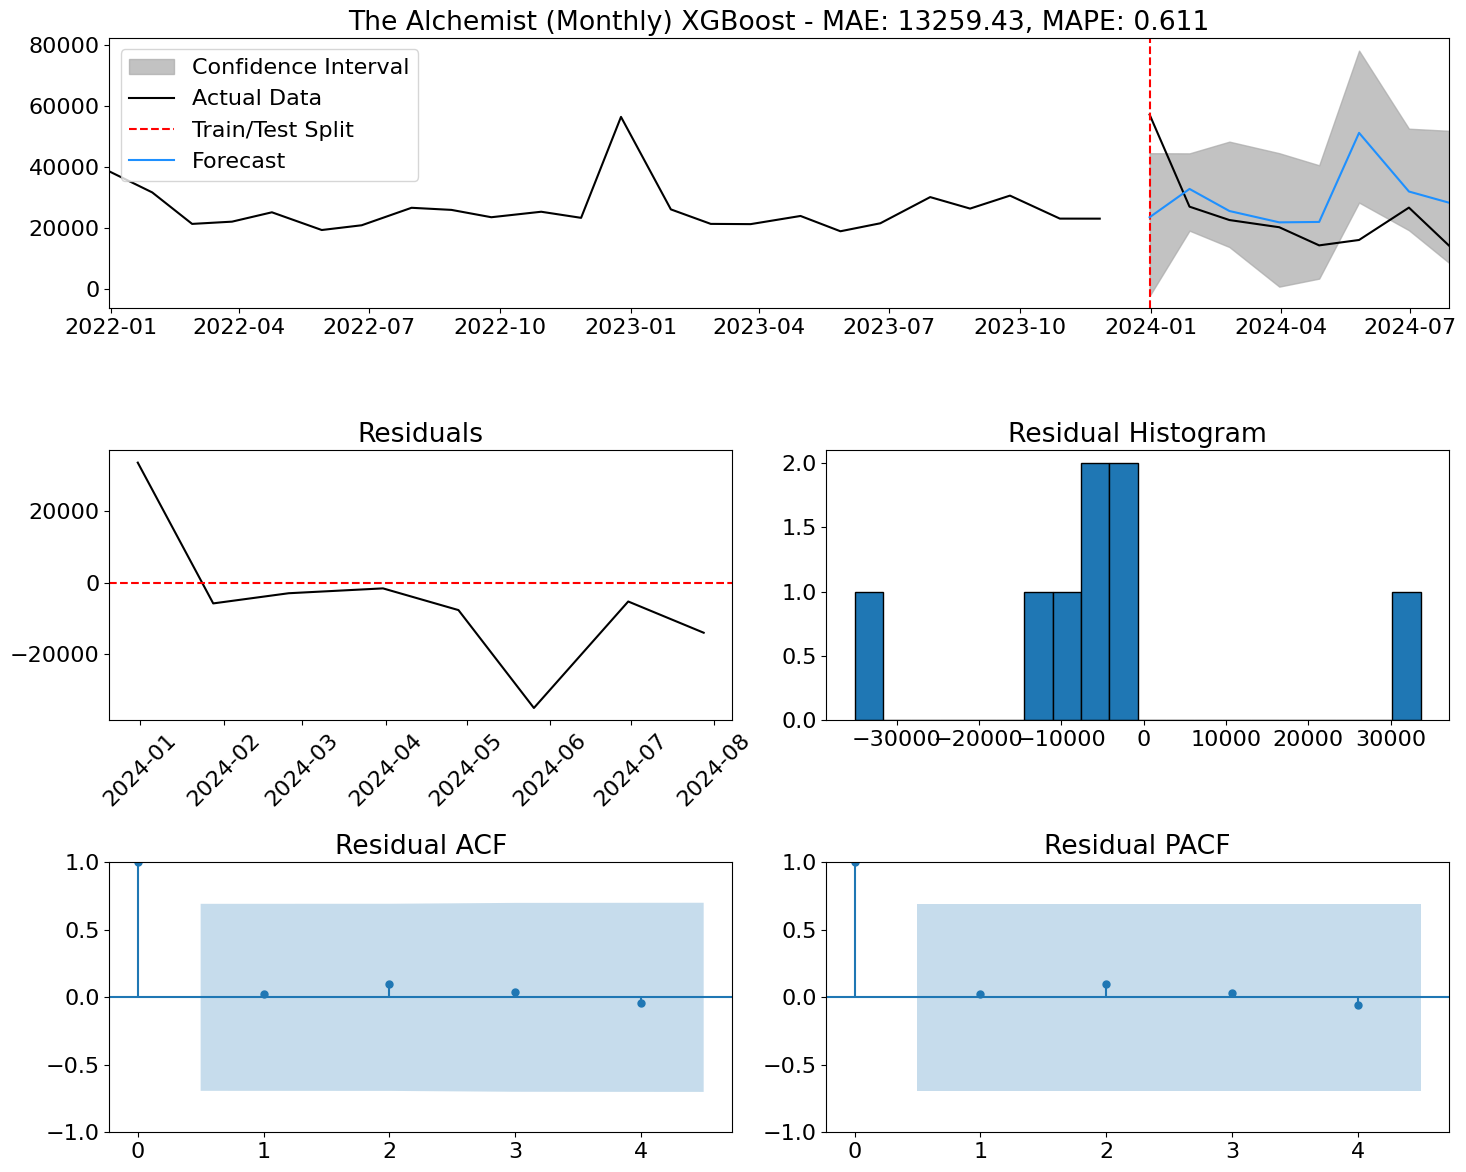

(13259.431985838466, 0.6113088258701833)

In [ ]:
plot_prediction_master(xgb_alch_mon_train, xgb_alch_mon_test, xgb_alch_mon_pred, "The Alchemist (Monthly)", "XGBoost", xgb_alch_mon_forecast_int)

Similarly to before, performance is poor and this is not an appropriate sampling frequency.

## Auto-ARIMA

### Hungry Caterpillar

In [ ]:
hungry_caterpillar_train_8, hungry_caterpillar_test_8 = split_train_test_data(hungry_caterpillar_monthly, 8)

8


In [ ]:
hc_mon_arima_model = run_auto_arima(hungry_caterpillar_train_8, 12)

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : BIC=2694.748, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : BIC=2683.880, Time=0.40 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : BIC=2679.422, Time=0.27 sec
 ARIMA(0,0,0)(0,1,0)[12]             : BIC=2705.151, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : BIC=2692.947, Time=0.05 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : BIC=2679.903, Time=0.91 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : BIC=2686.012, Time=0.43 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : BIC=2673.259, Time=0.50 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : BIC=2679.207, Time=0.52 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : BIC=2684.664, Time=0.24 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : BIC=2677.064, Time=0.31 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : BIC=2676.110, Time=0.34 sec
 ARIMA(0,0,0)(0,1,1)[12]             : BIC=2705.686, Time=0.07 sec

Best model:  ARIMA(0,0,0)(0,1,1)[12] intercept
Total fit time: 4.123 seconds
Done!


In [ ]:
hc_mon_arima_pred, hc_mon_arima_conf_int = best_arima_pred(hc_mon_arima_model, hungry_caterpillar_test_8)

                                 SARIMAX Results                                  
Dep. Variable:                          y   No. Observations:                  143
Model:             SARIMAX(0, 1, [1], 12)   Log Likelihood               -1329.317
Date:                    Mon, 24 Aug 2026   AIC                           2664.634
Time:                            07:46:10   BIC                           2673.259
Sample:                        01-31-2012   HQIC                          2668.139
                             - 11-30-2023                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2928.2810    303.677      9.643      0.000    2333.086    3523.476
ma.S.L12      -0.4814      0.076     -6.312      0.000      -0.631      -0.332
sigma2      3.945e+0

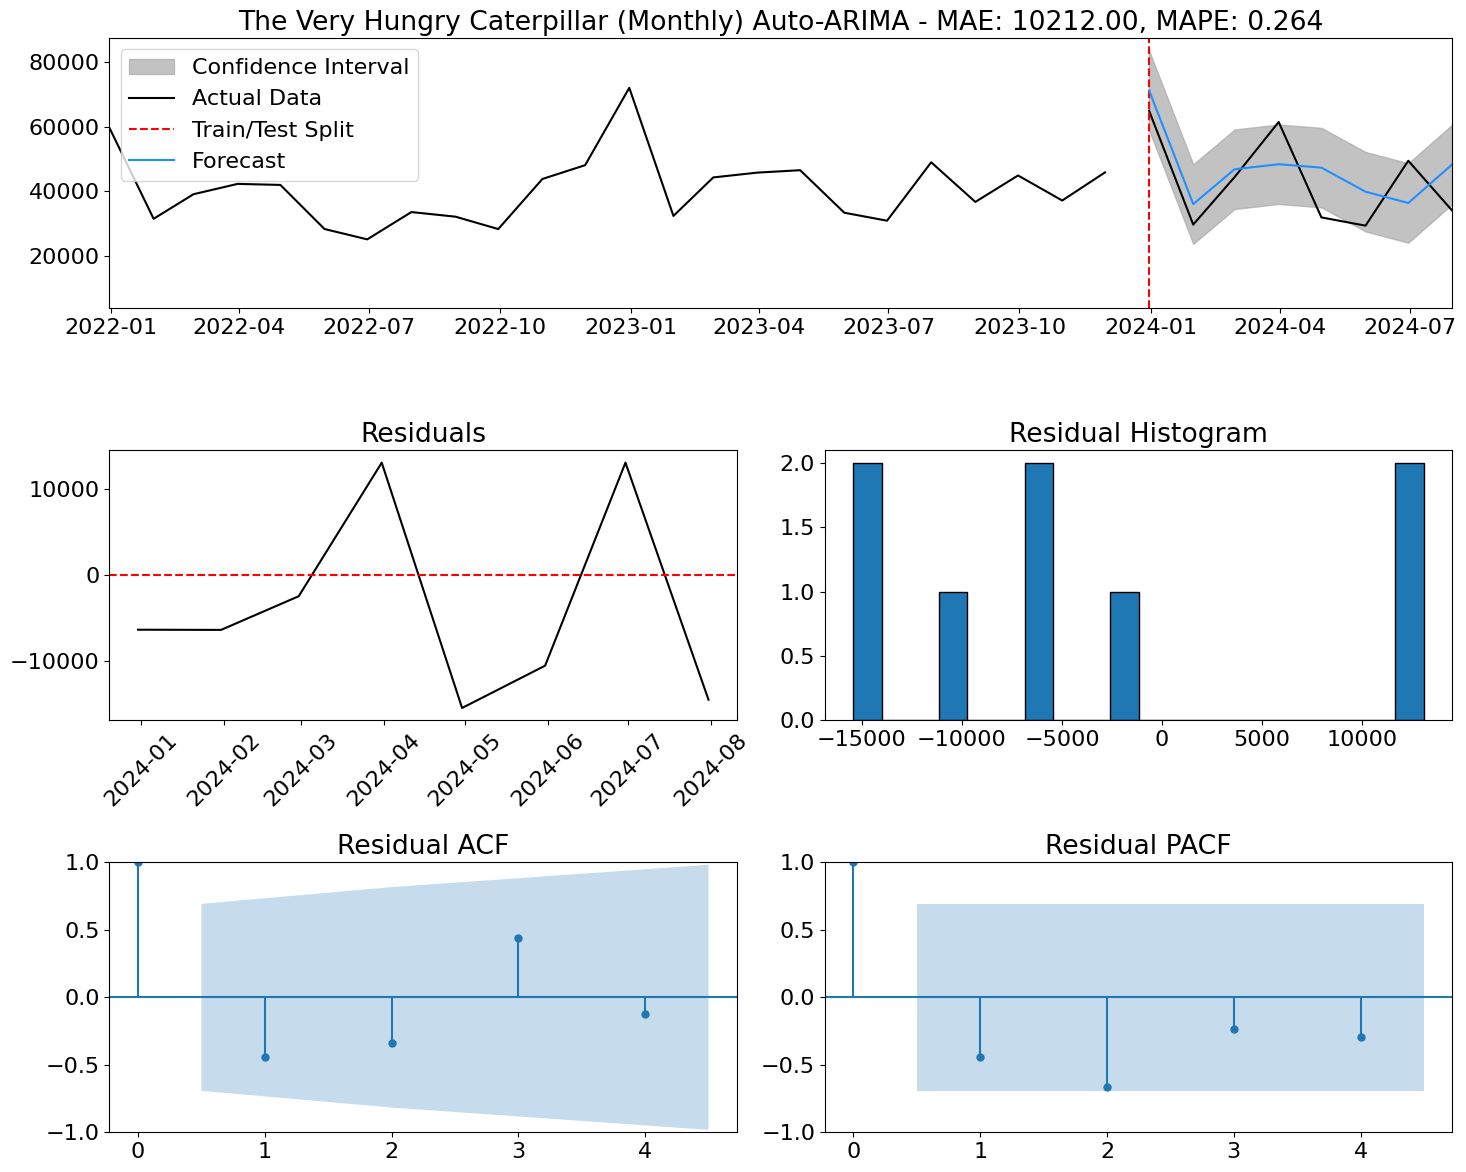

(10211.998322079313, 0.26400301036847357)

In [ ]:
plot_prediction_master(hungry_caterpillar_train_8, hungry_caterpillar_test_8, hc_mon_arima_pred, "The Very Hungry Caterpillar (Monthly)", "Auto-ARIMA", hc_mon_arima_conf_int)

This gave a better prediction than expected. Whilst it doesn't compete with the weekly sampling frequency models, it captures the seasonal spike and the plateau afterwards.

### Alchemist

In [ ]:
alchemist_train_8, alchemist_test_8 = split_train_test_data(alchemist_monthly, 8)

8


In [ ]:
alch_mon_arima_model = run_auto_arima(alchemist_train_8, 12)

Performing stepwise search to minimize bic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : BIC=2588.906, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : BIC=2573.271, Time=0.14 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : BIC=2566.375, Time=0.15 sec
 ARIMA(0,0,0)(0,1,0)[12]             : BIC=2589.825, Time=0.03 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : BIC=2585.541, Time=0.06 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : BIC=2563.639, Time=0.24 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : BIC=2575.437, Time=0.11 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : BIC=2561.989, Time=0.55 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : BIC=2571.805, Time=0.11 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : BIC=2579.379, Time=0.10 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : BIC=2558.663, Time=0.57 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : BIC=2559.458, Time=0.41 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : BIC=2582.199, Time=0.05 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : BIC=2561.716, Time=0.26 sec
 ARIMA(1,0,1)(1,1,1

In [ ]:
alch_mon_arima_pred, alch_mon_arima_conf_int = best_arima_pred(alch_mon_arima_model, alchemist_test_8)

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  143
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 12)   Log Likelihood               -1266.894
Date:                            Mon, 24 Aug 2026   AIC                           2543.787
Time:                                    07:46:17   BIC                           2558.163
Sample:                                01-31-2012   HQIC                          2549.629
                                     - 11-30-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    452.8393    217.222      2.085      0.037      27.092     878.587
ar.L1          0.6778      0.151   

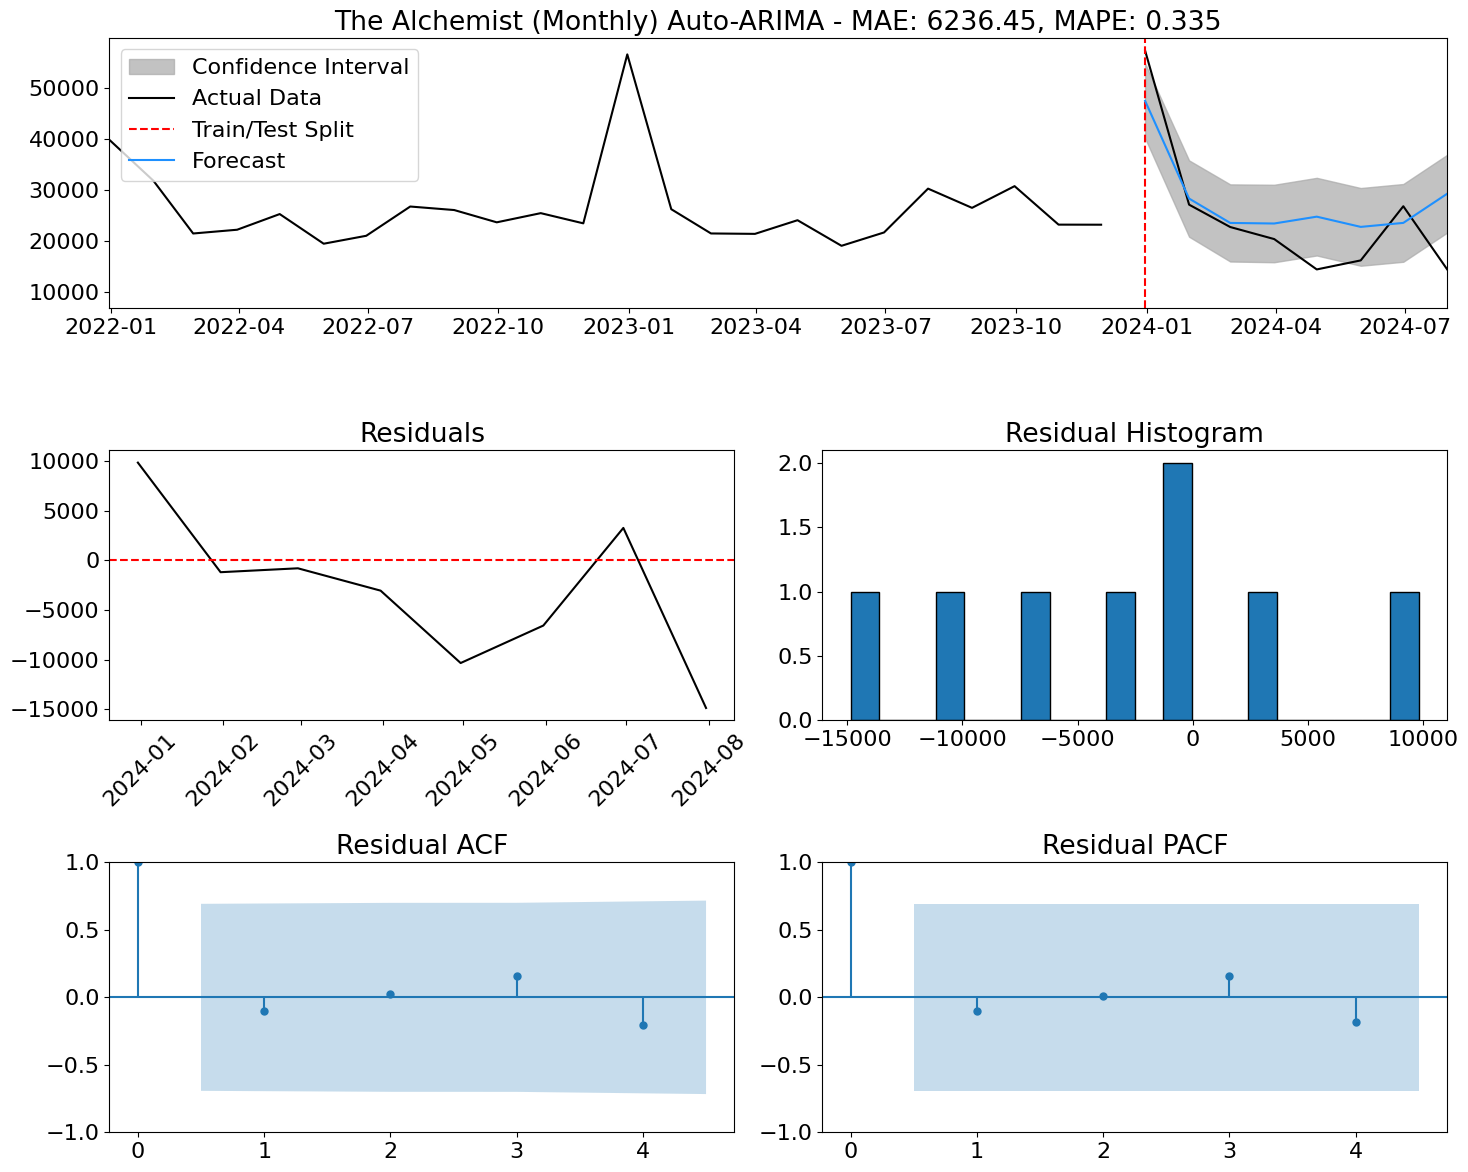

(6236.452458696949, 0.3351619347316235)

In [ ]:
plot_prediction_master(alchemist_train_8,alchemist_test_8, alch_mon_arima_pred, "The Alchemist (Monthly)", "Auto-ARIMA", alch_mon_arima_conf_int)

Similarly to The Very Hungry Caterpillar, this gave a better result than expected, yet still does not compete with weekly sampling frequency models.

# Conclusion

This project demonstrates the value of time series forecasting for proactive, data-driven procurement in the publishing sector. Applying STL imputation effectively resolved COVID-19 sales anomalies, ensuring the models captured true seasonal trends rather than historical outliers.

Among standalone models, Auto-ARIMA emerged as a robust, highly interpretable baseline, generally outperforming standard XGBoost and LSTM architectures. Hybrid models, particularly parallel SARIMA-LSTM frameworks, showed strong potential by dynamically weighting forecasts to offset individual model errors. However, the non-deterministic nature of deep learning requires training multiple iterations for reliable deployment. Furthermore, weekly data proved vastly superior to monthly sampling, which lost critical granular signals.

Ultimately, while no single architecture fits all books perfectly, implementing this multi-paradigm pipeline empowers publishers to confidently separate long-term trends from seasonal fluctuations. This enables optimal stock control to maximise revenue capture during seasonal peaks while avoiding the costs of inventory shortages and overstocking.